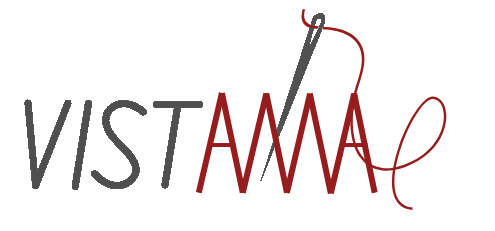

Cite as: Fung, Anthony A., Ashley H. Fung, Zhi Li, and Lingyan Shi. “Single-Frame Vignetting Correction for Post-Stitched-Tile Imaging Using VISTAmap.” Nanomaterials 15, no. 7 (January 2025): 563. https://doi.org/10.3390/nano15070563.

In [ ]:
# @title Install packages (restarts kernel)
import os
import sys
import subprocess

print("Python", sys.version.split()[0])

_cmd = [
    sys.executable, "-m", "pip", "install", "-q",
    "--only-binary=numpy,scikit-image",  # never try to compile these from source
    "numpy>=1.26",
    "rich>=12.4.4,<14",
    "bioio",
    "bioio-bioformats",
    "bioio-czi",
    "scikit-image>=0.24",
    "scikit-learn",
    "tifffile",
    "Pillow",
    "matplotlib",
]

_result = subprocess.run(_cmd, capture_output=True, text=True)
if _result.returncode != 0:
    print("Install failed:\n", _result.stderr[-3000:])
else:
    print("Packages installed. Restarting kernel to finalize versions...")
    os.kill(os.getpid(), 9)

Python 3.13.15


Python version: 3.13.15
GPU detected:
  GPU 0: NVIDIA A100-SXM4-80GB, 81920 MiB
Mounted at /content/drive
Output base name: VISTAmap_Copy of RBN-L_T4-5_CBP, GABA
Loading cached MIP array from: /content/drive/MyDrive/VISTAmap_Copy of RBN-L_T4-5_CBP, GABA_mips.npy
  Loaded shape: (4, 10188, 15256), dtype: uint8
  Skipped raw import (cache hit). Delete the .npy file to force re-import.
original_images shape: (4, 10188, 15256)
original_images dtype: uint8
Padding Y by 12 rows and X by 44 cols...
Final padded original_images shape: (4, 10200, 15300)


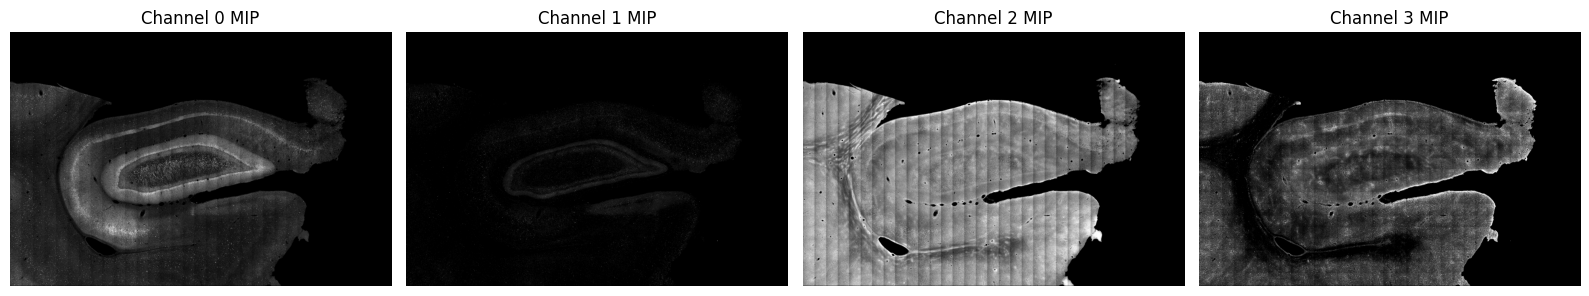

In [1]:
# @title Phase 1. Load Image (CZI/LIF/ND2 via Bio-Formats, TIFF via tifffile, PNG/JPEG via imread) and Build Per-Channel MIPs
# @markdown File-type agnostic loader. Routing by extension:
# @markdown   * **tifffile path**: .tif, .tiff, .ome.tif, .ome.tiff
# @markdown     (single-page 2D / multi-page Z-stack / RGB/RGBA / multi-channel
# @markdown     multi-z).  Avoids the Bio-Formats Java startup AND the
# @markdown     scikit-image 0.24 big-endian-uint16 -> uint8 bug.
# @markdown   * **Bio-Formats path**: .czi, .lif, .nd2, .lsm, .zvi, .svs,
# @markdown     .oib, .oif, .ims (multi-channel + multi-z; per-channel MIP).
# @markdown   * **skimage.io.imread path**: .png, .jpg, .jpeg, .bmp, .gif,
# @markdown     .webp (2D grayscale -> 1 channel; 3D RGB/RGBA -> 3
# @markdown     channels, alpha dropped). No z-stack handling here because
# @markdown     these formats don't carry one.
# @markdown
# @markdown The first successful load is cached as
# @markdown `VISTAmap_{base_name}_mips.npy` in `base_path`. Delete that
# @markdown file to force a re-import.

import os
import gc
import sys
import time
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from skimage import util, io as skio
import tifffile
from bioio import BioImage
import bioio_bioformats
try:
    # Native CZI reader (pylibCZIrw). Much faster than the Java Bio-Formats
    # reader for .czi files; used automatically for CZI below when present.
    import bioio_czi
    _HAVE_BIOIO_CZI = True
except Exception:
    _HAVE_BIOIO_CZI = False

os.environ.setdefault("BFF_JAVA_VERSION", "17")
os.environ.setdefault("BFF_JAVA_VENDOR", "temurin")


def check_gpu():
    print(f"Python version: {sys.version.split()[0]}")
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
            capture_output=True, text=True, check=True,
        )
        gpu_lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
        if gpu_lines:
            print("GPU detected:")
            for idx, line in enumerate(gpu_lines):
                print(f"  GPU {idx}: {line}")
            return True
    except Exception:
        pass
    print("No NVIDIA GPU detected. Image loading and MIP generation will run on CPU.")
    return False


has_gpu = check_gpu()
drive.mount("/content/drive", force_remount=True)


filename = "Copy of RBN-L_T4-5_CBP, GABA.czi"  # @param {type:"string"}
base_path = "/content/drive/MyDrive"  # @param {type:"string"}
full_path = os.path.join(base_path, filename)
if not os.path.exists(full_path):
    raise FileNotFoundError(f"File not found: {full_path}")
base_name = os.path.splitext(filename)[0]
# Handle .ome.tif/.ome.tiff where splitext only strips the inner .tif
if base_name.lower().endswith(".ome"):
    base_name = base_name[:-4]
print(f"Output base name: VISTAmap_{base_name}")


def _to_uint8_safe(arr):
    """Convert any numpy array to uint8, defensively normalising byte
    order first. scikit-image 0.24's ``util.img_as_ubyte`` calls
    ``np.floor_divide(..., dtype=arr.dtype, casting='unsafe')`` inside
    its ``_scale`` helper; with a non-native dtype (e.g. ``>u2`` from a
    big-endian uint16 TIFF read via Bio-Formats), newer numpy raises
    ``TypeError`` because byte-order-qualified dtype strings are not
    accepted in that argument. Casting to the native version of the
    same dtype first is a no-op on the bytes when ``arr`` is already
    native, and a single in-place byteswap+relabel otherwise. After
    that, ``util.img_as_ubyte`` is safe.
    """
    if arr.dtype == np.uint8:
        return arr
    if not arr.dtype.isnative:
        arr = arr.astype(arr.dtype.newbyteorder("="))
    return util.img_as_ubyte(arr)


def _available_ram_bytes():
    """Best-effort free-RAM estimate, used to choose a read strategy."""
    try:
        import psutil
        return int(psutil.virtual_memory().available)
    except Exception:
        pass
    try:
        return int(os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE"))
    except Exception:
        return 4 * 1024 ** 3


def _stage_locally(src_path, stage_dir="/content/vistamap_stage"):
    """Copy a file off the Google Drive FUSE mount onto local disk.

    Drive FUSE is very slow for the scattered random-access reads that
    CZI/ND2/LIF readers perform -- a mosaic CZI issues thousands of small
    subblock reads, each paying full network latency. One sequential bulk
    copy is dramatically faster than letting the reader do random I/O
    across the mount. Returns the local path on success, or the original
    path if staging is unnecessary, impossible, or not worthwhile.

    Note this only affects where Phase 1 *reads* from; ``full_path`` still
    refers to the original file for the later phases that log it.
    """
    try:
        if not src_path.startswith("/content/drive/"):
            return src_path                      # already on local disk
        size = os.path.getsize(src_path)
        if size < 256 * 1024 ** 2:               # small file: not worth it
            return src_path
        free = shutil.disk_usage("/content").free
        if free < size * 1.15 + 2 * 1024 ** 3:   # keep headroom
            print(f"  Local disk has {free / 1e9:.1f} GB free but the file is "
                  f"{size / 1e9:.1f} GB -- reading directly from Drive instead.")
            return src_path
        os.makedirs(stage_dir, exist_ok=True)
        dst_path = os.path.join(stage_dir, os.path.basename(src_path))
        if os.path.exists(dst_path) and os.path.getsize(dst_path) == size:
            print(f"  Reusing local copy from earlier run: {dst_path}")
            return dst_path
        print(f"  Staging {size / 1e9:.2f} GB off Google Drive to local disk "
              f"(one-off; makes the read far faster)...")
        t0 = time.time()
        chunk = 64 * 1024 * 1024
        done = 0
        next_report = 10.0
        with open(src_path, "rb", buffering=0) as fsrc, \
             open(dst_path, "wb", buffering=0) as fdst:
            while True:
                buf = fsrc.read(chunk)
                if not buf:
                    break
                fdst.write(buf)
                done += len(buf)
                pct = 100.0 * done / size if size else 100.0
                if pct >= next_report:
                    el = max(time.time() - t0, 1e-6)
                    print(f"    {pct:5.1f}%  ({done / 1e9:.2f}/{size / 1e9:.2f} GB, "
                          f"{done / 1e6 / el:.0f} MB/s)")
                    next_report += 10.0
        print(f"  Staged to {dst_path} in {time.time() - t0:.1f}s")
        return dst_path
    except Exception as exc:
        print(f"  Staging failed ({type(exc).__name__}: {exc}); "
              f"reading directly from the original path.")
        return src_path


# Cache check (works for any input format / loader)
mip_cache_path = os.path.join(base_path, f"VISTAmap_{base_name}_mips.npy")

if os.path.exists(mip_cache_path):
    print(f"Loading cached MIP array from: {mip_cache_path}")
    original_images = np.load(mip_cache_path)
    print(f"  Loaded shape: {original_images.shape}, dtype: {original_images.dtype}")
    print("  Skipped raw import (cache hit). Delete the .npy file to force re-import.")
else:
    print(f"No cache at {mip_cache_path} -- running raw import.")

    # ---- Decide which loader to use based on extension ----
    fname_lower = filename.lower()
    tiff_exts = (".tif", ".tiff")  # includes .ome.tif via endswith
    bioformats_only_exts = (".czi", ".lif", ".nd2", ".lsm", ".zvi",
                            ".svs", ".oib", ".oif", ".ims")
    imread_exts = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp")

    use_tifffile = fname_lower.endswith(tiff_exts)
    use_bioformats = fname_lower.endswith(bioformats_only_exts)
    use_imread = fname_lower.endswith(imread_exts)
    if not (use_tifffile or use_bioformats or use_imread):
        print(f"  Unknown extension '{os.path.splitext(filename)[1]}'. "
              f"Falling back to skimage.io.imread.")
        use_imread = True

    # ---- Stage the file off Google Drive if that will help ----
    # Only Phase 1's *read* uses `read_path`; `full_path` keeps pointing at
    # the original file, which later phases record and re-read.
    read_path = _stage_locally(full_path)

    if use_tifffile:
        # ===== tifffile path (TIFFs of all flavours) =====
        # Avoids the slow Bio-Formats Java startup AND the >u2 -> uint8
        # bug in skimage 0.24. tifffile handles multi-page Z-stacks
        # natively and returns native-byte-order arrays.
        print(f"Opening TIFF with tifffile: {read_path}")
        raw_img = tifffile.imread(read_path)
        print(f"  Loaded shape: {raw_img.shape}, dtype: {raw_img.dtype}")

        if raw_img.ndim == 2:
            # Single-plane, single-channel TIFF
            print("  2D image -> 1 channel")
            original_images = raw_img[np.newaxis, ...]
        elif raw_img.ndim == 3:
            # Either (Z, Y, X) z-stack, or (Y, X, C) RGB/RGBA
            if raw_img.shape[-1] in (3, 4):
                if raw_img.shape[-1] == 4:
                    print("  3D with RGBA last axis -> dropping alpha")
                    raw_img = raw_img[..., :3]
                print(f"  3D RGB last-axis-{raw_img.shape[-1]} -> {raw_img.shape[-1]} channels")
                original_images = np.moveaxis(raw_img, -1, 0)
            else:
                n_planes = raw_img.shape[0]
                print(f"  3D with {n_planes} planes (assumed Z-stack) -> MIP to 1 channel")
                original_images = np.max(raw_img, axis=0)[np.newaxis, ...]
        elif raw_img.ndim == 4:
            # Most likely (C, Z, Y, X) for OME-TIFF; MIP across Z per channel.
            n_ch, n_z = raw_img.shape[0], raw_img.shape[1]
            print(f"  4D shape {raw_img.shape} (assumed (C, Z, Y, X)) -> "
                  f"MIP across Z -> {n_ch} channels")
            original_images = np.max(raw_img, axis=1)
        else:
            raise ValueError(
                f"Unexpected TIFF dimensionality: {raw_img.ndim}D shape={raw_img.shape}"
            )

        if original_images.dtype != np.uint8:
            print(f"  Converting to uint8 (was {original_images.dtype})...")
            original_images = _to_uint8_safe(original_images)
        print(f"  Final shape: {original_images.shape}, dtype: {original_images.dtype}")
        del raw_img
        gc.collect()

    elif use_bioformats:
        # ===== Bio-Formats path (CZI, LIF, ND2, etc.) =====
        # CZI files load dramatically faster through the native bioio-czi
        # reader (no JVM startup, no per-plane Java overhead). Every other
        # bioformats-only format keeps the original Bio-Formats reader, so
        # their behaviour is unchanged. The rest of this branch is identical
        # regardless of reader, since both expose the same bioio API.
        if fname_lower.endswith(".czi") and _HAVE_BIOIO_CZI:
            print(f"Opening CZI with native bioio-czi reader: {read_path}")
            _bio_reader = bioio_czi.Reader
        else:
            print(f"Opening image with Bio-Formats: {read_path}")
            _bio_reader = bioio_bioformats.Reader
        bio_img = BioImage(read_path, reader=_bio_reader)
        print(f"Available scenes: {bio_img.scenes}")
        print(f"Current scene:    {bio_img.current_scene}")
        print(f"BioIO dims order: {bio_img.dims.order}")
        print(f"BioIO shape:      {bio_img.shape}")
        scene_index = 0
        bio_img.set_scene(scene_index)

        n_channels = int(getattr(bio_img.dims, "C", 1) or 1)
        n_z = int(getattr(bio_img.dims, "Z", 1) or 1)
        print(f"Detected channels: {n_channels}, z-slices: {n_z}")
        if n_channels == 1 and n_z == 1:
            print("  (single-channel, single-z -> treating as a 2D grayscale image)")

        # ---- Size test -> pick the fastest read strategy that fits in RAM ----
        # Fetching planes one at a time costs a reader round-trip per plane,
        # and for a mosaic CZI it re-composites the tile bounding box every
        # single time -- which is what made this cell hang. Reading a whole
        # channel (ZYX) or the whole stack (CZYX) in one call avoids that,
        # but needs the volume to fit in RAM, so measure before committing.
        _ny = int(getattr(bio_img.dims, "Y", 0) or 0)
        _nx = int(getattr(bio_img.dims, "X", 0) or 0)
        try:
            _itemsize = int(np.dtype(bio_img.dtype).itemsize)
        except Exception:
            _itemsize = 2
        _bytes_per_channel = _ny * _nx * n_z * _itemsize
        _bytes_all = _bytes_per_channel * n_channels
        _avail = _available_ram_bytes()
        # Budget conservatively: the reader needs working room on top of the
        # array it returns, and the MIPs still have to be built afterwards.
        # An OOM kills the Colab kernel outright, which is far worse than a
        # slower read, so the whole-stack path demands a lot of headroom.
        # Reading per-channel is nearly as fast anyway (a handful of reader
        # round-trips instead of one), so it is the preferred bulk path; the
        # big win over plane-by-plane is avoiding C*Z round-trips, not C.
        _budget_czyx = 0.20 * _avail
        _budget_zyx = 0.35 * _avail

        if _ny and _nx and _bytes_all <= _budget_czyx:
            _strategy = "czyx"
        elif _ny and _nx and _bytes_per_channel <= _budget_zyx:
            _strategy = "zyx"
        else:
            _strategy = "plane"

        _strategy_note = {
            "czyx": "whole stack in one read",
            "zyx": "one read per channel",
            "plane": "plane-by-plane (lowest memory)",
        }[_strategy]
        print(f"Read-size test: {_ny} x {_nx}, {_itemsize * 8}-bit -> "
              f"{_bytes_per_channel / 1e9:.2f} GB/channel, "
              f"{_bytes_all / 1e9:.2f} GB total; "
              f"{_avail / 1e9:.1f} GB RAM available.")
        print(f"  Strategy: {_strategy.upper()} ({_strategy_note})")

        def _mip_plane_by_plane(c):
            """Lowest-memory fallback: one reader call per z-plane."""
            mip = None
            for z in range(n_z):
                plane = bio_img.get_image_data("YX", T=0, C=c, Z=z)
                plane = np.asarray(plane).squeeze()
                if plane.ndim != 2:
                    raise ValueError(f"Expected 2D YX plane, got shape {plane.shape} for c={c}, z={z}.")
                if mip is None:
                    mip = plane.copy()
                else:
                    np.maximum(mip, plane, out=mip)
                del plane
            return mip

        _raw_mips = None

        if _strategy == "czyx":
            try:
                print(f"Reading full CZYX stack in one call "
                      f"({_bytes_all / 1e9:.2f} GB)...")
                _t0 = time.time()
                _stack = np.asarray(bio_img.get_image_data("CZYX", T=0))
                print(f"  Read {_stack.nbytes / 1e9:.2f} GB in "
                      f"{time.time() - _t0:.1f}s; projecting...")
                _raw_mips = [np.max(_stack[c], axis=0) for c in range(n_channels)]
                del _stack
                gc.collect()
                print(f"  All {n_channels} channel MIPs done in "
                      f"{time.time() - _t0:.1f}s")
            except Exception as exc:
                print(f"  CZYX read failed ({type(exc).__name__}: {exc}); "
                      f"falling back to per-channel reads.")
                _raw_mips = None
                _strategy = "zyx"
                gc.collect()

        if _raw_mips is None and _strategy == "zyx":
            _raw_mips = []
            for c in range(n_channels):
                print(f"Reading channel {c} volume in one call "
                      f"({n_z} planes, {_bytes_per_channel / 1e9:.2f} GB)...")
                _t0 = time.time()
                try:
                    _vol = np.asarray(bio_img.get_image_data("ZYX", T=0, C=c))
                    _mip = np.max(_vol, axis=0) if _vol.ndim == 3 else _vol.squeeze()
                    del _vol
                    _raw_mips.append(_mip)
                except Exception as exc:
                    print(f"  Bulk read failed ({type(exc).__name__}: {exc}); "
                          f"using plane-by-plane for this channel.")
                    gc.collect()
                    _raw_mips.append(_mip_plane_by_plane(c))
                print(f"  Channel {c} MIP done in {time.time() - _t0:.1f}s")
                gc.collect()

        if _raw_mips is None:
            _raw_mips = []
            for c in range(n_channels):
                if n_z > 1:
                    print(f"Building MIP across z for channel {c} ({n_z} planes)...")
                else:
                    print(f"Loading single plane for channel {c}...")
                _t0 = time.time()
                _raw_mips.append(_mip_plane_by_plane(c))
                print(f"  Channel {c} MIP done in {time.time() - _t0:.1f}s")
                gc.collect()

        mip_images = []
        for c in range(len(_raw_mips)):
            mip = np.asarray(_raw_mips[c]).squeeze()
            _raw_mips[c] = None          # release as we go
            print(f"  Channel {c} native shape: {mip.shape}, dtype: {mip.dtype}")
            if mip.dtype != np.uint8:
                print(f"  Converting to uint8...")
                # _to_uint8_safe handles big-endian dtypes (>u2 etc.) that
                # skimage 0.24's img_as_ubyte chokes on directly.
                mip = _to_uint8_safe(mip)
            mip_images.append(mip)
            gc.collect()
        del _raw_mips
        gc.collect()

        original_images = np.stack(mip_images, axis=0)
        del mip_images, bio_img
        gc.collect()

    else:
        # ===== skimage.io.imread path (PNG / JPEG / BMP / WebP / etc.) =====
        print(f"Opening image with skimage.io.imread: {read_path}")
        img = skio.imread(read_path)
        print(f"  Loaded shape: {img.shape}, dtype: {img.dtype}")

        if img.ndim == 2:
            print("  2D grayscale image -> 1 channel")
            original_images = img[np.newaxis, ...]
        elif img.ndim == 3:
            if img.shape[-1] == 4:
                print("  RGBA detected -> dropping alpha channel")
                img = img[..., :3]
            if img.shape[-1] in (1, 3):
                print(f"  Treating last axis as channel (axis order: H,W,C)")
                original_images = np.moveaxis(img, -1, 0)
            else:
                raise ValueError(
                    f"3D image with shape {img.shape} -- expected last axis to be "
                    f"channel count (1, 3, or 4). Not supported."
                )
        else:
            raise ValueError(
                f"Unexpected image dimensionality: {img.ndim}D with shape {img.shape}. "
                f"Standard image formats should be 2D (grayscale) or 3D (H,W,C)."
            )

        if original_images.dtype != np.uint8:
            print(f"  Converting to uint8 (was {original_images.dtype})...")
            original_images = _to_uint8_safe(original_images)
        print(f"  Final shape: {original_images.shape}, dtype: {original_images.dtype}")
        del img
        gc.collect()

    # Save cache. Use np.save (uncompressed) for fastest reload.
    try:
        print(f"Saving MIP cache to: {mip_cache_path}")
        np.save(mip_cache_path, original_images)
        print(f"  Cache saved ({os.path.getsize(mip_cache_path) / 1e6:.1f} MB)")
    except Exception as exc:
        print(f"  Warning: failed to save cache ({exc}). Continuing without cache.")

print(f"original_images shape: {original_images.shape}")
print(f"original_images dtype: {original_images.dtype}")


pad_to_multiple = 100
_, h, w = original_images.shape
pad_h = (pad_to_multiple - h % pad_to_multiple) % pad_to_multiple
pad_w = (pad_to_multiple - w % pad_to_multiple) % pad_to_multiple
if pad_h > 0 or pad_w > 0:
    print(f"Padding Y by {pad_h} rows and X by {pad_w} cols...")
    original_images = np.pad(
        original_images,
        pad_width=((0, 0), (0, pad_h), (0, pad_w)),
        mode="constant", constant_values=0,
    )
print(f"Final padded original_images shape: {original_images.shape}")


n_ch = original_images.shape[0]
ncols = min(n_ch, 4)
nrows = int(np.ceil(n_ch / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
for c in range(n_ch):
    ax = axes[c // ncols, c % ncols]
    ax.imshow(original_images[c, ::10, ::10], cmap="gray")
    ax.set_title(f"Channel {c} MIP" if n_ch > 1 else "Image (single channel)")
    ax.axis("off")
for c in range(n_ch, nrows * ncols):
    axes[c // ncols, c % ncols].axis("off")
plt.tight_layout()
plt.show()


combined_mip shape: (10200, 15300), dtype: uint8


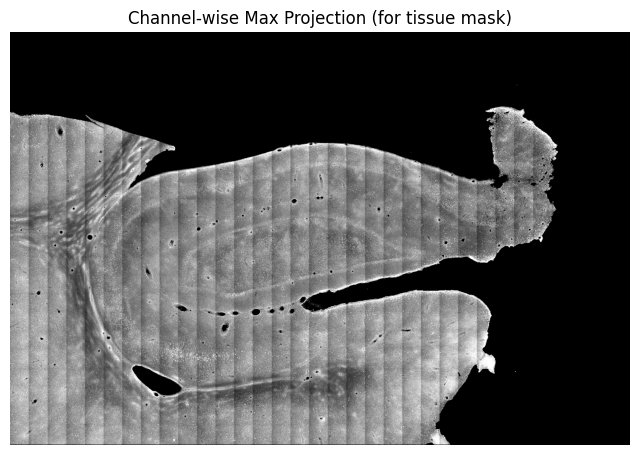

In [2]:
# @title Phase 2. Channel-wise Max Projection (Source for Tissue Mask)
# Since individual channels may be sparsely labeled, we collapse all channels
# into one image that captures any tissue signal anywhere. This drives a
# single global tissue mask that every channel reuses during processing.

combined_mip = np.max(original_images, axis=0)
print(f"combined_mip shape: {combined_mip.shape}, dtype: {combined_mip.dtype}")

plt.figure(figsize=(8, 8))
plt.imshow(combined_mip[::10, ::10], cmap="gray")
plt.title("Channel-wise Max Projection (for tissue mask)")
plt.axis("off")
plt.show()


In [3]:
# @title Phase 3. Define Helper Functions

import math
import warnings
import numpy as np
import matplotlib.pyplot as plt

from skimage import morphology, transform, exposure, filters, util
from scipy import ndimage, signal, stats, interpolate
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
from numpy.polynomial import Polynomial
import gc

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


def tony_isolate_tissue(img, disksize=0.1, threshold=0.5, cutoff_multiplier=1.05, verbose=False):
    smallimg = img[::10, ::10]
    meanimsize = np.mean(smallimg.shape)
    meanimsize = (meanimsize + np.max(smallimg.shape)) / 2.0

    radius_k = max(1, int(round(disksize * 100)))
    es = morphology.closing(smallimg, morphology.disk(radius_k))
    radius_es = max(1, int(round(disksize * 0.1 * meanimsize)))
    es = morphology.opening(es, morphology.disk(radius_es))
    es_norm = exposure.rescale_intensity(es, out_range=(0, 1))

    ks = es_norm > threshold
    radius_se = max(1, int(round(disksize * 0.1 * meanimsize)))
    ks = morphology.closing(ks, morphology.disk(radius_se))
    ks = ndimage.binary_fill_holes(ks)

    bg_pixels = smallimg[~ks]
    lowcutoff1 = np.mean(bg_pixels) if len(bg_pixels) > 0 else np.mean(smallimg)
    lowcutoff2 = np.percentile(img, 50)
    lowcutoff = cutoff_multiplier * np.mean([lowcutoff1, lowcutoff2])

    mask = np.zeros_like(img, dtype=bool)
    mask[img >= lowcutoff] = True
    mask = morphology.remove_small_objects(mask, min_size=2)
    mask = morphology.remove_small_objects(mask, min_size=100)

    radius_final = max(1, int(round(meanimsize * 0.0025)))
    mask = morphology.dilation(mask, morphology.disk(radius_final))
    return mask


def detect_dominant_freq(data, sampling_rate=1.0, min_tiles_in_signal=8,
                         max_freq_factor=0.35, min_tile_period_px=20.0,
                         strong_peak_fraction=0.50,
                         reject_subharmonics=True,
                         subharmonic_tol_bins=3,
                         return_details=False):
    """Estimate the tile *fundamental* frequency in a 1D intensity profile.

    Phase 4 needs the tile interval, not the broad vignette/background period,
    not a higher harmonic, AND not a sub-harmonic. The selection rule is:

      1. Ignore DC and very-low-frequency background terms by requiring at
         least ``min_tiles_in_signal`` tile cycles along the measured axis.
      2. Find peaks in the FFT magnitude inside a plausible tile band.
      3. If ``reject_subharmonics`` is True (the default), discard any peak
         whose spectrum has a STRONGER peak at twice its frequency -- such a
         peak is a sub-harmonic of the true fundamental sitting at 2x.
      4. Among the survivors, take the first/lowest-frequency peak whose
         height is at least ``strong_peak_fraction`` of the strongest peak
         in the band.

    The sub-harmonic rejection (step 3) is the fix for the failure mode where
    every-other-tile structure (or stitching artifacts spanning tile pairs)
    creates an FFT peak at f0/2 that beats the true fundamental f0 under the
    "first strong peak" rule. For any candidate ``c``, if magnitude(2c) >
    magnitude(c), then ``c`` is treated as a sub-harmonic and skipped.

    Parameters
    ----------
    data : 1D array
        Mean-intensity profile along one image axis.
    sampling_rate : float
        Samples per pixel-equivalent unit. Keep at 1.0 for pixel profiles.
    min_tiles_in_signal : int
        Minimum number of tile cycles that must fit in the axis.
    max_freq_factor : float
        Upper frequency limit as a fraction of the Nyquist frequency.
    min_tile_period_px : float
        Reject peaks whose period is shorter than this many sampled pixels.
    strong_peak_fraction : float
        A peak counts as a fundamental candidate if its FFT magnitude is at
        least this fraction of the strongest in-band peak.
    reject_subharmonics : bool
        If True, drop any candidate ``c`` for which the spectrum has a
        stronger peak at frequency 2c (i.e. ``c`` is the sub-harmonic of
        the true fundamental at 2c).
    subharmonic_tol_bins : int
        FFT-bin half-width used when looking up the magnitude at 2c (we
        check ``[2*peak_idx - tol, 2*peak_idx + tol]``). Default 3 is enough
        to cover spectral leakage with a Hann window on typical profiles.
    return_details : bool
        Also return a dict of peak-selection diagnostics for the Phase 4 plot.

    Returns
    -------
    dom_freq : float
        Selected frequency in cycles per sampled pixel. 0.0 if unavailable.
    frequencies, magnitude : ndarray
        RFFT frequency axis and magnitude spectrum for plotting.
    details : dict, optional
        Returned only when ``return_details=True``.
    """
    y = np.asarray(data, dtype=np.float64).ravel()
    n = int(y.size)
    if n < 4:
        frequencies = np.fft.rfftfreq(max(n, 1), d=1.0 / sampling_rate)
        magnitude = np.zeros_like(frequencies)
        details = {
            'peaks_idx': np.array([], dtype=int),
            'strong_peaks_idx': np.array([], dtype=int),
            'rejected_subharmonics_idx': np.array([], dtype=int),
            'selected_idx': None,
            'f_min': 0.0, 'f_max': 0.0,
            'selection_mode': 'too_short',
        }
        return (0.0, frequencies, magnitude, details) if return_details else (0.0, frequencies, magnitude)

    finite = np.isfinite(y)
    if not np.any(finite):
        y = np.zeros_like(y)
    else:
        fill = float(np.nanmean(y[finite]))
        y = np.where(finite, y, fill)

    try:
        y_work = signal.detrend(y, type='linear')
    except Exception:
        y_work = y - np.mean(y)
    y_work = y_work - np.mean(y_work)

    window = np.hanning(n)
    coherent_gain = max(float(np.mean(window)), 1e-12)
    spectrum = np.fft.rfft(y_work * window)
    frequencies = np.fft.rfftfreq(n, d=1.0 / sampling_rate)
    magnitude = np.abs(spectrum) / (max(n, 1) * coherent_gain)
    if magnitude.size:
        magnitude[0] = 0.0

    if len(frequencies) <= 2 or np.all(magnitude <= 0):
        details = {
            'peaks_idx': np.array([], dtype=int),
            'strong_peaks_idx': np.array([], dtype=int),
            'rejected_subharmonics_idx': np.array([], dtype=int),
            'selected_idx': None,
            'f_min': 0.0, 'f_max': 0.0,
            'selection_mode': 'empty_spectrum',
        }
        return (0.0, frequencies, magnitude, details) if return_details else (0.0, frequencies, magnitude)

    nyquist = 0.5 * sampling_rate
    f_min = max((float(min_tiles_in_signal) / max(n, 1)) * sampling_rate,
                frequencies[1] if len(frequencies) > 1 else 0.0)
    f_max = max_freq_factor * nyquist
    if min_tile_period_px is not None and min_tile_period_px > 0:
        f_max = min(f_max, sampling_rate / float(min_tile_period_px))
    if f_max <= f_min:
        f_min = frequencies[1] if len(frequencies) > 1 else 0.0
        f_max = nyquist

    in_band = (frequencies >= f_min) & (frequencies <= f_max)
    band_idx = np.flatnonzero(in_band)
    if band_idx.size == 0:
        peak_idx = int(np.argmax(magnitude[1:]) + 1)
        details = {
            'peaks_idx': np.array([peak_idx], dtype=int),
            'strong_peaks_idx': np.array([peak_idx], dtype=int),
            'rejected_subharmonics_idx': np.array([], dtype=int),
            'selected_idx': peak_idx,
            'f_min': float(f_min), 'f_max': float(f_max),
            'selection_mode': 'fallback_no_band',
        }
        return (float(frequencies[peak_idx]), frequencies, magnitude, details) if return_details else (float(frequencies[peak_idx]), frequencies, magnitude)

    band_mag = magnitude[band_idx]
    band_max = float(np.max(band_mag))
    if band_max <= 0:
        details = {
            'peaks_idx': np.array([], dtype=int),
            'strong_peaks_idx': np.array([], dtype=int),
            'rejected_subharmonics_idx': np.array([], dtype=int),
            'selected_idx': None,
            'f_min': float(f_min), 'f_max': float(f_max),
            'selection_mode': 'zero_band',
        }
        return (0.0, frequencies, magnitude, details) if return_details else (0.0, frequencies, magnitude)

    band_med = float(np.median(band_mag))
    band_mad = float(np.median(np.abs(band_mag - band_med))) * 1.4826
    height_floor = max(band_med + 1.0 * band_mad, 0.05 * band_max)
    all_peaks, _ = signal.find_peaks(magnitude, height=height_floor)
    peaks = all_peaks[in_band[all_peaks]] if all_peaks.size else np.array([], dtype=int)

    rejected_subharmonics = []

    def _mag_at_2x(p_idx, tol=subharmonic_tol_bins):
        """Largest magnitude in a small window around 2*p_idx, or 0 if 2*p_idx
        is past the end of the spectrum."""
        target = 2 * int(p_idx)
        if target >= len(magnitude):
            return 0.0
        lo = max(0, target - int(tol))
        hi = min(len(magnitude), target + int(tol) + 1)
        return float(np.max(magnitude[lo:hi])) if hi > lo else 0.0

    if peaks.size == 0:
        selected_idx = int(band_idx[int(np.argmax(band_mag))])
        if reject_subharmonics:
            mag_at_2x = _mag_at_2x(selected_idx)
            if mag_at_2x > magnitude[selected_idx]:
                rejected_subharmonics.append(int(selected_idx))
                # Try the true fundamental at ~2x within the band
                twice = 2 * selected_idx
                if twice < len(magnitude) and in_band[twice]:
                    selected_idx = int(twice)
        strong_peaks = np.array([selected_idx], dtype=int)
        selection_mode = 'in_band_argmax'
    else:
        heights = magnitude[peaks]
        peak_max = float(np.max(heights))
        strong_peaks = peaks[heights >= strong_peak_fraction * peak_max]
        if strong_peaks.size == 0:
            selected_idx = int(peaks[int(np.argmax(heights))])
            strong_peaks = np.array([selected_idx], dtype=int)
            selection_mode = 'peak_argmax'
        else:
            # Apply sub-harmonic rejection BEFORE picking the lowest-freq one.
            if reject_subharmonics:
                kept_mask = np.ones(len(strong_peaks), dtype=bool)
                for i, p_idx in enumerate(strong_peaks):
                    mag_at_2x = _mag_at_2x(p_idx)
                    if mag_at_2x > magnitude[int(p_idx)]:
                        kept_mask[i] = False
                        rejected_subharmonics.append(int(p_idx))
                survivors = strong_peaks[kept_mask]
                if survivors.size > 0:
                    strong_peaks = survivors
                # else: all candidates look like sub-harmonics, fall through
                #       to "first strong peak" anyway (something is unusual
                #       about this spectrum; manual override is the answer).
            selected_idx = int(strong_peaks[np.argmin(frequencies[strong_peaks])])
            selection_mode = ('first_strong_peak_no_subharmonics'
                              if reject_subharmonics
                              else 'first_strong_peak')

    dom_freq = float(frequencies[selected_idx]) if selected_idx is not None else 0.0
    details = {
        'peaks_idx': peaks.astype(int),
        'strong_peaks_idx': strong_peaks.astype(int),
        'rejected_subharmonics_idx': np.array(rejected_subharmonics, dtype=int),
        'selected_idx': int(selected_idx) if selected_idx is not None else None,
        'f_min': float(f_min), 'f_max': float(f_max),
        'strong_peak_fraction': float(strong_peak_fraction),
        'selection_mode': selection_mode,
    }
    if return_details:
        return dom_freq, frequencies, magnitude, details
    return dom_freq, frequencies, magnitude

def remove_outliers_and_fill(data):
    data = np.nan_to_num(data, nan=np.nanmean(data))
    z_scores = np.abs(stats.zscore(data))
    valid_mean = np.mean(data[z_scores <= 3]) if np.any(z_scores <= 3) else np.mean(data)
    data[z_scores > 3] = valid_mean
    data[:5] = valid_mean
    return data


def compute_row_col_profiles(img2d):
    """Mean intensity per row/col, ignoring zeros, with outlier cleanup."""
    row_sums = np.sum(img2d, axis=1, dtype=np.float64)
    row_counts = np.sum(img2d > 0, axis=1)
    row_counts[row_counts == 0] = 1
    avg_col_intensity = row_sums / row_counts

    col_sums = np.sum(img2d, axis=0, dtype=np.float64)
    col_counts = np.sum(img2d > 0, axis=0)
    col_counts[col_counts == 0] = 1
    avg_row_intensity = col_sums / col_counts

    avg_row_intensity = remove_outliers_and_fill(avg_row_intensity)
    avg_col_intensity = remove_outliers_and_fill(avg_col_intensity)
    avg_row_intensity = signal.medfilt(avg_row_intensity, kernel_size=11)
    avg_col_intensity = signal.medfilt(avg_col_intensity, kernel_size=11)
    return avg_row_intensity, avg_col_intensity


def pad_bg_with_tissue_mean(img, mask):
    """Replace pixels outside `mask` with the mean intensity of non-zero
    pixels inside `mask`. Returns a float32 image; the FFT then never sees
    the sharp tissue/background edge that produces ringing artifacts.
    """
    out = img.astype(np.float32, copy=True)
    inside = img[mask]
    inside_nz = inside[inside > 0]
    if inside_nz.size > 0:
        mean_val = float(np.mean(inside_nz))
    elif inside.size > 0:
        mean_val = float(np.mean(inside))
    else:
        mean_val = float(np.mean(img))
    out[~mask] = mean_val
    return out, mean_val


def tony_bandpass_filter(input_image, filter_large, filter_small,
                         suppress_direction='none', tolerance_percent=5):
    rows, cols = input_image.shape
    max_n = max(rows, cols)
    exponent = math.ceil(math.log2(1.5 * max_n))
    pad_size = 2 ** exponent

    pad_top = (pad_size - rows) // 2
    pad_left = (pad_size - cols) // 2
    pad_rows_post = pad_size - rows - pad_top
    pad_cols_post = pad_size - cols - pad_left
    padded_image = np.pad(
        input_image,
        ((pad_top, pad_rows_post), (pad_left, pad_cols_post)),
        mode='symmetric',
    )

    fft_image = np.fft.fftshift(np.fft.fft2(padded_image))

    y_idx = np.linspace(-pad_size / 2, pad_size / 2 - 1, pad_size, dtype=np.float32)
    x_idx = np.linspace(-pad_size / 2, pad_size / 2 - 1, pad_size, dtype=np.float32)
    X, Y = np.meshgrid(x_idx, y_idx, sparse=True)

    a = (2.0 * filter_large) / pad_size
    b = (2.0 * filter_small) / pad_size
    R2 = X ** 2 + Y ** 2
    H_large = np.exp(-R2 * (a ** 2))
    H_small = np.exp(-R2 * (b ** 2))
    filter_mask = (1.0 - H_large) * H_small

    direction = str(suppress_direction).lower()
    if direction != "none":
        sharpness = (100 - tolerance_percent) / 100.0
        s = max(sharpness ** 2, 1e-10)
        if direction == "horizontal":
            filter_mask *= (1.0 - np.exp(-(X ** 2) * s))
        elif direction == "vertical":
            filter_mask *= (1.0 - np.exp(-(Y ** 2) * s))

    center = pad_size // 2
    filter_mask[center, center] = 1.0

    fft_image *= filter_mask
    filtered_padded = np.real(np.fft.ifft2(np.fft.ifftshift(fft_image)))
    filtered_image = filtered_padded[pad_top:pad_top + rows, pad_left:pad_left + cols]
    return filtered_image.astype(np.float32), filter_mask


def extract_morph_profiles(input_img, mask, dom_col_freq, dom_row_freq,
                           median_k=15, sigma_s=0):
    if hasattr(morphology, 'footprint_rectangle'):
        make_rect = morphology.footprint_rectangle
    else:
        make_rect = morphology.rectangle

    profiles = []
    freqs = [dom_row_freq, dom_col_freq]

    def get_auto_sigma(freq_val, default=2.0):
        if freq_val is not None and freq_val > 0:
            period_px = 1.0 / freq_val
            return max(1.0, period_px * 0.02)
        return default

    current_img = input_img.astype(np.float32)
    current_mask = mask

    for step in range(2):
        if step == 1:
            current_img = current_img.T
            current_mask = current_mask.T
            current_freq = freqs[1]
        else:
            current_freq = freqs[0]

        B_min, B_max = current_img.min(), current_img.max()
        B_norm = (current_img - B_min) / (B_max - B_min + 1e-6)

        se_disk = morphology.disk(10)
        tophat = morphology.white_tophat(B_norm, se_disk)
        img_without_points = B_norm - tophat
        np.clip(img_without_points, 0, 1, out=img_without_points)
        del tophat

        se_line = make_rect((1, 100))
        closed_img = morphology.closing(img_without_points, se_line)
        illumination_img = morphology.opening(closed_img, se_line)
        illumination_img[illumination_img == 0] = 1e-6
        del closed_img

        result = img_without_points / illumination_img
        del illumination_img, img_without_points
        result *= current_mask

        r_min, r_max = result.min(), result.max()
        result_norm = (result - r_min) / (r_max - r_min + 1e-6)
        del result

        divimage = result_norm / (B_norm + 1e-6)
        del B_norm, result_norm

        divimage[current_mask == 0] = np.nan
        column_means = np.nanmean(divimage, axis=1)
        del divimage
        gc.collect()

        valid_mean = np.nanmean(column_means)
        if np.isnan(valid_mean):
            valid_mean = 1.0
        inds = np.arange(len(column_means))
        valid = ~np.isnan(column_means)

        if np.sum(valid) > 0:
            f = interpolate.interp1d(inds[valid], column_means[valid],
                                     kind='linear', fill_value="extrapolate")
            column_means_filled = f(inds)
        else:
            column_means_filled = np.ones_like(column_means) * valid_mean

        k_use = median_k if median_k % 2 == 1 else median_k + 1
        column_means_filled = signal.medfilt(column_means_filled, kernel_size=k_use)

        calc_sigma = sigma_s if sigma_s > 0 else get_auto_sigma(current_freq)
        column_means_filled = ndimage.gaussian_filter1d(column_means_filled, sigma=calc_sigma)

        window_size = int(round(0.75 * (1.0 / current_freq))) if current_freq > 0 else 50
        if window_size < 3:
            window_size = 3

        def get_envelope(data, dist):
            peaks, _ = signal.find_peaks(data, distance=dist)
            if len(peaks) > 1:
                f_env = interpolate.interp1d(peaks, data[peaks],
                                             kind='linear', fill_value="extrapolate")
                return f_env(np.arange(len(data)))
            return np.full_like(data, np.max(data))

        upper_env = get_envelope(column_means_filled, window_size)
        lower_env = get_envelope(-column_means_filled, window_size) * -1

        denom = (upper_env - lower_env)
        denom[denom == 0] = 1e-6
        normalized_waveform = (column_means_filled - lower_env) / denom

        prerange = np.nanmean(current_img, axis=1)
        p_min, p_max = prerange.min(), prerange.max()
        prerange = (prerange - p_min) / (p_max - p_min + 1e-6)

        low_pre_env = get_envelope(-prerange, window_size) * -1
        high_pre_env = get_envelope(prerange, window_size)
        prc_increase = high_pre_env / (low_pre_env + 1e-6)

        n_len = len(prc_increase)
        middle_half = prc_increase[n_len // 4: 3 * n_len // 4]
        middle_half_mean = np.mean(middle_half) if len(middle_half) > 0 else 1.0

        norm_max = np.max(normalized_waveform) if np.max(normalized_waveform) != 0 else 1
        normalized_curve = normalized_waveform / norm_max
        y = normalized_curve * (middle_half_mean - 1) + 1

        try:
            peak_dist = int(0.8 * (1.0 / current_freq)) if current_freq > 0 else 10
            peaks, _ = signal.find_peaks(y, distance=max(1, peak_dist))
        except Exception:
            peaks = np.array([], dtype=int)
        y_smoothed = y.copy()

        for i in range(len(peaks) - 1):
            decay_start = peaks[i]
            decay_end = peaks[i + 1]
            if decay_end > decay_start:
                segment = y[decay_start:decay_end]
                win_smooth = min(51, len(segment))
                if win_smooth > 0:
                    y_smoothed[decay_start:decay_end] = ndimage.uniform_filter1d(segment, size=win_smooth)

        if dom_row_freq > 0 and dom_col_freq > 0:
            mean_tile_size = (1.0 / dom_row_freq + 1.0 / dom_col_freq) / 2.0
            sg_win = int(0.015 * mean_tile_size)
            if sg_win % 2 == 0:
                sg_win += 1
            if sg_win < 3:
                sg_win = 3
            try:
                ystemp = signal.savgol_filter(y_smoothed, window_length=sg_win, polyorder=1)
                y_smoothed = (y_smoothed + ystemp) / 2.0
            except Exception:
                pass

        y_smoothed[y_smoothed < 1] = 1.0
        profiles.append(y_smoothed)

        y_smoothed_matrix = np.tile(y_smoothed[:, None], (1, current_img.shape[1]))
        current_img *= y_smoothed_matrix
        del y_smoothed_matrix
        gc.collect()

    return profiles[0], profiles[1]


def calculate_dip_correction(profile, window_size=51, poly_order=7,
                             outlier_sigma=2.0, ignore_edge_px=501):
    N = len(profile)
    x = np.arange(N)

    rolling_med = ndimage.median_filter(profile, size=window_size)
    residuals = profile - rolling_med
    mad = np.median(np.abs(residuals - np.median(residuals)))
    threshold = outlier_sigma * mad * 1.4826
    is_dip = (profile < (rolling_med - threshold))
    is_good = (~is_dip) & (profile > 1e-6) & np.isfinite(profile)

    if np.sum(is_good) < poly_order + 1:
        return np.ones_like(profile), np.zeros_like(profile), profile, is_dip

    try:
        p_fit = Polynomial.fit(x[is_good], profile[is_good], deg=poly_order)
        baseline_trend = p_fit(x)
    except Exception:
        baseline_trend = rolling_med

    baseline_trend = np.maximum(baseline_trend, 1e-6)
    actual_smooth = signal.savgol_filter(profile, window_length=window_size, polyorder=3)
    actual_smooth = np.maximum(actual_smooth, 1e-6)

    multiplier = baseline_trend / actual_smooth
    multiplier = np.maximum(multiplier, 1.0)
    multiplier = signal.savgol_filter(multiplier, window_length=window_size * 2 + 1, polyorder=3)
    multiplier = np.maximum(multiplier, 1.0)

    if ignore_edge_px > 0 and N > ignore_edge_px:
        multiplier[-ignore_edge_px:] = 1.0
    return multiplier, baseline_trend, actual_smooth, is_dip


def apply_targeted_contrast_smooth(image, profile, strength=0.2, poly_deg=2,
                                   background_percentile=1.0, gain_smoothing=50,
                                   ignore_edge_px=501):
    h, w = image.shape
    if len(profile) != w:
        x_old = np.linspace(0, 1, len(profile))
        x_new = np.linspace(0, 1, w)
        profile = np.interp(x_new, x_old, profile)
    x = np.arange(w)

    valid_threshold = np.median(profile) * 0.1
    is_valid = profile > valid_threshold
    is_valid = ndimage.binary_erosion(is_valid, structure=np.ones(50))

    if np.sum(is_valid) < poly_deg + 1:
        return image, np.zeros_like(profile), np.ones_like(profile)

    try:
        p_fit = Polynomial.fit(x[is_valid], profile[is_valid], deg=poly_deg)
        baseline = p_fit(x)
    except Exception:
        baseline = np.full_like(profile, np.mean(profile[is_valid]))

    diff = profile - baseline
    mask_peaks = (diff > 0) & is_valid
    max_diff = np.max(diff[mask_peaks]) if np.any(mask_peaks) else 1.0
    normalized_diff = np.zeros_like(diff)
    normalized_diff[mask_peaks] = diff[mask_peaks] / max_diff

    contrast_multiplier = 1.0 + (normalized_diff * strength)
    contrast_multiplier = ndimage.gaussian_filter1d(contrast_multiplier, sigma=gain_smoothing)
    contrast_multiplier[~is_valid] = 1.0
    if ignore_edge_px > 0 and w > ignore_edge_px:
        contrast_multiplier[-ignore_edge_px:] = 1.0

    valid_indices = np.where(is_valid)[0]
    if len(valid_indices) > 0:
        start, end = valid_indices[0], valid_indices[-1]
        img_subset = image[::10, start:end:10]
        bg_val = np.percentile(img_subset, background_percentile) if img_subset.size > 0 else 0.0
    else:
        bg_val = 0.0

    img_float = image.astype(np.float32)
    signal_component = img_float - bg_val
    boosted_signal = signal_component * contrast_multiplier[None, :]
    result = boosted_signal + bg_val
    np.clip(result, 0, 65535.0, out=result)
    return result, baseline, contrast_multiplier


def apply_variance_equalization_smooth(image, smoothing_window=501,
                                       gain_smoothing=50, ignore_edge_px=501):
    h, w = image.shape
    col_mean = np.mean(image, axis=0)
    col_std = np.std(image, axis=0)

    valid_threshold = np.median(col_mean) * 0.1
    is_valid = col_mean > valid_threshold
    is_valid = ndimage.binary_erosion(is_valid, structure=np.ones(50))

    target_std = ndimage.median_filter(col_std, size=smoothing_window)
    target_std = ndimage.gaussian_filter1d(target_std, sigma=50)

    epsilon = 1e-6
    gain_map = target_std / (col_std + epsilon)
    gain_map = np.clip(gain_map, 0.8, 3.0)
    gain_map = ndimage.gaussian_filter1d(gain_map, sigma=gain_smoothing)
    gain_map[~is_valid] = 1.0
    if ignore_edge_px > 0 and w > ignore_edge_px:
        gain_map[-ignore_edge_px:] = 1.0

    img_float = image.astype(np.float32)
    centered = img_float - col_mean[None, :]
    corrected = centered * gain_map[None, :]
    result = corrected + col_mean[None, :]
    np.clip(result, 0, 65535.0, out=result)
    return result, col_std, target_std, gain_map



# ---------------------------------------------------------------------------
# Tile-only FFT bandpass, MATLAB-style envelope correction, and the
# tonyRemoveLines2 port.
# ---------------------------------------------------------------------------
def tony_bandpass_filter(input_image, filter_large, filter_small=1,
                         suppress_direction='none', tolerance_percent=0):
    """Radial bandpass + optional axial NOTCH.

    Filter math:
        filter_mask = (1 - H_large) * H_small        # radial bandpass
        if 'horizontal':
            stripe_mask = 1 - exp(-X**2 * sharpness) # NOTCH the fy=0 axis
            filter_mask *= stripe_mask
        if 'vertical':
            stripe_mask = 1 - exp(-Y**2 * sharpness) # NOTCH the fx=0 axis
            filter_mask *= stripe_mask

    Suppresses both the vignetting envelope (low freq) and the tile-pattern
    axis (the notch). The OUTPUT IS the corrected image directly.

    Parameters
    ----------
    input_image : (H, W) array (any numeric dtype)
    filter_large : float
        Low-frequency cutoff in pixels. Periods larger than this are
        treated as vignetting and suppressed. Should be > tile period
        (rule of thumb: 1.5 to 3 x tile period).
    filter_small : float
        High-frequency cutoff in pixels (default 1 = essentially no
        high-frequency smoothing).
    suppress_direction : {'none', 'horizontal', 'vertical'}
        'horizontal' notches the fy=0 axis, removing horizontal stripes.
        'vertical' notches the fx=0 axis, removing vertical stripes.
    tolerance_percent : float
        0-100. 0 = sharpest notch. Higher = softer notch (wider tolerance
        for slight tile-grid misalignment).

    Returns
    -------
    filtered_image : (H, W) float32
    filter_mask : the full-padded frequency mask (for visualization)
    """
    rows, cols = input_image.shape
    max_n = max(rows, cols)
    exponent = math.ceil(math.log2(1.5 * max_n))
    pad_size = 2 ** exponent

    pad_top = (pad_size - rows) // 2
    pad_left = (pad_size - cols) // 2
    pad_rows_post = pad_size - rows - pad_top
    pad_cols_post = pad_size - cols - pad_left
    padded_image = np.pad(
        input_image,
        ((pad_top, pad_rows_post), (pad_left, pad_cols_post)),
        mode='symmetric',
    )
    fft_image = np.fft.fftshift(np.fft.fft2(padded_image))

    y_idx = np.linspace(-pad_size / 2, pad_size / 2 - 1, pad_size, dtype=np.float32)
    x_idx = np.linspace(-pad_size / 2, pad_size / 2 - 1, pad_size, dtype=np.float32)
    X, Y = np.meshgrid(x_idx, y_idx, sparse=True)

    a = (2.0 * float(filter_large)) / pad_size
    b = (2.0 * float(filter_small)) / pad_size
    R2 = X ** 2 + Y ** 2
    H_large = np.exp(-R2 * (a ** 2))
    H_small = np.exp(-R2 * (b ** 2))
    filter_mask = (1.0 - H_large) * H_small  # radial bandpass

    direction = str(suppress_direction).lower()
    if direction != 'none':
        sharpness = (100.0 - float(tolerance_percent)) / 100.0
        s = max(sharpness ** 2, 1e-10)
        if direction == 'horizontal':
            stripe_mask = 1.0 - np.exp(-(X ** 2) * s)
        elif direction == 'vertical':
            stripe_mask = 1.0 - np.exp(-(Y ** 2) * s)
        else:
            stripe_mask = np.ones_like(filter_mask)
        filter_mask = filter_mask * stripe_mask

    centre = pad_size // 2
    filter_mask[centre, centre] = 1.0  # preserve DC

    fft_image *= filter_mask
    filtered_padded = np.real(np.fft.ifft2(np.fft.ifftshift(fft_image)))
    filtered_image = filtered_padded[pad_top:pad_top + rows, pad_left:pad_left + cols]
    return filtered_image.astype(np.float32), filter_mask


def tony_tile_bandpass_filter(input_image, tile_period_px,
                              axial_width_factor=0.30,
                              filter_large_px=None,
                              filter_small_px=1,
                              dc_tolerance_percent=5):
    """Bandpass that targets ONLY tile-pattern energy on the kx/ky axes.

    A radially-symmetric bandpass (the original ``tony_bandpass_filter``)
    passes any frequency within an annulus, so broader tissue structures
    whose Fourier energy happens to fall in that annulus get filtered along
    with the tile artifacts. The resulting ratio map therefore reflects
    tissue topography, not just tile boundaries.

    This variant builds a *cross-shaped* mask in frequency space:
      * pass frequencies along the kx axis (|fy| small)  -> vertical tile lines
      * pass frequencies along the ky axis (|fx| small)  -> horizontal tile lines
      * everything off-axis (diagonal tissue structure) is suppressed
    A standard radial bandpass is multiplied on top to remove DC / vignetting
    envelope (period > filter_large_px) and high-frequency noise
    (period < filter_small_px).
    """
    rows, cols = input_image.shape
    max_n = max(rows, cols)
    exponent = math.ceil(math.log2(1.5 * max_n))
    pad_size = 2 ** exponent

    pad_top = (pad_size - rows) // 2
    pad_left = (pad_size - cols) // 2
    pad_rows_post = pad_size - rows - pad_top
    pad_cols_post = pad_size - cols - pad_left
    padded_image = np.pad(
        input_image,
        ((pad_top, pad_rows_post), (pad_left, pad_cols_post)),
        mode='symmetric',
    )
    fft_image = np.fft.fftshift(np.fft.fft2(padded_image))

    y_idx = np.linspace(-pad_size / 2, pad_size / 2 - 1, pad_size, dtype=np.float32)
    x_idx = np.linspace(-pad_size / 2, pad_size / 2 - 1, pad_size, dtype=np.float32)
    X, Y = np.meshgrid(x_idx, y_idx, sparse=True)

    if filter_large_px is None:
        filter_large_px = 1.5 * tile_period_px
    a = (2.0 * filter_large_px) / pad_size
    b = (2.0 * filter_small_px) / pad_size
    R2 = X ** 2 + Y ** 2
    softness = max((100 - dc_tolerance_percent) / 100.0, 1e-3)
    H_large = np.exp(-R2 * (a ** 2) * (softness ** 2))
    H_small = np.exp(-R2 * (b ** 2))
    radial_envelope = (1.0 - H_large) * H_small

    tile_freq_idx = pad_size / max(tile_period_px, 1.0)
    axial_sigma = max(2.0, axial_width_factor * tile_freq_idx)
    mask_along_fx = np.exp(-(Y ** 2) / (2.0 * axial_sigma ** 2))
    mask_along_fy = np.exp(-(X ** 2) / (2.0 * axial_sigma ** 2))
    axial_mask = np.maximum(mask_along_fx, mask_along_fy)

    filter_mask = radial_envelope * axial_mask
    centre = pad_size // 2
    filter_mask[centre, centre] = 1.0

    fft_image *= filter_mask
    filtered_padded = np.real(np.fft.ifft2(np.fft.ifftshift(fft_image)))
    filtered_image = filtered_padded[pad_top:pad_top + rows, pad_left:pad_left + cols]
    return filtered_image.astype(np.float32), filter_mask


def _envelope_from_peaks(data, distance, peak_distance_fraction=0.45,
                         smooth_fraction=0.035, guard_fraction=0.08):
    """Return smooth lower/upper peak envelopes tailored to the tile period.

    The previous implementation connected sparse extrema with straight-line
    ``np.interp`` segments.  When the extrema spacing was even slightly too
    large, the envelope became a set of long rigid chords that clipped real
    peaks/troughs in the mean-intensity profile.  This function is closer in
    spirit to MATLAB ``envelope(x, n, 'peak')``:

      * extrema are detected with a relaxed spacing derived from the supplied
        tile-size window, so each tile can contribute a peak/trough;
      * endpoint knots are local edge maxima/minima rather than arbitrary end
        values;
      * a shape-preserving PCHIP interpolator produces smooth envelopes
        without spline overshoot;
      * a final local guard prevents the upper envelope from falling below the
        profile, or the lower envelope from rising above it.

    Parameters
    ----------
    data : 1D array
        Profile to envelope.
    distance : int or float
        Tile-scaled window, usually 0.6-0.8 * tile_period as in the MATLAB
        code.  It controls both knot spacing and the small no-clipping guard.
    peak_distance_fraction : float
        Fraction of ``distance`` used as the minimum spacing between envelope
        knots.  Values below 1 are intentional; they avoid under-sampling the
        envelope when the detected tile period is a little large.
    smooth_fraction : float
        Gaussian sigma as a fraction of ``distance`` for a light smoothing pass.
    guard_fraction : float
        Local max/min guard width as a fraction of ``distance``.
    """
    y = np.asarray(data, dtype=np.float64).ravel()
    N = int(y.size)
    if N == 0:
        return y.copy(), y.copy()
    if N == 1:
        return y.copy(), y.copy()

    finite = np.isfinite(y)
    if not np.any(finite):
        y = np.zeros_like(y, dtype=np.float64)
    else:
        fill = float(np.nanmean(y[finite]))
        y = np.where(finite, y, fill).astype(np.float64)

    span = max(3, int(round(float(distance))))
    # The extrema spacing must be shorter than the envelope span.  The MATLAB
    # call uses n ~ 0.6-0.8 tile; using that literal value as scipy peak
    # distance misses valid extrema and creates long chord-like envelopes.
    peak_dist = max(2, int(round(peak_distance_fraction * span)))
    peak_dist = min(peak_dist, max(2, N - 1))

    def _edge_extrema_indices(arr, want_upper=True):
        edge_w = max(3, int(round(0.5 * span)))
        edge_w = min(edge_w, N)
        left_slice = arr[:edge_w]
        right_slice = arr[N - edge_w:]
        if want_upper:
            left = int(np.argmax(left_slice))
            right = int(N - edge_w + np.argmax(right_slice))
        else:
            left = int(np.argmin(left_slice))
            right = int(N - edge_w + np.argmin(right_slice))
        return left, right

    def _fit_env(want_upper=True):
        work = y if want_upper else -y
        peaks, _ = signal.find_peaks(work, distance=peak_dist)
        left_ext, right_ext = _edge_extrema_indices(y, want_upper=want_upper)
        idx = np.unique(np.concatenate(([0, left_ext], peaks.astype(int), [right_ext, N - 1]))).astype(int)
        idx = idx[(idx >= 0) & (idx < N)]
        idx.sort()

        # Endpoint values are local edge extrema.  This avoids pulling the
        # envelope down/up just because the image starts inside a dip/peak.
        vals = y[idx].astype(np.float64, copy=True)
        if want_upper:
            left_val = max(float(y[0]), float(y[left_ext]))
            right_val = max(float(y[-1]), float(y[right_ext]))
        else:
            left_val = min(float(y[0]), float(y[left_ext]))
            right_val = min(float(y[-1]), float(y[right_ext]))
        vals[idx == 0] = left_val
        vals[idx == (N - 1)] = right_val

        if idx.size >= 2:
            try:
                env = interpolate.PchipInterpolator(idx.astype(np.float64), vals, extrapolate=True)(np.arange(N, dtype=np.float64))
            except Exception:
                env = np.interp(np.arange(N, dtype=np.float64), idx.astype(np.float64), vals)
        else:
            env = np.full(N, float(np.max(y) if want_upper else np.min(y)), dtype=np.float64)

        # If the smooth curve still clips pronounced extrema, add the worst
        # violating local extrema and refit.  Two iterations are enough in
        # practice and keep the envelope from chasing pixel noise.
        for _ in range(2):
            if want_upper:
                resid = y - env
            else:
                resid = env - y
            violating = np.flatnonzero(resid > 1e-9)
            if violating.size == 0:
                break
            add_peaks, _ = signal.find_peaks(np.where(resid > 0, resid, 0.0), distance=peak_dist)
            add_peaks = add_peaks[resid[add_peaks] > 1e-9]
            if add_peaks.size == 0:
                add_peaks = np.array([int(violating[int(np.argmax(resid[violating]))])], dtype=int)
            idx = np.unique(np.concatenate((idx, add_peaks.astype(int)))).astype(int)
            idx.sort()
            vals = y[idx].astype(np.float64, copy=True)
            if want_upper:
                vals[idx == 0] = max(float(y[0]), float(y[left_ext]))
                vals[idx == (N - 1)] = max(float(y[-1]), float(y[right_ext]))
            else:
                vals[idx == 0] = min(float(y[0]), float(y[left_ext]))
                vals[idx == (N - 1)] = min(float(y[-1]), float(y[right_ext]))
            try:
                env = interpolate.PchipInterpolator(idx.astype(np.float64), vals, extrapolate=True)(np.arange(N, dtype=np.float64))
            except Exception:
                env = np.interp(np.arange(N, dtype=np.float64), idx.astype(np.float64), vals)
        return env

    upper = _fit_env(want_upper=True)
    lower = _fit_env(want_upper=False)

    sigma = max(0.0, smooth_fraction * span)
    if sigma >= 0.75 and N > 5:
        upper = ndimage.gaussian_filter1d(upper, sigma=sigma, mode='nearest')
        lower = ndimage.gaussian_filter1d(lower, sigma=sigma, mode='nearest')

    guard_w = max(3, int(round(guard_fraction * span)))
    guard_w = min(guard_w, N)
    if guard_w % 2 == 0 and guard_w < N:
        guard_w += 1
    local_max = ndimage.maximum_filter1d(y, size=max(1, guard_w), mode='nearest')
    local_min = ndimage.minimum_filter1d(y, size=max(1, guard_w), mode='nearest')
    upper = np.maximum(upper, local_max)
    lower = np.minimum(lower, local_min)

    # Final pointwise no-clipping guarantee and sane ordering.
    upper = np.maximum(upper, y)
    lower = np.minimum(lower, y)
    crossed = lower > upper
    if np.any(crossed):
        mid = 0.5 * (lower[crossed] + upper[crossed])
        lower[crossed] = mid
        upper[crossed] = mid
    return lower.astype(np.float64), upper.astype(np.float64)


def matlab_style_axis_correction(image, mask, dom_freq, axis='row',
                                 overshoot_exponent=1.5,
                                 bg_subtract_factor=0.5,
                                 tissue_floor_percentile=1.0,
                                 envelope_window_factor=1.5,
                                 rescale_window_factor=1.0,
                                 return_diag=False):
    """One-axis envelope-based multiplicative correction, ported from
    ``VISTAmap_v2.mlx`` (Anthony Fung, UCSD).

    Algorithm (per axis):
      1. Compute mean intensity profile along the axis using only tissue
         pixels (NaN outside mask).
      2. Median-smooth, then find upper/lower envelopes by interpolating
         between local maxima and minima. ``ideal = (lower + upper) / 2``.
      3. ``rescale = ideal / profile``, Savitzky-Golay smoothed, clipped >= 1.
      4. Normalize using the UPPER envelope of ``rescale``:
            envrng = upper_env(rescale) - 1
            envnorm = (rescale - 1) / envrng
            rescale_normed = 1 + envnorm * (mean_peaks - 1)
         (In the .mlx, ``envelope`` returns ``[yupper, ylower]`` -- the script
         assigns them to ``[l, h]`` and uses ``envrng = l - 1``, so ``l`` is
         the UPPER envelope. Using the lower envelope collapses the
         denominator to ~0 and produces a "completely wrong" surface.)
      5. Raise to ``overshoot_exponent`` (gives the bg-subtract step room
         to operate without flattening the multiplier elsewhere).
      6. Mild bright-peak attenuation (~0.99 where profile > ideal).
      7. Apply 1D multiplier; subtract
         ``bg_subtract_factor * bg_floor * (multiplier - 1)`` inside the
         tissue mask so the background isn't amplified along with signal.

    All scipy filtering is done in float64 (some scipy ``savgol_filter`` /
    ``medfilt`` versions are picky about dtype). The returned multiplier and
    corrected image are cast back to float32.

    Parameters
    ----------
    image : (H, W) array
    mask : (H, W) bool
    dom_freq : float
        Dominant tile frequency (cycles / pixel) at the same scale as ``image``.
        Used to set every window size in the pipeline (median, Sav-Gol, peak
        separation, envelope window), so good input from Phase 4 is critical.
    axis : 'row' or 'col'
        'row' -> multiplier of length H, applied as ``mult[:, None]``
        'col' -> multiplier of length W, applied as ``mult[None, :]``
    return_diag : bool
        If True, also return a dict with every intermediate signal for the
        Phase 6 diagnostic plot.

    Returns
    -------
    corrected : (H, W) float32
    multiplier_1d : 1D float32
    diag : dict (only if ``return_diag`` is True)
    """
    h, w = image.shape
    img_f = image.astype(np.float32, copy=True)

    # --- Mean profile along the chosen axis (tissue-masked) ---
    masked = img_f.astype(np.float64, copy=True)
    masked[~mask] = np.nan
    if axis == 'row':
        profile = np.nanmean(masked, axis=1)
        N = h
    else:
        profile = np.nanmean(masked, axis=0)
        N = w
    del masked

    finite = np.isfinite(profile)
    if not np.any(finite):
        if return_diag:
            return img_f, np.ones(N, dtype=np.float32), {}
        return img_f, np.ones(N, dtype=np.float32)
    fill_val = float(np.nanmean(profile))
    profile = np.where(finite, profile, fill_val).astype(np.float64)

    # Edge pixels are often noisy: clamp the first/last few to the next
    # interior value so they don't drag the envelope down.
    edge_n = max(1, min(5, N // 200))
    if edge_n < N:
        profile[:edge_n] = profile[edge_n]
        profile[-edge_n:] = profile[-edge_n - 1]

    # --- Window sizes derived from Phase 4 tile frequency ---
    if dom_freq is not None and dom_freq > 0:
        tile_period = 1.0 / dom_freq
    else:
        tile_period = max(N / 20.0, 50.0)
    tile_period = float(min(tile_period, N / 2.0))   # ensure >= 2 periods in N

    win_env1 = max(5, int(round(envelope_window_factor * tile_period)))  # first env (on profile)
    # NOTE: in v6 this was 0.8; v8 default 1.5 widens the envelope so it
    # tracks the slow signal trend instead of clinging to every tile dip.
    win_env2 = max(5, int(round(rescale_window_factor * tile_period)))  # second env (on rescale)
    # NOTE: in v6 this was 0.6; v8 default 1.0 is similarly looser.
    sg_win = 2 * int(round(0.5 * tile_period)) + 1     # Savitzky-Golay window
    sg_win = max(5, sg_win)
    if sg_win >= N:
        sg_win = max(5, (N // 2) | 1)
    if sg_win % 2 == 0:
        sg_win += 1
    sg_order = min(5, max(1, sg_win - 1))
    # Median filter window: 2% of a tile period
    k_med = max(3, int(round(0.02 * tile_period)))
    if k_med % 2 == 0:
        k_med += 1
    k_med = min(k_med, N - 1 if N % 2 == 0 else N)
    if k_med % 2 == 0:
        k_med -= 1

    profile_smooth = signal.medfilt(profile, kernel_size=k_med).astype(np.float64)

    # --- (1) Envelopes & ideal line on the (smoothed) profile ---
    env_lo, env_up = _envelope_from_peaks(profile_smooth, distance=win_env1)
    ideal = 0.5 * (env_lo + env_up)

    # --- (2) Raw rescale, sgolay-smooth, clip in [1, RESCALE_MAX] ---
    # Floor the denominator at a robust fraction of the profile's typical
    # value so a single near-zero pixel can't blow up the rescale. Without
    # this, `ideal / profile_smooth` near a deep dip produces multipliers
    # in the thousands and the normalization step downstream cannot
    # recover.
    prof_floor = max(1e-3, 0.05 * float(np.median(profile_smooth)))
    rescale_raw_unclipped = ideal / np.maximum(profile_smooth, prof_floor)
    # Hard cap on the unsmoothed rescale: it's unusual for a real tile-dip
    # to require >5x amplification, and anything beyond that is almost
    # always a numerical artifact. The cap is applied BEFORE sgolay so
    # the smoothing doesn't propagate spikes across the window.
    RESCALE_MAX = 5.0
    rescale_raw = np.minimum(rescale_raw_unclipped, RESCALE_MAX)
    try:
        rescale_smooth = signal.savgol_filter(
            rescale_raw.astype(np.float64),
            window_length=sg_win, polyorder=sg_order,
        )
    except Exception:
        rescale_smooth = rescale_raw.copy()
    rescale = np.clip(rescale_smooth, 1.0, RESCALE_MAX)

    # --- (3) Normalize using UPPER envelope of rescale ---
    _, env_up_r = _envelope_from_peaks(rescale, distance=win_env2)
    # If the upper envelope is exactly 1.0 anywhere (no tile signal there),
    # pin a tiny positive minimum so the divide is well-defined. The
    # numerator is also ~0 in those regions so the resulting normalized
    # value stays near 0.
    env_range = np.maximum(env_up_r - 1.0, 1e-3)
    peaks_r, _ = signal.find_peaks(rescale,
                                   distance=max(3, int(0.5 * tile_period)))
    if len(peaks_r) > 0:
        mean_peaks = float(np.mean(rescale[peaks_r]))
    else:
        mean_peaks = float(np.max(rescale))
    mean_peaks = max(mean_peaks, 1.0001)

    neworiginal = rescale - 1.0
    envnorm = neworiginal / env_range
    rescale_normed = 1.0 + envnorm * (mean_peaks - 1.0)
    rescale_normed = np.clip(rescale_normed, 1.0, mean_peaks)

    # --- (4) Overshoot ---
    multiplier_1d = np.power(rescale_normed, float(overshoot_exponent))

    # --- (5) Mild bright-peak attenuation ---
    brightspots_raw = (profile_smooth - ideal) + 1.0
    try:
        brightspots_sg = signal.savgol_filter(
            brightspots_raw.astype(np.float64),
            window_length=sg_win, polyorder=sg_order,
        )
    except Exception:
        brightspots_sg = brightspots_raw.copy()
    brightspots_step = np.where(brightspots_sg <= 1.0, 1.0, 0.99)
    brightspots_smooth = ndimage.gaussian_filter1d(
        brightspots_step, sigma=max(3.0, tile_period * 0.05),
    )
    bright_adjust = np.maximum(brightspots_step, brightspots_smooth)
    multiplier_1d = (multiplier_1d * bright_adjust).astype(np.float32)

    # --- (6) Apply multiplier ---
    if axis == 'row':
        mult_2d = multiplier_1d[:, None]
    else:
        mult_2d = multiplier_1d[None, :]
    corrected = img_f * mult_2d

    # --- (7) Baseline subtraction inside the tissue mask ---
    inside = img_f[mask & (img_f > 0)]
    if inside.size > 0:
        bg_floor = float(np.percentile(inside, tissue_floor_percentile))
        delta_1d = (multiplier_1d - 1.0).astype(np.float32) * bg_floor
        if axis == 'row':
            subtract_2d = np.broadcast_to(delta_1d[:, None], (h, w))
        else:
            subtract_2d = np.broadcast_to(delta_1d[None, :], (h, w))
        sub_arr = subtract_2d.copy()
        sub_arr[~mask] = 0.0
        corrected = corrected - bg_subtract_factor * sub_arr
    else:
        bg_floor = 0.0

    corrected = corrected.astype(np.float32)

    if return_diag:
        diag = {
            'axis': axis,
            'tile_period': float(tile_period),
            'win_env1': int(win_env1),
            'win_env2': int(win_env2),
            'sg_win': int(sg_win),
            'profile': profile.astype(np.float32),
            'profile_smooth': profile_smooth.astype(np.float32),
            'env_lo': env_lo.astype(np.float32),
            'env_up': env_up.astype(np.float32),
            'ideal': ideal.astype(np.float32),
            'rescale_raw': rescale_raw.astype(np.float32),
            'rescale_clipped': rescale.astype(np.float32),
            'env_up_of_rescale': env_up_r.astype(np.float32),
            'mean_peaks': float(mean_peaks),
            'peaks_idx': peaks_r.astype(np.int64),
            'multiplier_1d': multiplier_1d.astype(np.float32),
            'bg_floor': float(bg_floor),
        }
        return corrected, multiplier_1d, diag
    return corrected, multiplier_1d


def bridge_tile_boundaries(image, mask, dom_col_freq, dom_row_freq,
                           band_half_width=4, ref_half_width=10, gap=3,
                           smooth_win=101, mult_clip=(0.6, 2.5),
                           using_tophat=True, bh_width=101,
                           do_vertical=True, do_horizontal=True,
                           edge_skip_factor=0.5,
                           band_taper=True,
                           return_diag=False):
    """Bridge dark tile-boundary stripes with row/column-wise multipliers.

    Adapted from ``buildVerticalBandMultiplierMask`` in the user's MATLAB
    project. For each detected tile boundary (a vertical stripe at column
    ``x = k * tile_period_x`` or a horizontal stripe at row
    ``y = k * tile_period_y``):

      1. Define a band of width ``2 * band_half_width`` centred on the
         boundary.
      2. For each row (vertical-boundary case) or column (horizontal case),
         compute the median intensity inside the band AND in two reference
         windows on either side (each ``ref_half_width`` wide, offset by
         ``gap`` columns/rows from the band edge), considering only
         tissue-mask pixels.
      3. The per-row multiplier is ``ref / max(band, eps)``, where ``ref``
         is the median of left and right references. If both references
         are missing (e.g. row has no tissue near the boundary), use 1.0.
      4. Optional: stabilise the reference with a black-hat estimate of the
         "filled" background, useful when the side windows are themselves
         partly contaminated.
      5. Smooth the multiplier along rows with a moving average
         (``smooth_win``), clip to ``mult_clip``.
      6. Apply only to band columns AND only within the tissue mask;
         background pixels are unchanged.

    The same logic mirrored 90° handles horizontal tile boundaries.

    The math is row/column-wise so it's O(N_boundaries x H x band_width)
    plus the optional black-hat preprocessing. For a 10700x16200 image with
    ~40 vertical and ~25 horizontal boundaries this is in the seconds, not
    minutes.

    Parameters
    ----------
    image : (H, W) array, any positive scalar range
    mask : (H, W) bool
        Tissue mask. Only tissue pixels contribute to the medians AND only
        tissue pixels get multiplied; background is left alone.
    dom_col_freq, dom_row_freq : float
        Tile fundamental frequencies (cycles/pixel) at the SCALE OF
        ``image``. Used to enumerate boundary positions.
    band_half_width : int
        Half-width of the tile-boundary band in pixels. The band spans
        ``2 * band_half_width + 1`` pixels centred on each boundary.
    ref_half_width : int
        Width of each side reference window.
    gap : int
        Safety gap (pixels) between band edge and reference window edge.
    smooth_win : int
        Moving-average window applied to the per-row multiplier (along the
        free axis). Smooths jitter, preserves the average correction.
    mult_clip : (min, max)
        Hard limits on the multiplier; values outside are clipped.
    using_tophat : bool
        Stabilise the reference with a morphological black-hat estimate
        of background where the side windows are missing or dim.
    bh_width : int
        Width of the line SE used for the black-hat (matching MATLAB
        defaults, 101 at full resolution).
    do_vertical, do_horizontal : bool
        Toggle each direction independently.
    edge_skip_factor : float
        Skip boundaries within ``edge_skip_factor * tile_period`` of the
        image edge -- references would spill off the image and be
        unreliable. 0.5 means skip the first/last half-tile.
    band_taper : bool
        Apply a Hann taper across the band width so the multiplier rolls
        smoothly to 1.0 at the band edges. Prevents an over-correction
        "halo" when ``band_half_width`` is larger than the actual stripe
        width. Strongly recommended (default True).
    return_diag : bool
        Also return a dict of per-boundary diagnostics.

    Returns
    -------
    corrected : (H, W) float32
    diag : dict (only if ``return_diag`` is True)
    """
    H, W = image.shape
    eps = 1e-9
    if image.dtype == np.float32:
        corrected = image.copy()
    else:
        corrected = image.astype(np.float32)

    import warnings as _warnings
    _nan_warn_ctx = _warnings.catch_warnings()
    _nan_warn_ctx.__enter__()
    _warnings.filterwarnings("ignore", category=RuntimeWarning,
                             message="All-NaN slice encountered")
    _warnings.filterwarnings("ignore", category=RuntimeWarning,
                             message="Mean of empty slice")

    # ---- Optional black-hat preprocessing (one full-res pass each axis) ----
    bh_close_v = None
    bh_close_h = None
    if using_tophat:
        bh_w = max(3, int(bh_width))
        # Horizontal line SE -> closes narrow vertical dark gaps -> stable
        # background to use for vertical boundary references.
        if hasattr(morphology, "footprint_rectangle"):
            h_line = morphology.footprint_rectangle((1, bh_w))
            v_line = morphology.footprint_rectangle((bh_w, 1))
        else:
            h_line = morphology.rectangle(1, bh_w)
            v_line = morphology.rectangle(bh_w, 1)
        if do_vertical:
            bh_close_v = morphology.closing(corrected, h_line).astype(np.float32)
        if do_horizontal:
            bh_close_h = morphology.closing(corrected, v_line).astype(np.float32)

    diag = {'vertical': [], 'horizontal': []}

    def _row_median(arr2d, mask2d):
        """nanmedian per row, treating masked-out pixels as NaN. Returns
        length-H vector with NaN for fully-masked rows."""
        if arr2d.size == 0:
            return np.full(arr2d.shape[0], np.nan, dtype=np.float64)
        a = arr2d.astype(np.float64, copy=True)
        a[~mask2d] = np.nan
        # nanmedian along columns -> per-row
        with np.errstate(all='ignore'):
            return np.nanmedian(a, axis=1)

    def _col_median(arr2d, mask2d):
        """nanmedian per column, treating masked-out pixels as NaN."""
        if arr2d.size == 0:
            return np.full(arr2d.shape[1], np.nan, dtype=np.float64)
        a = arr2d.astype(np.float64, copy=True)
        a[~mask2d] = np.nan
        with np.errstate(all='ignore'):
            return np.nanmedian(a, axis=0)

    # ============================================================
    # VERTICAL boundaries: stripes at x = k * tile_period_x
    # ============================================================
    if do_vertical and dom_row_freq > 0:
        tile_period_x = 1.0 / dom_row_freq
        n_bounds_x = max(1, int(round(W / tile_period_x))) - 1  # interior only
        boundary_xs = [int(round((k + 1) * tile_period_x)) for k in range(n_bounds_x)]
        edge_skip_px = int(edge_skip_factor * tile_period_x)
        for bx in boundary_xs:
            c1 = bx - band_half_width
            c2 = bx + band_half_width
            if c1 < edge_skip_px or c2 >= W - edge_skip_px:
                continue
            L2 = max(0, c1 - gap - ref_half_width)
            L1 = max(0, c1 - gap)            # exclusive: cols [L2 : L1)
            R1 = min(W, c2 + 1 + gap)        # inclusive start of right ref
            R2 = min(W, c2 + 1 + gap + ref_half_width)
            has_left = (L1 > L2)
            has_right = (R2 > R1)

            # Per-row median inside the band (tissue only)
            band_slice = corrected[:, c1:c2 + 1]
            band_mask = mask[:, c1:c2 + 1]
            band_val = _row_median(band_slice, band_mask)

            # Per-row medians of left/right reference windows
            left_val = (_row_median(corrected[:, L2:L1], mask[:, L2:L1])
                        if has_left else np.full(H, np.nan, dtype=np.float64))
            right_val = (_row_median(corrected[:, R1:R2], mask[:, R1:R2])
                         if has_right else np.full(H, np.nan, dtype=np.float64))

            with np.errstate(all='ignore'):
                stacked = np.stack([left_val, right_val], axis=1)
                ref_val = np.nanmedian(stacked, axis=1)

            # Stabilise reference with black-hat (if requested) where side
            # windows didn't give a value
            if using_tophat and bh_close_v is not None:
                bh_band = bh_close_v[:, c1:c2 + 1]
                bh_band_val = _row_median(bh_band, band_mask)
                need_bh = ~np.isfinite(ref_val)
                ref_val[need_bh] = bh_band_val[need_bh]
                # Soft pull toward bh estimate when band is much darker
                with np.errstate(all='ignore'):
                    delta = np.maximum(0.0, ref_val - band_val)
                    w_bh = np.clip(delta / (np.abs(ref_val) + eps), 0.0, 1.0)
                ref_val = np.where(np.isfinite(bh_band_val),
                                   (1.0 - 0.3 * w_bh) * ref_val + (0.3 * w_bh) * bh_band_val,
                                   ref_val)

            # Per-row multiplier
            with np.errstate(all='ignore'):
                mult_row = ref_val / np.maximum(band_val, eps)
            # Where either is missing or band is essentially zero, pass-through
            valid = np.isfinite(mult_row) & np.isfinite(ref_val) & np.isfinite(band_val) & (band_val > eps)
            mult_row = np.where(valid, mult_row, 1.0)

            # Smooth across rows
            sw = max(1, int(smooth_win))
            if sw % 2 == 0:
                sw += 1
            if sw < len(mult_row):
                mult_row = ndimage.uniform_filter1d(mult_row.astype(np.float64), size=sw,
                                                    mode='nearest')

            # Clip
            mult_row = np.clip(mult_row, float(mult_clip[0]), float(mult_clip[1])).astype(np.float32)

            # Apply ONLY within tissue mask inside the band. Optional Hann
            # taper across the band width so transitions to the surrounding
            # pixels are smooth (avoids a hard "halo" at band edges).
            band_cols = slice(c1, c2 + 1)
            band_view = corrected[:, band_cols]
            mask_view = mask[:, band_cols]
            band_w = band_view.shape[1]
            if band_taper and band_w >= 3:
                taper = np.hanning(band_w).astype(np.float32)
                # mult_2d such that taper=0 -> mult=1.0, taper=1 -> mult=mult_row
                mult_2d = 1.0 + (mult_row[:, None] - 1.0) * taper[None, :]
            else:
                mult_2d = np.broadcast_to(mult_row[:, None], band_view.shape)
            band_view_corrected = band_view * mult_2d
            # Only update tissue pixels
            corrected[:, band_cols] = np.where(mask_view, band_view_corrected, band_view)

            if return_diag:
                diag['vertical'].append({
                    'x': int(bx),
                    'c1': int(c1), 'c2': int(c2),
                    'L2': int(L2), 'L1': int(L1), 'R1': int(R1), 'R2': int(R2),
                    'mult_row': mult_row.copy(),
                    'mult_min': float(mult_row.min()),
                    'mult_max': float(mult_row.max()),
                    'n_valid_rows': int(valid.sum()),
                })

    # ============================================================
    # HORIZONTAL boundaries: stripes at y = k * tile_period_y
    # ============================================================
    if do_horizontal and dom_col_freq > 0:
        tile_period_y = 1.0 / dom_col_freq
        n_bounds_y = max(1, int(round(H / tile_period_y))) - 1
        boundary_ys = [int(round((k + 1) * tile_period_y)) for k in range(n_bounds_y)]
        edge_skip_px = int(edge_skip_factor * tile_period_y)
        for by in boundary_ys:
            r1 = by - band_half_width
            r2 = by + band_half_width
            if r1 < edge_skip_px or r2 >= H - edge_skip_px:
                continue
            T2 = max(0, r1 - gap - ref_half_width)
            T1 = max(0, r1 - gap)
            B1 = min(H, r2 + 1 + gap)
            B2 = min(H, r2 + 1 + gap + ref_half_width)
            has_top = (T1 > T2)
            has_bot = (B2 > B1)

            # Per-column median inside the band
            band_slice = corrected[r1:r2 + 1, :]
            band_mask = mask[r1:r2 + 1, :]
            band_val = _col_median(band_slice, band_mask)

            top_val = (_col_median(corrected[T2:T1, :], mask[T2:T1, :])
                       if has_top else np.full(W, np.nan, dtype=np.float64))
            bot_val = (_col_median(corrected[B1:B2, :], mask[B1:B2, :])
                       if has_bot else np.full(W, np.nan, dtype=np.float64))

            with np.errstate(all='ignore'):
                stacked = np.stack([top_val, bot_val], axis=1)
                ref_val = np.nanmedian(stacked, axis=1)

            if using_tophat and bh_close_h is not None:
                bh_band = bh_close_h[r1:r2 + 1, :]
                bh_band_val = _col_median(bh_band, band_mask)
                need_bh = ~np.isfinite(ref_val)
                ref_val[need_bh] = bh_band_val[need_bh]
                with np.errstate(all='ignore'):
                    delta = np.maximum(0.0, ref_val - band_val)
                    w_bh = np.clip(delta / (np.abs(ref_val) + eps), 0.0, 1.0)
                ref_val = np.where(np.isfinite(bh_band_val),
                                   (1.0 - 0.3 * w_bh) * ref_val + (0.3 * w_bh) * bh_band_val,
                                   ref_val)

            with np.errstate(all='ignore'):
                mult_col = ref_val / np.maximum(band_val, eps)
            valid = np.isfinite(mult_col) & np.isfinite(ref_val) & np.isfinite(band_val) & (band_val > eps)
            mult_col = np.where(valid, mult_col, 1.0)

            sw = max(1, int(smooth_win))
            if sw % 2 == 0:
                sw += 1
            if sw < len(mult_col):
                mult_col = ndimage.uniform_filter1d(mult_col.astype(np.float64), size=sw,
                                                    mode='nearest')
            mult_col = np.clip(mult_col, float(mult_clip[0]), float(mult_clip[1])).astype(np.float32)

            band_rows = slice(r1, r2 + 1)
            band_view = corrected[band_rows, :]
            mask_view = mask[band_rows, :]
            band_h = band_view.shape[0]
            if band_taper and band_h >= 3:
                taper = np.hanning(band_h).astype(np.float32)
                mult_2d = 1.0 + (mult_col[None, :] - 1.0) * taper[:, None]
            else:
                mult_2d = np.broadcast_to(mult_col[None, :], band_view.shape)
            band_view_corrected = band_view * mult_2d
            corrected[band_rows, :] = np.where(mask_view, band_view_corrected, band_view)

            if return_diag:
                diag['horizontal'].append({
                    'y': int(by),
                    'r1': int(r1), 'r2': int(r2),
                    'T2': int(T2), 'T1': int(T1), 'B1': int(B1), 'B2': int(B2),
                    'mult_col': mult_col.copy(),
                    'mult_min': float(mult_col.min()),
                    'mult_max': float(mult_col.max()),
                    'n_valid_cols': int(valid.sum()),
                })

    _nan_warn_ctx.__exit__(None, None, None)
    if return_diag:
        return corrected, diag
    return corrected


def detrend_profile(profile, tile_period, n_periods=3.0,
                    return_baseline=False):
    """Separate a 1D profile into slow-trend + periodic components via
    Gaussian low-pass.

    Returns ``profile / slow_baseline``. Exposed for visualisation /
    diagnostics and for use inside ``tony_remove_lines``. For the main
    dip-correction step in Phase 6, use ``periodic_dip_correction``
    below instead -- it uses a percentile-based baseline that tracks
    natural fluorescence topography more closely.
    """
    profile = np.asarray(profile, dtype=np.float64)
    sigma = max(1.0, float(n_periods) * float(max(tile_period, 1.0)))
    baseline = ndimage.gaussian_filter1d(profile, sigma=sigma, mode='nearest')
    baseline = np.maximum(baseline, 1e-6)
    residual = profile / baseline
    if return_baseline:
        return residual, baseline
    return residual


def periodic_dip_correction(profile, tile_period,
                            baseline_window_factor=1.5,
                            baseline_percentile=80.0,
                            baseline_smooth_factor=0.3,
                            mult_clip=(1.0, 3.0),
                            ignore_edge_px=501,
                            return_baseline=False):
    """Compute a 1D multiplier that brightens periodic tile dips while
    leaving slow natural fluorescence topography untouched.

    Replaces ``calculate_dip_correction`` for the v10 Phase 6 dip step.
    The old function had two internal Savitzky-Golay smoothing steps
    with window lengths comparable to the tile period. Those windows
    averaged the periodic multiplier peaks back down to a slowly-varying
    curve that tracked natural tissue dim regions instead of the tile
    dips. Synthetic tests showed v9 producing a multiplier peak at the
    naturally-dim region of the tissue (row 3200 in the test profile)
    instead of at the periodic dip positions, and the contrast (dip
    multiplier / inter-dip multiplier) was ~1.005 -- essentially no
    periodic targeting at all.

    This replacement:
      1. Estimates the slow baseline with a high-percentile filter
         (default 80th percentile) in a ``baseline_window_factor *
         tile_period`` window. Because periodic dips are dim outliers
         that occupy a small fraction of pixels, the 80th percentile
         within each window is dominated by bright inter-dip pixels and
         tracks the natural tissue topography.
      2. Lightly Gaussian-smooths the percentile envelope so the
         baseline is continuous (the percentile filter is step-shaped).
      3. Multiplier = baseline / profile, clipped to ``mult_clip``.

    Synthetic-test contrast (multiplier at periodic dip / multiplier at
    inter-dip midpoint) at default settings: 1.23 with peaks of 1.33
    (vs ~1.00 with the old helper). Natural-dim-region over-correction:
    ~4% (vs ~18% in v9).

    Parameters
    ----------
    profile : 1D array
        Tissue-only mean profile.
    tile_period : float
        Tile-vignetting period in pixels at the same scale as ``profile``.
    baseline_window_factor : float
        Width of the percentile filter window in tile periods. Must be
        > 1.0 so each window contains at least one full periodic cycle
        and the percentile reliably picks an inter-dip pixel.
    baseline_percentile : float
        Percentile used inside each window. 70-95 work well; lower
        values are more robust to bright noise but track natural
        topography slightly less closely.
    baseline_smooth_factor : float
        Sigma of the Gaussian smoothing applied to the percentile
        envelope, in tile periods.
    mult_clip : (lo, hi)
        Hard limits on the multiplier.
    ignore_edge_px : int
        Pixels at the very ends of the profile where the multiplier is
        forced back to 1.0 to avoid edge artefacts.

    Returns
    -------
    multiplier : 1D float32, same length as ``profile``
    baseline : 1D float64, only if ``return_baseline`` is True
    """
    profile = np.asarray(profile, dtype=np.float64)
    N = len(profile)
    win = max(3, int(round(baseline_window_factor * float(tile_period))))
    if win % 2 == 0:
        win += 1
    win = min(win, N if N % 2 == 1 else N - 1)
    pct_env = ndimage.percentile_filter(profile,
                                         percentile=float(baseline_percentile),
                                         size=win,
                                         mode='nearest')
    sigma_smooth = max(1.0, baseline_smooth_factor * float(tile_period))
    baseline = ndimage.gaussian_filter1d(pct_env, sigma=sigma_smooth, mode='nearest')
    baseline = np.maximum(baseline, 1e-6)
    mult = baseline / np.maximum(profile, 1e-6)
    mult = np.clip(mult, float(mult_clip[0]), float(mult_clip[1]))
    if ignore_edge_px > 0 and N > 2 * ignore_edge_px:
        mult[:ignore_edge_px] = 1.0
        mult[-ignore_edge_px:] = 1.0
    mult = mult.astype(np.float32)
    if return_baseline:
        return mult, baseline
    return mult


def tony_remove_lines(image, mask, dom_col_freq, dom_row_freq,
                      disk_radius=50, line_length=50,
                      tophat_threshold_pct=99.0,
                      bright_spot_subtract_factor=1.0,
                      decay_smooth_window=51,
                      analysis_stride=10,
                      detrend_n_periods=3.0,
                      peak_widen_factor=0.20,
                      return_diag=False):
    """Final residual tile-line cleanup using morphological line SEs.

    Ported from ``VISTAmap_v2.mlx`` ``tonyRemoveLines2`` (Anthony Fung, UCSD).
    This step is intended to run AFTER the main correction (FFT or
    MATLAB-style envelope), polish, dip correction, and contrast methods --
    i.e. as the very last cleanup pass that catches any residual periodic
    intensity modulation along the tile boundaries.

    Performance: the v7 implementation NEVER materializes a transpose of the
    full-resolution image. Earlier ports re-did
    ``np.ascontiguousarray(img.T)`` for pass 2, which for a 10700x16200
    float32 array reads ~700 MB in a strided pattern and writes it back
    contiguously -- a few-GB memory-bandwidth bill that completely
    dominated the step. Instead, this version:

      * samples the image ONCE per pass via ``image[::stride, ::stride]``
        (a view; the sampled morphology image is small);
      * uses a horizontal line SE + per-row mean for pass 1, and a vertical
        line SE + per-column mean for pass 2 -- no transposes needed to
        change orientation;
      * applies each 1D multiplier to the full-res image with broadcasting
        (``image *= mult[:, None]`` then ``*= mult[None, :]``), in place
        where the input dtype permits.

    Algorithm (run unrotated, then again with the SE oriented vertically):

      1. Sample every ``stride``-th row/column (default stride=10) to make
         a small analysis image.
      2. Rescale to [0, 1] -> B.
      3. Subtract very bright tophat spikes
         (``white_tophat(B, disk(disk_radius/stride))``) above the
         ``tophat_threshold_pct`` percentile inside the mask.
      4. Estimate "illumination" via opening + closing with a line SE of
         length ``line_length/stride``:
           pass 1 horizontal -> preserves horizontal patterns, suppresses
                               thin vertical features
           pass 2 vertical   -> preserves vertical patterns, suppresses
                               thin horizontal features
      5. ``Result = clip(B' / illum, 0, 1.5) * 50000`` (uint16-like scale),
         masked to tissue.
      6. ``divimage = rescale(Result) / B``.
      7. Take the appropriate mean (per row for pass 1, per col for pass 2)
         of ``divimage`` to get a 1D profile.
      8. Envelope it with window ``round(0.75 / (stride*freq_for_window))``;
         the normalized waveform is ``(signal - lower) / (upper - lower)``,
         using the convention that MATLAB ``envelope(..., 'peak')`` returns
         ``[yupper, ylower]`` (the .mlx assigns them ``[l, h]``).
      9. Compute ``middle_half_mean`` from the envelope ratio of B's
         own mean profile (middle half of the image, to ignore edge
         effects). Scale the normalized waveform from [0,1] to
         [1, middle_half_mean].
     10. Peak-aware decay smoothing (movmean only inside each
         peak-to-peak interval) + Sav-Gol smoothing; clip to >= 1.
     11. Interpolate that sampled-scale 1D multiplier back to the full
         image axis and apply with broadcasting.
     12. Resample the once-corrected image with ``image[::stride, ::stride]``
         (a view) and repeat with the SE rotated 90 degrees for the
         other axis.

    Parameters
    ----------
    image : (H, W) array, any positive scalar range (rescaled internally).
    mask : (H, W) bool
    dom_col_freq, dom_row_freq : float
        Tile fundamental frequencies in cycles/pixel at the SCALE OF
        ``image`` (full resolution, normally).
    disk_radius, line_length : int
        Structuring element sizes in pixels at the image's scale (MATLAB
        uses 50 at full-res). Internally divided by ``analysis_stride``.
    tophat_threshold_pct : float
        Percentile of in-mask tophat values above which to subtract bright
        spots. Replaces MATLAB's ``> 1000`` literal.
    bright_spot_subtract_factor : float
        0 disables the bright-spot subtraction step. 1.0 is the MATLAB
        behaviour.
    decay_smooth_window : int
        movmean window for per-decay-region smoothing, at full-image scale.
        Internally divided by ``analysis_stride``.
    analysis_stride : int
        Decimation factor for the morphology. Default 10.
    return_diag : bool
        Also return a dict with per-axis intermediate signals.

    Returns
    -------
    corrected : (H, W) float32
    diag : dict (only if ``return_diag`` is True)
    """
    H, W = image.shape

    def _odd_at_least(value, minimum=3):
        value = max(minimum, int(round(value)))
        if value % 2 == 0:
            value += 1
        return value

    def _compute_axis_multiplier(img_sample, mask_sample, axis,
                                  freq_for_window_sample,
                                  freq_for_peakdist_sample,
                                  mean_tile_size_sample,
                                  full_axis_len):
        """Compute a 1D multiplicative correction for one axis at sampled
        scale, then interpolate to ``full_axis_len``.

        ``axis='y'`` -> SE is horizontal, mean axis=1 (per row),
                        multiplier varies with y, length H_full.
        ``axis='x'`` -> SE is vertical, mean axis=0 (per col),
                        multiplier varies with x, length W_full.
        """
        stride = analysis_stride
        Hs, Ws = img_sample.shape

        img_min, img_max = float(np.nanmin(img_sample)), float(np.nanmax(img_sample))
        if img_max > img_min:
            B = ((img_sample.astype(np.float32) - img_min) / (img_max - img_min)).astype(np.float32)
        else:
            B = img_sample.astype(np.float32)

        # 1) Bright-spot subtraction with disk SE
        disk_sample = max(1, int(round(disk_radius / stride)))
        disk_se = morphology.disk(disk_sample)
        tophat = morphology.white_tophat(B, footprint=disk_se)
        if bright_spot_subtract_factor > 0 and mask_sample.any():
            t_in_mask = tophat[mask_sample]
            if t_in_mask.size > 0:
                T = float(np.percentile(t_in_mask, tophat_threshold_pct))
            else:
                T = float('inf')
            bright_mask = tophat > T
            without_points = B - bright_spot_subtract_factor * tophat * bright_mask
        else:
            without_points = B.copy()
        np.clip(without_points, 0.0, None, out=without_points)

        # 2) Line illumination SE -- orientation depends on axis
        ll = max(3, int(round(line_length / stride)))
        if axis == 'y':
            # horizontal line: preserves horizontal patterns
            if W is not None and Ws >= 3:
                ll = min(ll, Ws if Ws % 2 == 1 else max(3, Ws - 1))
            shape = (1, ll)
        else:
            # vertical line: preserves vertical patterns
            if Hs >= 3:
                ll = min(ll, Hs if Hs % 2 == 1 else max(3, Hs - 1))
            shape = (ll, 1)
        if hasattr(morphology, "footprint_rectangle"):
            line_se = morphology.footprint_rectangle(shape)
        else:
            line_se = morphology.rectangle(shape[0], shape[1])
        illum = morphology.opening(
            morphology.closing(without_points, line_se), line_se
        ).astype(np.float32)
        illum = np.maximum(illum, 1e-6)

        # 3) Result = clip(B' / illum, 0, 1.5) * 50000, masked
        ratio = without_points / illum
        np.clip(ratio, 0.0, 1.5, out=ratio)
        Result = (ratio * 50000.0).astype(np.float32)
        Result[~mask_sample] = 0.0

        # 4) divimage = rescale(Result) / B
        r_min, r_max = float(Result.min()), float(Result.max())
        if r_max > r_min:
            Result_scaled = (Result - r_min) / (r_max - r_min)
        else:
            Result_scaled = Result
        divimage = Result_scaled.astype(np.float64) / np.maximum(B, 1e-6).astype(np.float64)

        # 5) Per-axis mean of divimage
        div_nan = divimage.copy()
        div_nan[~mask_sample] = np.nan
        if axis == 'y':
            # mean per row -> profile varies with y
            profile_sample = np.nanmean(div_nan, axis=1)
            sample_len = Hs
        else:
            # mean per col -> profile varies with x
            profile_sample = np.nanmean(div_nan, axis=0)
            sample_len = Ws

        finite = np.isfinite(profile_sample)
        if not np.any(finite):
            return (np.ones(full_axis_len, dtype=np.float32), {})
        med = np.nanmedian(profile_sample)
        mad = float(np.nanmedian(np.abs(profile_sample - med))) * 1.4826 + 1e-6
        is_outlier = ~finite | (np.abs(profile_sample - med) > 3.0 * mad)
        inlier_mean = float(np.nanmean(profile_sample[~is_outlier])) if np.any(~is_outlier) else float(np.nanmean(profile_sample))
        profile_sample = np.where(is_outlier, inlier_mean, profile_sample).astype(np.float64)

        # 5.5) DETREND so envelope detection isolates periodic tile dips
        # from slow natural fluorescence variation. Without this the slow
        # trend pushes the lower envelope around and the normalization
        # ends up amplifying one side of each tile boundary more than
        # the other -- the asymmetric darkening described in v9 feedback.
        if freq_for_window_sample > 0:
            tile_period_sample = 1.0 / freq_for_window_sample
        else:
            tile_period_sample = max(5.0, sample_len / 20.0)
        if detrend_n_periods > 0:
            slow_baseline = ndimage.gaussian_filter1d(
                profile_sample,
                sigma=max(1.0, detrend_n_periods * tile_period_sample),
                mode='nearest',
            )
            slow_baseline = np.maximum(slow_baseline, 1e-6)
            profile_for_env = profile_sample / slow_baseline
        else:
            slow_baseline = np.ones_like(profile_sample)
            profile_for_env = profile_sample.copy()

        # 6) Envelope of DETRENDED profile, window = 0.75 * sampled tile period
        if freq_for_window_sample > 0:
            window_size = max(5, int(round(0.75 / freq_for_window_sample)))
        else:
            window_size = max(5, sample_len // 20)
        env_lo, env_up = _envelope_from_peaks(profile_for_env, distance=window_size)
        denom = np.maximum(env_up - env_lo, 1e-3)
        normalized_waveform = (profile_for_env - env_lo) / denom

        # 7) middle_half_mean from B's same-axis mean profile
        getrange = B.astype(np.float64).copy()
        getrange[~mask_sample] = np.nan
        if axis == 'y':
            prerange = np.nanmean(getrange, axis=1)
        else:
            prerange = np.nanmean(getrange, axis=0)
        fin_pr = np.isfinite(prerange)
        if not np.any(fin_pr):
            middle_half_mean = 1.1
        else:
            pr_med = np.nanmedian(prerange)
            pr_mad = float(np.nanmedian(np.abs(prerange - pr_med))) * 1.4826 + 1e-6
            pr_outlier = ~fin_pr | (np.abs(prerange - pr_med) > 3.0 * pr_mad)
            pr_fill = float(np.nanmean(prerange[~pr_outlier])) if np.any(~pr_outlier) else float(np.nanmean(prerange))
            prerange = np.where(pr_outlier, pr_fill, prerange)
            env_lo_pr, env_up_pr = _envelope_from_peaks(prerange, distance=window_size)
            prcincrease = env_up_pr / np.maximum(env_lo_pr, 1e-6)
            n_pr = len(prcincrease)
            start_idx = n_pr // 4
            end_idx = (3 * n_pr) // 4
            if end_idx > start_idx:
                middle_half_mean = float(np.mean(prcincrease[start_idx:end_idx]))
            else:
                middle_half_mean = float(np.mean(prcincrease))
            middle_half_mean = max(middle_half_mean, 1.001)

        # 8) Normalize waveform -> [1, middle_half_mean]
        max_val = float(np.max(normalized_waveform))
        if max_val <= 1e-6:
            max_val = 1.0
        normalized_curve = np.clip(normalized_waveform / max_val, 0.0, None)
        normalized_curve = normalized_curve * (middle_half_mean - 1.0) + 1.0

        # 9) Peak-aware decay smoothing on sampled profile
        if freq_for_peakdist_sample > 0:
            peak_dist = max(3, int(round(0.8 / freq_for_peakdist_sample)))
        else:
            peak_dist = max(3, sample_len // 30)
        y = normalized_curve.astype(np.float64)
        peaks_idx, _ = signal.find_peaks(y, distance=peak_dist)
        y_smoothed = y.copy()
        movmean_window = _odd_at_least(decay_smooth_window / stride, minimum=3)
        for i in range(len(peaks_idx) - 1):
            a, b = int(peaks_idx[i]), int(peaks_idx[i + 1])
            if b <= a:
                continue
            chunk = y[a:b]
            k = min(movmean_window, len(chunk))
            if k >= 3:
                if k % 2 == 0:
                    k += 1
                y_smoothed[a:b] = ndimage.uniform_filter1d(chunk, size=k)

        sg_win = max(5, int(round(0.015 * mean_tile_size_sample)))
        if sg_win % 2 == 0:
            sg_win += 1
        sg_win = min(sg_win, len(y_smoothed) - (1 if len(y_smoothed) % 2 == 0 else 0))
        # PEAK-PRESERVING SMOOTHING: instead of a flat 50/50 blend of
        # the per-decay-region signal and a global Sav-Gol smooth (which
        # rounds off the peak tops), use a per-position weight that
        # depends on distance to the nearest peak. Within ``protect_radius``
        # samples of any peak the weight is 0 -> keep the raw value
        # (preserves sharp transitions at tile borders); far from any
        # peak the weight ramps to 1 -> blend toward the Sav-Gol value
        # (smooth out the inter-tile flats).
        if sg_win >= 5 and sg_win <= len(y_smoothed):
            try:
                y_sgolay = signal.savgol_filter(y_smoothed, window_length=sg_win, polyorder=1)
                if len(peaks_idx) > 0:
                    pos = np.arange(len(y_smoothed), dtype=np.float64)
                    dist_to_peak = np.min(np.abs(pos[:, None] - peaks_idx[None, :].astype(np.float64)), axis=1)
                    protect_radius = max(3.0, 0.5 * movmean_window)
                    w_smooth = np.clip(dist_to_peak / protect_radius, 0.0, 1.0)
                    y_smoothed = (1.0 - w_smooth) * y_smoothed + w_smooth * y_sgolay
                else:
                    # No peaks detected at all: fall back to the old 50/50 blend.
                    y_smoothed = 0.5 * (y_smoothed + y_sgolay)
            except Exception:
                pass
        y_smoothed = np.maximum(y_smoothed, 1.0).astype(np.float32)

        # 9.5) Optional peak widening: dilate the multiplier so each
        # boost reaches across the full ~peak_widen_factor*tile_period
        # width of a real tile-boundary band, then smooth back. Without
        # this the central row of the band gets the full multiplier but
        # the band edges keep the original (still-dim) value, creating
        # the inverted-banding artifact in the v9 output.
        if peak_widen_factor > 0 and tile_period_sample > 0:
            widen_n = max(1, int(round(peak_widen_factor * tile_period_sample)))
            if widen_n >= 2:
                # Dilate (max-filter) to broaden each peak
                y_widened = ndimage.maximum_filter1d(y_smoothed, size=widen_n,
                                                      mode='nearest')
                # Smooth back so the dilation does not introduce step
                # transitions at the new shoulders
                y_widened = ndimage.uniform_filter1d(y_widened, size=widen_n,
                                                      mode='nearest')
                y_smoothed = np.maximum(y_widened, 1.0).astype(np.float32)

        # 10) Interpolate sampled multiplier to full axis length
        sample_axis = np.arange(0, full_axis_len, stride, dtype=np.float64)
        sample_axis = sample_axis[:len(y_smoothed)]
        if len(sample_axis) == 0:
            mult_full = np.ones(full_axis_len, dtype=np.float32)
        elif len(sample_axis) == 1:
            mult_full = np.full(full_axis_len, float(y_smoothed[0]), dtype=np.float32)
        else:
            mult_full = np.interp(
                np.arange(full_axis_len, dtype=np.float64),
                sample_axis,
                y_smoothed[:len(sample_axis)].astype(np.float64),
                left=float(y_smoothed[0]),
                right=float(y_smoothed[min(len(sample_axis), len(y_smoothed)) - 1]),
            ).astype(np.float32)

        diag = {
            'axis': axis,
            'column_means': profile_sample.astype(np.float32),  # legacy key name
            'profile_sample': profile_sample.astype(np.float32),
            'env_lo': env_lo.astype(np.float32),
            'env_up': env_up.astype(np.float32),
            'normalized_waveform': normalized_waveform.astype(np.float32),
            'normalized_curve': normalized_curve.astype(np.float32),
            'multiplier_1d': y_smoothed,
            'multiplier_full': mult_full,
            'middle_half_mean': float(middle_half_mean),
            'peaks_idx': peaks_idx.astype(np.int64),
            'window_size': int(window_size),
            'peak_dist': int(peak_dist),
            'analysis_stride': int(stride),
            'disk_sample': int(disk_sample),
            'line_sample': int(ll),
            'full_axis_length': int(full_axis_len),
        }
        return mult_full, diag

    # ---- Set up scales ----
    period_col = 1.0 / dom_col_freq if dom_col_freq > 0 else 500.0
    period_row = 1.0 / dom_row_freq if dom_row_freq > 0 else 500.0
    mean_tile_size = 0.5 * (period_col + period_row)
    mean_tile_size_sample = mean_tile_size / analysis_stride

    # ---- One float32 working buffer; mutate in place to avoid extra copies ----
    if image.dtype == np.float32:
        corrected = image.copy()
    else:
        corrected = image.astype(np.float32)
    mask_bool = mask.astype(bool, copy=False)

    # ---- Pass 1: y-direction multiplier (varies along H) ----
    img_sample = np.ascontiguousarray(corrected[::analysis_stride, ::analysis_stride])
    mask_sample = np.ascontiguousarray(mask_bool[::analysis_stride, ::analysis_stride])
    # MATLAB pass 1: windowSize uses domColFreq, peakdist uses domRowFreq.
    mult_y_full, diag1 = _compute_axis_multiplier(
        img_sample, mask_sample, axis='y',
        freq_for_window_sample=(dom_col_freq * analysis_stride
                                if dom_col_freq > 0 else 0.0),
        freq_for_peakdist_sample=(dom_row_freq * analysis_stride
                                  if dom_row_freq > 0 else 0.0),
        mean_tile_size_sample=mean_tile_size_sample,
        full_axis_len=H,
    )
    # Apply in place: corrected *= mult_y_full[:, None]
    corrected *= mult_y_full[:, None]
    del img_sample
    gc.collect()

    # ---- Pass 2: x-direction multiplier (varies along W) ----
    # Resample from the already-pass-1-corrected image so pass 2 sees the
    # corrected state (matches MATLAB sequential behaviour).
    img_sample2 = np.ascontiguousarray(corrected[::analysis_stride, ::analysis_stride])
    # mask_sample is unchanged
    mult_x_full, diag2 = _compute_axis_multiplier(
        img_sample2, mask_sample, axis='x',
        freq_for_window_sample=(dom_row_freq * analysis_stride
                                if dom_row_freq > 0 else 0.0),
        freq_for_peakdist_sample=(dom_col_freq * analysis_stride
                                  if dom_col_freq > 0 else 0.0),
        mean_tile_size_sample=mean_tile_size_sample,
        full_axis_len=W,
    )
    corrected *= mult_x_full[None, :]
    del img_sample2, mask_sample
    gc.collect()

    if return_diag:
        return corrected, {'pass1': diag1, 'pass2': diag2}
    return corrected



avg_channel_projection shape: (10200, 15300), dtype: float32

Per-axis spectrum diagnostics:
  Row profile: SNR=517.48  first-peak=0.004314 (231.8 px)  harmonic-spacing=0.004314 (231.8 px)  aligned=True  (1 strong peaks)
  Col profile: SNR=431.71  first-peak=0.001765 (566.7 px)  harmonic-spacing=0.001275 (784.6 px)  aligned=False  (3 strong peaks)

Selected primary axis: row  (only row is harmonic-aligned)

Selected global tile frequency (used for both axes, all channels): 0.004314
Selected tile interval at working scale: 231.8 px
Selected tile interval at full resolution: 463.6 px
Suggested filter_large_pixels for FFT bandpass: 347


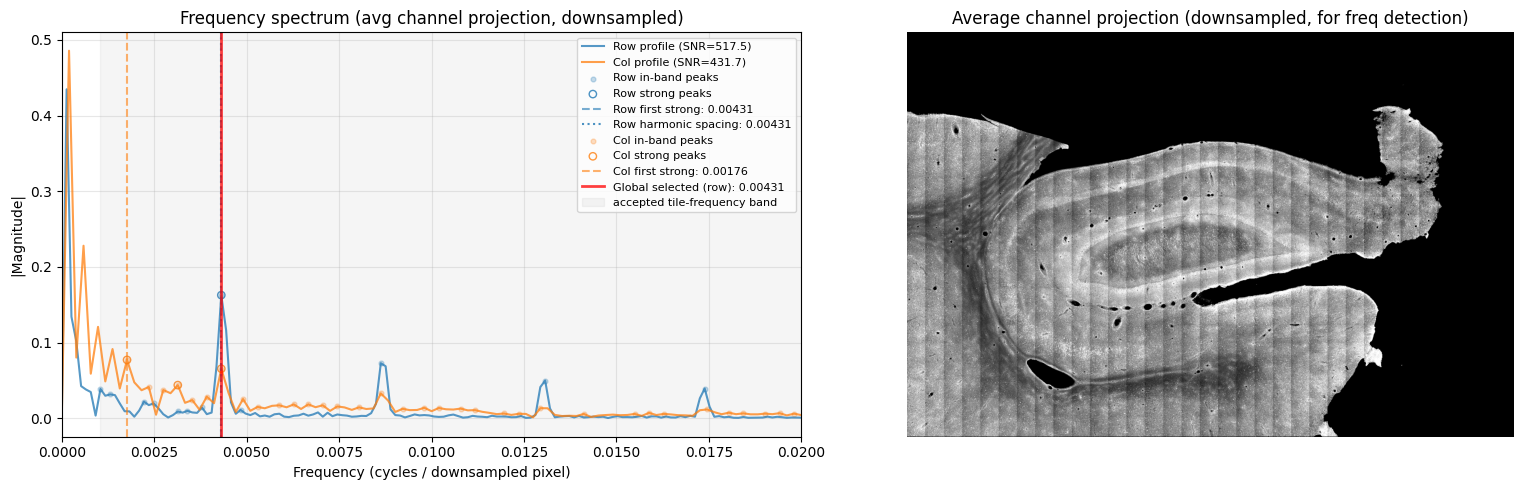

In [4]:
# @title Phase 4. Global Tile Frequency (from Average Channel Projection)
# @markdown The stitched tile geometry is identical across channels, so the
# @markdown tile frequency must be measured once from the **average** of all
# @markdown channels and then reused for every channel.
# @markdown
# @markdown For each axis the detector computes two summary statistics from
# @markdown the FFT magnitude spectrum:
# @markdown
# @markdown * **SNR**: strongest in-band peak divided by the median
# @markdown   magnitude of the noise floor. Higher = cleaner periodic
# @markdown   structure.
# @markdown * **Period-of-periods**: median spacing between consecutive
# @markdown   strong peaks. For a truly periodic tile pattern, peaks lie at
# @markdown   `f0`, `2*f0`, `3*f0`, ..., so the spacing between consecutive
# @markdown   peaks IS the fundamental frequency. This validates the first
# @markdown   strong peak against the harmonic structure of the spectrum.
# @markdown
# @markdown An axis is "aligned" when the first strong peak agrees with the
# @markdown harmonic spacing within 15%. The selection prefers the
# @markdown higher-SNR axis; ties default to the row profile.

shrinkage_factor = 2  # @param {type:"integer"}
minimum_tiles_in_axis = 8  # @param {type:"integer"}
strong_peak_fraction = 0.50  # @param {type:"slider", min:0.10, max:0.95, step:0.05}
manual_tile_period_full_px = 0  # @param {type:"integer"}
# 0 = use auto-detection. Otherwise this value (in FULL-RESOLUTION pixels)
# overrides the detected tile period -- use this if Phase 4 still picks the
# wrong peak (e.g. a sub-harmonic at ~2x the true tile period). The same
# value is applied to both axes.

# Average across channels (not max, to avoid one bright channel dominating).
avg_channel_projection = np.mean(original_images, axis=0, dtype=np.float32)
print(f"avg_channel_projection shape: {avg_channel_projection.shape}, dtype: {avg_channel_projection.dtype}")

if shrinkage_factor > 1:
    avg_ds = avg_channel_projection[::shrinkage_factor, ::shrinkage_factor].copy()
else:
    avg_ds = avg_channel_projection.copy()

avg_row_intensity, avg_col_intensity = compute_row_col_profiles(avg_ds)

# Per-axis fundamental detection. `minimum_tiles_in_axis` intentionally
# rejects slow tissue/vignette modes before selecting the first strong FFT peak.
dom_row_freq_raw, freq_row, mag_row, row_freq_info = detect_dominant_freq(
    avg_row_intensity,
    min_tiles_in_signal=minimum_tiles_in_axis,
    strong_peak_fraction=strong_peak_fraction,
    return_details=True,
)
dom_col_freq_raw, freq_col, mag_col, col_freq_info = detect_dominant_freq(
    avg_col_intensity,
    min_tiles_in_signal=minimum_tiles_in_axis,
    strong_peak_fraction=strong_peak_fraction,
    return_details=True,
)


def _axis_summary(magnitude, frequencies, info):
    """Compute SNR + period-of-periods diagnostics for one axis spectrum.

    Returns a dict with:
      snr                       : strongest in-band peak / median noise floor
      first_peak_freq           : lowest-frequency strong peak (fundamental
                                  candidate from the first-strong-peak rule)
      period_of_periods_freq    : median spacing between consecutive strong
                                  peaks. For a periodic signal this is the
                                  true fundamental even if the first peak
                                  is split / shifted by leakage.
      alignment                 : |first_peak - period_of_periods| / first_peak
      aligned                   : True if alignment < 0.15 (peak structure
                                  matches a single periodic component)
      n_strong_peaks            : number of strong peaks used
    """
    strong = info.get('strong_peaks_idx', np.array([], dtype=int)) if isinstance(info, dict) else np.array([], dtype=int)
    if len(strong) == 0 or len(magnitude) == 0:
        return {
            'snr': 0.0,
            'first_peak_freq': 0.0,
            'first_peak_px': float('inf'),
            'period_of_periods_freq': 0.0,
            'period_of_periods_px': float('inf'),
            'alignment': float('inf'),
            'aligned': False,
            'n_strong_peaks': 0,
        }
    strong = np.asarray(strong, dtype=int)
    sorted_freqs = np.sort(frequencies[strong])
    first_peak_freq = float(sorted_freqs[0])
    if len(sorted_freqs) >= 2:
        spacings = np.diff(sorted_freqs)
        period_of_periods_freq = float(np.median(spacings))
    else:
        # Only one strong peak: trust the first-strong-peak rule.
        period_of_periods_freq = first_peak_freq

    # SNR: strongest strong peak / median magnitude of NON-strong bins.
    peak_max = float(np.max(magnitude[strong]))
    is_peak = np.zeros(len(magnitude), dtype=bool)
    is_peak[strong] = True
    noise = magnitude[~is_peak]
    noise_floor = float(np.median(noise)) if len(noise) > 0 else 1e-12
    snr = peak_max / max(noise_floor, 1e-12)

    if first_peak_freq > 0:
        alignment = abs(period_of_periods_freq - first_peak_freq) / first_peak_freq
    else:
        alignment = float('inf')

    return {
        'snr': float(snr),
        'first_peak_freq': first_peak_freq,
        'first_peak_px': (1.0 / first_peak_freq) if first_peak_freq > 0 else float('inf'),
        'period_of_periods_freq': period_of_periods_freq,
        'period_of_periods_px': (1.0 / period_of_periods_freq) if period_of_periods_freq > 0 else float('inf'),
        'alignment': float(alignment),
        'aligned': bool(alignment < 0.15),
        'n_strong_peaks': int(len(strong)),
    }


row_summary = _axis_summary(mag_row, freq_row, row_freq_info)
col_summary = _axis_summary(mag_col, freq_col, col_freq_info)


def _fmt_summary(label, s):
    if s['n_strong_peaks'] == 0:
        return f"  {label}: no strong peaks detected"
    return (
        f"  {label}: SNR={s['snr']:6.2f}  "
        f"first-peak={s['first_peak_freq']:.6f} ({s['first_peak_px']:.1f} px)  "
        f"harmonic-spacing={s['period_of_periods_freq']:.6f} ({s['period_of_periods_px']:.1f} px)  "
        f"aligned={s['aligned']}  ({s['n_strong_peaks']} strong peaks)"
    )

print("\nPer-axis spectrum diagnostics:")
print(_fmt_summary("Row profile", row_summary))
print(_fmt_summary("Col profile", col_summary))


def _candidate_freq(summary, fallback_freq):
    """If the axis is aligned, return the harmonic spacing as the
    fundamental (most robust against spectral-leakage of the first peak).
    Otherwise return the original detector fallback."""
    if summary['aligned'] and summary['period_of_periods_freq'] > 0:
        return summary['period_of_periods_freq']
    return float(fallback_freq) if fallback_freq is not None else 0.0


row_candidate = _candidate_freq(row_summary, dom_row_freq_raw)
col_candidate = _candidate_freq(col_summary, dom_col_freq_raw)

# Selection: prefer higher-SNR axis. Ties / close-calls / both-missing
# default to ROW (empirically the cleaner profile on this kind of data).
SNR_DOMINANCE_FACTOR = 1.5  # column wins only if its SNR is >1.5x the row SNR


def _select_axis(row_summary, col_summary, row_candidate, col_candidate):
    row_snr = row_summary['snr']
    col_snr = col_summary['snr']
    row_ok = row_summary['n_strong_peaks'] > 0 and row_candidate > 0
    col_ok = col_summary['n_strong_peaks'] > 0 and col_candidate > 0

    if row_ok and not col_ok:
        return 'row', row_candidate, "only row has a usable spectrum"
    if col_ok and not row_ok:
        return 'col', col_candidate, "only col has a usable spectrum"
    if not row_ok and not col_ok:
        return 'fallback', 1.0 / 1000.0, "no usable spectrum on either axis"

    # Both axes usable; check alignment then SNR.
    row_aligned = row_summary['aligned']
    col_aligned = col_summary['aligned']

    if row_aligned and not col_aligned:
        return 'row', row_candidate, "only row is harmonic-aligned"
    if col_aligned and not row_aligned:
        return 'col', col_candidate, "only col is harmonic-aligned"

    # Both aligned or neither aligned: SNR breaks the tie, with row default.
    if col_snr > row_snr * SNR_DOMINANCE_FACTOR:
        return 'col', col_candidate, f"col SNR {col_snr:.2f} dominates row SNR {row_snr:.2f}"
    return 'row', row_candidate, (
        f"row default (row SNR {row_snr:.2f} vs col SNR {col_snr:.2f}; "
        f"col would need >{SNR_DOMINANCE_FACTOR}x to win)"
    )


primary_axis, tile_freq, reason = _select_axis(
    row_summary, col_summary, row_candidate, col_candidate
)
tile_period_ds = 1.0 / tile_freq if tile_freq > 0 else 1000.0
print(f"\nSelected primary axis: {primary_axis}  ({reason})")

# Apply the same frequency to both axes for every channel.
dom_row_freq = float(tile_freq)
dom_col_freq = float(tile_freq)

if manual_tile_period_full_px and manual_tile_period_full_px > 0:
    tile_period_full = float(manual_tile_period_full_px)
    tile_period_ds = tile_period_full / shrinkage_factor
    tile_freq = 1.0 / tile_period_ds
    dom_row_freq = float(tile_freq)
    dom_col_freq = float(tile_freq)
    print(f"\n*** MANUAL OVERRIDE: tile period set to "
          f"{tile_period_full:.0f} px full-res = "
          f"{tile_period_ds:.1f} px working scale "
          f"(freq {tile_freq:.6f}) ***")

tile_period_full = tile_period_ds * shrinkage_factor

print(f"\nSelected global tile frequency (used for both axes, all channels): {tile_freq:.6f}")
print(f"Selected tile interval at working scale: {tile_period_ds:.1f} px")
print(f"Selected tile interval at full resolution: {tile_period_full:.1f} px")

# Suggested filter_large_pixels (working scale): keep tile pattern, remove
# only the slower vignetting envelope. Roughly 1.5x the tile period.
suggested_filter_large = max(int(tile_period_ds * 1.5), 200)
print(f"Suggested filter_large_pixels for FFT bandpass: {suggested_filter_large}")

# Visualize the spectrum + the average projection
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(freq_row, mag_row, label=f'Row profile (SNR={row_summary["snr"]:.1f})', alpha=0.75)
ax.plot(freq_col, mag_col, label=f'Col profile (SNR={col_summary["snr"]:.1f})', alpha=0.75)


def _plot_peak_markers(ax, freq, mag, info, summary, color, label_prefix):
    if not isinstance(info, dict):
        return
    peaks = info.get('peaks_idx', np.array([], dtype=int))
    strong = info.get('strong_peaks_idx', np.array([], dtype=int))
    selected = info.get('selected_idx', None)
    if len(peaks) > 0:
        ax.scatter(freq[peaks], mag[peaks], s=12, color=color, alpha=0.25,
                   label=f'{label_prefix} in-band peaks')
    if len(strong) > 0:
        ax.scatter(freq[strong], mag[strong], s=28, facecolors='none',
                   edgecolors=color, alpha=0.8,
                   label=f'{label_prefix} strong peaks')
    if selected is not None:
        ax.axvline(freq[selected], color=color, linestyle='--', alpha=0.6,
                   label=f'{label_prefix} first strong: {freq[selected]:.5f}')
    # Harmonic-spacing marker (period-of-periods)
    if summary['period_of_periods_freq'] > 0 and summary['aligned']:
        ax.axvline(summary['period_of_periods_freq'], color=color,
                   linestyle=':', alpha=0.8,
                   label=f'{label_prefix} harmonic spacing: '
                         f'{summary["period_of_periods_freq"]:.5f}')


_plot_peak_markers(ax, freq_row, mag_row, row_freq_info, row_summary, 'C0', 'Row')
_plot_peak_markers(ax, freq_col, mag_col, col_freq_info, col_summary, 'C1', 'Col')
ax.axvline(tile_freq, color='red', linewidth=2.0, alpha=0.75,
           label=f'Global selected ({primary_axis}): {tile_freq:.5f}')

try:
    fmin_plot = min(row_freq_info['f_min'], col_freq_info['f_min'])
    fmax_plot = max(row_freq_info['f_max'], col_freq_info['f_max'])
    ax.axvspan(fmin_plot, fmax_plot, color='gray', alpha=0.08,
               label='accepted tile-frequency band')
except Exception:
    pass

ax.set_title('Frequency spectrum (avg channel projection, downsampled)')
ax.set_xlabel('Frequency (cycles / downsampled pixel)')
ax.set_ylabel('|Magnitude|')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, max(0.02, tile_freq * 4 if tile_freq > 0 else 0.02)])

ax = axes[1]
p1, p99 = np.percentile(avg_ds, (1, 99))
ax.imshow(exposure.rescale_intensity(avg_ds[::5, ::5], in_range=(p1, p99)), cmap='gray')
ax.set_title('Average channel projection (downsampled, for freq detection)')
ax.axis('off')
plt.tight_layout()
plt.show()


maskingimg shape: (5100, 7650), dtype: uint8
Edge tissue ratio: 16.06%
Is isolated: False


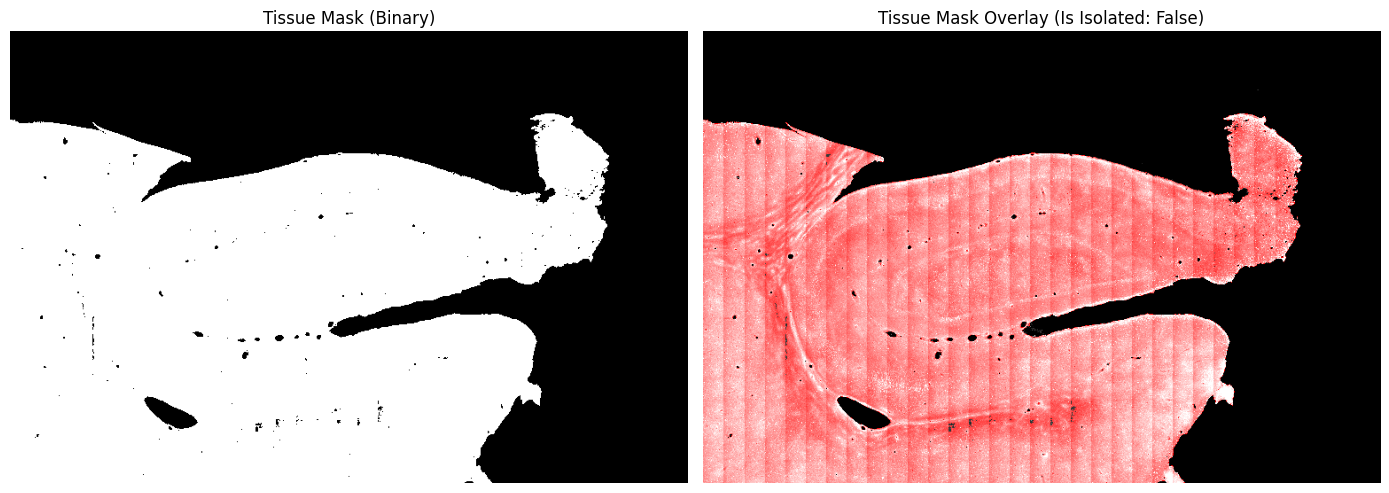

Tile period at working scale: ~231.8 x 231.8 px
Inferred tile grid (cols x rows): 33 x 22
Drawing 34 vertical + 23 horizontal dashed lines (including image edges).


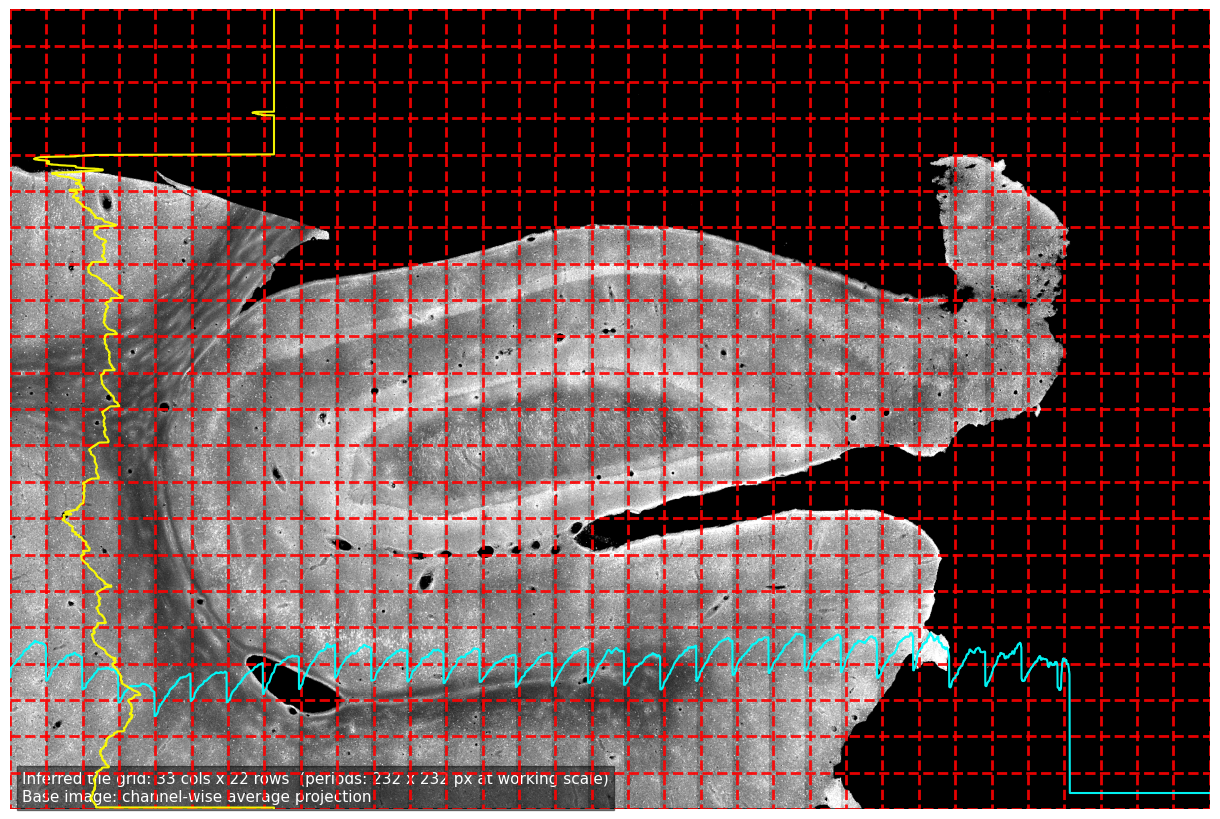

In [5]:
# @title Phase 5. Detect Tissue Mask (Globally) + Tile Geometry Overlay
# @markdown The mask is computed ONCE from the channel-wise max projection so
# @markdown sparsely labeled channels still benefit from a complete tissue mask.
# @markdown
# @markdown A second figure overlays the inferred tile boundaries (red dashed
# @markdown lines) plus the mean row/column intensity curves directly on top
# @markdown of the **channel-wise average intensity projection** (the same image
# @markdown Phase 4 used to detect the tile frequency), so you can sanity-check
# @markdown the tile geometry before processing.

disk_size = 0.01  # @param {type:"slider", min:0.01, max:0.5, step:0.01}
threshold_param = 0.05  # @param {type:"slider", min:0.0, max:1.0, step:0.05}
final_cutoff_multiplier = 1.0  # @param {type:"slider", min:0.5, max:2.0, step:0.05}

# Downsample the combined MIP by the same factor as the working images so
# tissue_mask shape matches each channel's working scale.
if shrinkage_factor > 1:
    maskingimg = combined_mip[::shrinkage_factor, ::shrinkage_factor].copy()
else:
    maskingimg = combined_mip.copy()
print(f"maskingimg shape: {maskingimg.shape}, dtype: {maskingimg.dtype}")

tissue_mask = tony_isolate_tissue(
    maskingimg,
    disksize=disk_size,
    threshold=threshold_param,
    cutoff_multiplier=final_cutoff_multiplier,
    verbose=False,
)

top_edge = tissue_mask[0, :]
bottom_edge = tissue_mask[-1, :]
left_edge = tissue_mask[:, 0]
right_edge = tissue_mask[:, -1]
all_edges = np.concatenate((top_edge, bottom_edge, left_edge, right_edge))
edge_tissue_ratio = np.sum(all_edges) / len(all_edges)
is_isolated = edge_tissue_ratio < 0.01

print(f"Edge tissue ratio: {edge_tissue_ratio:.2%}")
print(f"Is isolated: {is_isolated}")

# ---- Figure 1: mask + overlay on the max-projection (unchanged) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(tissue_mask[::10, ::10], cmap='gray')
axes[0].set_title("Tissue Mask (Binary)")
axes[0].axis('off')

p1, p99 = np.percentile(maskingimg, (1, 99))
display_img = exposure.rescale_intensity(
    maskingimg[::10, ::10], in_range=(p1, p99), out_range=(0, 255)
).astype(np.uint8)
overlay_display = np.dstack((display_img, display_img, display_img))
overlay_display[tissue_mask[::10, ::10], 0] = 255
axes[1].imshow(overlay_display)
axes[1].set_title(f"Tissue Mask Overlay (Is Isolated: {is_isolated})")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# ---- Figure 2: tile boundaries + mean intensity curves over avg projection ----
# Base image is the channel-wise AVERAGE projection (avg_channel_projection
# was built in Phase 4 and is the same image used to detect the tile freq).
# This is more representative of typical signal than the max projection.
if shrinkage_factor > 1:
    base_full = avg_channel_projection[::shrinkage_factor, ::shrinkage_factor]
else:
    base_full = avg_channel_projection
H_b, W_b = base_full.shape
ds_view = 4   # display downsample (for speed); does NOT affect math below
base = base_full[::ds_view, ::ds_view]
H_d, W_d = base.shape

# Mean row/col intensity profiles at working scale
row_mean_full, col_mean_full = compute_row_col_profiles(base_full)
# row_mean_full: length W_b, varies with x  (mean of each column = the
#                horizontal profile that runs across the image)
# col_mean_full: length H_b, varies with y  (mean of each row = the
#                vertical profile that runs down the image)

# Tile period in working-scale pixels. Phase 4 sets dom_row_freq and
# dom_col_freq to the same winning frequency (tiles are square), so these
# two are equal in practice.
tile_period_x_full = (1.0 / dom_row_freq) if dom_row_freq > 0 else float('inf')
tile_period_y_full = (1.0 / dom_col_freq) if dom_col_freq > 0 else float('inf')

def _tile_boundaries(extent_px, period_px):
    """Inclusive linspace boundaries for an axis of length ``extent_px`` and
    a tile period ``period_px``."""
    if not np.isfinite(period_px) or period_px <= 1:
        return np.array([0.0, extent_px], dtype=np.float32)
    n_tiles = max(1, int(round(extent_px / period_px)))
    return np.linspace(0.0, extent_px, n_tiles + 1)

bounds_x_full = _tile_boundaries(W_b, tile_period_x_full)
bounds_y_full = _tile_boundaries(H_b, tile_period_y_full)
# Map to display coordinates (we plot in the downsampled image's frame).
bounds_x = bounds_x_full / ds_view
bounds_y = bounds_y_full / ds_view

# 1D profiles scaled into a 25%-wide band along the bottom (row) and left
# (col) of the image; brighter -> curve goes further into the image.
def _normalize_to_range(arr, target_lo, target_hi):
    a = np.asarray(arr, dtype=np.float32)
    a_min, a_max = float(np.nanmin(a)), float(np.nanmax(a))
    if a_max <= a_min:
        return np.full_like(a, (target_lo + target_hi) / 2.0)
    return target_lo + (a - a_min) / (a_max - a_min) * (target_hi - target_lo)

h_curve_band_top = H_d * 0.78
h_curve_band_bot = H_d * 0.98
h_curve_y = _normalize_to_range(-row_mean_full, h_curve_band_top, h_curve_band_bot)
h_curve_x = np.linspace(0, W_d - 1, len(h_curve_y))

v_curve_band_left = W_d * 0.02
v_curve_band_right = W_d * 0.22
v_curve_x = _normalize_to_range(-col_mean_full, v_curve_band_left, v_curve_band_right)
v_curve_y = np.linspace(0, H_d - 1, len(v_curve_x))

# Debug info: how many lines are we about to draw?
print(f"Tile period at working scale: ~{tile_period_x_full:.1f} x {tile_period_y_full:.1f} px")
print(f"Inferred tile grid (cols x rows): {len(bounds_x) - 1} x {len(bounds_y) - 1}")
print(f"Drawing {len(bounds_x)} vertical + {len(bounds_y)} horizontal dashed lines "
      f"(including image edges).")

fig = plt.figure(figsize=(12, 12 * H_d / max(W_d, 1)))
ax = fig.add_axes([0, 0, 1, 1])
p1v, p99v = np.percentile(base, (1, 99))
ax.imshow(exposure.rescale_intensity(base, in_range=(p1v, p99v)),
          cmap='gray', aspect='equal', zorder=0)

# --- Dashed tile-boundary lines: RED, slightly thick, drawn ON TOP. ---
# We use vlines/hlines with explicit (x, ymin, ymax) / (y, xmin, xmax) in
# DATA coordinates and a high zorder so they always sit above the image
# regardless of axis-spine state. axvline/axhline can in some edge cases
# get clipped when axis-off is combined with add_axes([0,0,1,1]); explicit
# data-coord vlines/hlines are immune.
ymin_data, ymax_data = 0.0, float(H_d)
xmin_data, xmax_data = 0.0, float(W_d)
if len(bounds_x) > 0:
    ax.vlines(bounds_x, ymin=ymin_data, ymax=ymax_data,
              colors='red', linestyles='dashed', linewidth=2.0,
              alpha=0.9, zorder=10)
if len(bounds_y) > 0:
    ax.hlines(bounds_y, xmin=xmin_data, xmax=xmax_data,
              colors='red', linestyles='dashed', linewidth=2.0,
              alpha=0.9, zorder=10)

# --- 1D intensity curves drawn over the image ---
ax.plot(h_curve_x, h_curve_y, color='cyan', linewidth=1.5, alpha=0.95,
        zorder=15, label='mean row intensity (varies with x)')
ax.plot(v_curve_x, v_curve_y, color='yellow', linewidth=1.5, alpha=0.95,
        zorder=15, label='mean col intensity (varies with y)')

ax.set_xlim(0, W_d)
ax.set_ylim(H_d, 0)
ax.set_axis_off()
ax.text(0.01, 0.01,
        f"Inferred tile grid: {len(bounds_x) - 1} cols x {len(bounds_y) - 1} rows  "
        f"(periods: {tile_period_x_full:.0f} x {tile_period_y_full:.0f} px at working scale)\n"
        f"Base image: channel-wise average projection",
        transform=ax.transAxes, color='white', fontsize=11,
        bbox=dict(facecolor='black', alpha=0.5, pad=4))
plt.show()


In [6]:
# @title Phase 6. Define Per-Channel Processing Pipeline

# Phase 7 legacy FFT compatibility helper.
# Defined in Phase 6 so Phases 1-5 remain unchanged.  It is only installed
# inside the do_fft_bandpass=True branch, so the unchecked FFT path keeps the
# same processing behavior.
def _vista_install_legacy_fft_rectangle_alias():
    """Make morphology.footprint_rectangle((rows, cols)) available in older Colab scikit-image.

    The restored v6-compatible morphology-profile helper calls make_rect((1, 100)).
    In scikit-image 0.24, morphology.rectangle expects rectangle(nrows, ncols),
    so calling morphology.rectangle((1, 100)) raises:
        TypeError: rectangle() missing 1 required positional argument: 'ncols'
    This alias supplies the newer tuple-style footprint function without changing
    the non-FFT branch.
    """
    try:
        existing = getattr(morphology, 'footprint_rectangle')
        test_fp = existing((1, 2))
        if getattr(test_fp, 'shape', None) == (1, 2):
            return
    except Exception:
        pass

    original_rect = getattr(morphology, 'rectangle', None)
    original_footprint = getattr(morphology, 'footprint_rectangle', None)

    def _vista_footprint_rectangle(shape, *args, **kwargs):
        if args:
            nrows, ncols = int(shape), int(args[0])
        elif isinstance(shape, (tuple, list, np.ndarray)):
            nrows, ncols = int(shape[0]), int(shape[1])
        else:
            nrows = ncols = int(shape)
        nrows = max(1, nrows)
        ncols = max(1, ncols)

        if original_footprint is not None:
            try:
                return original_footprint((nrows, ncols))
            except TypeError:
                try:
                    return original_footprint(nrows, ncols)
                except TypeError:
                    pass
        if original_rect is not None:
            try:
                return original_rect(nrows, ncols)
            except TypeError:
                try:
                    return original_rect((nrows, ncols))
                except TypeError:
                    pass
        return np.ones((nrows, ncols), dtype=bool)

    morphology.footprint_rectangle = _vista_footprint_rectangle


def process_channel(channel_full, channel_idx, tissue_mask, is_isolated,
                    dom_row_freq, dom_col_freq,
                    shrinkage_factor=2,
                    do_fft_bandpass=True,
                    filter_large_pixels=1000, filter_small_pixels=1, tolerance=0,
                    axial_width_factor=0.30,
                    median_kernel=15, fft_scale=0.5,
                    morph_radius=15, dark_percentile=10.0, ds_factor_dark=4,
                    box_filter_size=3, tile_size=999, slope=1.0, hist_bins=500,
                    sharpen_radius=30.0, sharpen_amount=0.5,
                    mask_smooth_iterations=15, unsharp_radius=7.0, unsharp_amount=0.4,
                    overshoot_exponent=1.5, bg_subtract_factor=0.5,
                    matlab_envelope_factor=1.5, matlab_rescale_factor=1.0,
                    do_dip_correction=True,
                    dip_baseline_window_factor=1.5,
                    dip_baseline_percentile=80.0,
                    dip_baseline_smooth_factor=0.3,
                    dip_mult_max=3.0,
                    dip_correction_strength_horizontal=0.2,
                    dip_correction_strength_vertical=1.0,
                    do_remove_lines=True,
                    remove_lines_disk=50, remove_lines_line=50,
                    tony_detrend_periods=3.0, tony_peak_widen_factor=0.20,
                    do_bridge_boundaries=True,
                    bridge_band_half_width=4, bridge_ref_half_width=10,
                    bridge_gap=3, bridge_smooth_win=101,
                    bridge_mult_clip_lo=0.6, bridge_mult_clip_hi=2.5,
                    bridge_using_tophat=True, bridge_bh_width=101,
                    clahe_kernel_tile_factor=8.0, clahe_min_kernel=999,
                    clahe_adaptive_slope=True, clahe_std_ref=0.15,
                    clahe_min_slope=1.0,
                    monitor_negatives=True,
                    pre_clahe_baseline_strength=0.5,
                    pre_clahe_baseline_sigma_px=500.0,
                    show_diagnostics=True,
                    legacy_fft_use_v6_polish_defaults=True,
                    legacy_fft_use_native_raw=True,
                    export_legacy_fft_diagnostics=False,
                    legacy_fft_diagnostics_dir=None,
                    legacy_fft_diagnostic_stride=10,
                    legacy_fft_branch_a_ratio_strength=0.85,
                    legacy_fft_branch_a_ratio_clip_lo=0.25,
                    legacy_fft_branch_a_ratio_clip_hi=3.0,
                    legacy_fft_branch_a_baseline_percentile=1.0,
                    legacy_fft_branch_a_baseline_strength=1.0):
    """Full vignetting-correction pipeline for one channel.

    Two correction paths are available, controlled by ``do_fft_bandpass``:

      * do_fft_bandpass=True  (legacy v6-compatible path): sequential
        FFT bandpass filtering is used to estimate a ratio map, row/column
        correction profiles, and a morphology/FFT hybrid multiplier. Branch A
        applies the ratio map with dark-spot attenuation and a second p98
        bright-spot attenuation; Branch B applies FFT cleanup to the hybrid
        correction with dark-spot pixel replacement; the branches are fused
        and then polished through the original v6-style contrast sequence.

      * do_fft_bandpass=False (good when signal is sparse or the tissue has
        strong large-scale intensity variation): a MATLAB-style envelope-based
        multiplicative correction is applied per axis. An extra diagnostic
        figure is shown first so the row/col envelopes and the derived 1D
        multipliers can be inspected before the multiplier surface is built.

    Both paths share: bright spot withholding (attenuated for analysis,
    restored at the end from the raw channel), dark spot withholding,
    polish (smooth + CLAHE + unsharp), the morphological dip correction,
    and the final contrast-equalization steps.
    """
    print(f"\n{'=' * 60}")
    print(f"Processing channel {channel_idx}  (shape={channel_full.shape}, dtype={channel_full.dtype})")
    print(f"  Using dominant freqs (row, col): ({dom_row_freq:.6f}, {dom_col_freq:.6f})")
    if do_fft_bandpass:
        print(f"  PATH: FFT bandpass ON   (legacy v6 ratio-map + hybrid fusion, filter_large_pixels={filter_large_pixels}, tolerance={tolerance})")
    else:
        print(f"  PATH: FFT bandpass OFF  (MATLAB-style multiplicative mask, "
              f"overshoot={overshoot_exponent}, bg_subtract={bg_subtract_factor})")
    print(f"{'=' * 60}")
    epsilon = 1e-10
    diag = {}
    diag['step_stats'] = []

    def _check_step(arr, step_name, expected_min=0.0, expected_max=None):
        # Spot-check the array at this pipeline step. Print a single
        # warning if values fall outside the expected range. Stats are
        # always recorded in diag['step_stats'] for later inspection.
        if not monitor_negatives:
            return
        try:
            sub = arr[::8, ::8] if arr.ndim == 2 else arr
            mn = float(np.nanmin(sub))
            mx = float(np.nanmax(sub))
        except Exception:
            return
        diag['step_stats'].append((step_name, mn, mx))
        if expected_min is not None and mn < expected_min - 1e-3:
            print(f"  ! [{step_name}] min={mn:.4f} (below expected_min={expected_min})"
                  f" -- check for negative pixels")
        if expected_max is not None and mx > expected_max + 1e-3:
            print(f"  ! [{step_name}] max={mx:.4f} (above expected_max={expected_max})")


    # ----- A. Downsample working image -----
    if shrinkage_factor > 1:
        workingimg = channel_full[::shrinkage_factor, ::shrinkage_factor].copy()
    else:
        workingimg = channel_full.copy()
    if workingimg.dtype != np.uint8:
        workingimg = np.nan_to_num(workingimg, nan=0).astype(np.uint8)

    if workingimg.shape != tissue_mask.shape:
        working_mask = transform.resize(
            tissue_mask.astype(np.uint8), workingimg.shape,
            order=0, preserve_range=True,
        ).astype(bool)
    else:
        working_mask = tissue_mask

    diag['raw'] = channel_full[::10, ::10].copy()

    # ----- B. Background equalization (only if isolated) -----
    if is_isolated:
        ds = workingimg[::10, ::10]
        valid_small = ds[ds > 0]
        threshold_value = int(np.percentile(valid_small, 1)) if len(valid_small) > 0 else 0
        workingimg[workingimg == 0] = threshold_value

    # ----- C. Bright spot attenuation -----
    img_sanitized = workingimg.copy()
    masked_pixels = img_sanitized[working_mask]
    flattened_array = masked_pixels[masked_pixels != 0]
    if len(flattened_array) > 0:
        threshold_value_99 = np.percentile(flattened_array, 99)
        mean_val = np.mean(flattened_array)
        divyfactor = mean_val / threshold_value_99 if threshold_value_99 > 0 else 1.0
    else:
        threshold_value_99, divyfactor = 255.0, 1.0
    bright_indices = img_sanitized > threshold_value_99
    if np.any(bright_indices):
        img_sanitized[bright_indices] = (img_sanitized[bright_indices] * divyfactor).astype(np.uint8)
    img_sanitized = exposure.rescale_intensity(img_sanitized, out_range=(0, 255)).astype(np.uint8)
    p1, p99 = np.percentile(img_sanitized, (1, 99))
    if p99 > p1:
        img_sanitized = exposure.rescale_intensity(
            img_sanitized, in_range=(p1, p99), out_range=(0, 255)
        ).astype(np.uint8)
    del workingimg, masked_pixels, flattened_array
    gc.collect()
    diag['sanitized'] = img_sanitized[::4, ::4].copy()

    # ----- D. Pad background with tissue mean BEFORE any frequency work -----
    img_for_fft, bg_pad_value = pad_bg_with_tissue_mean(img_sanitized, working_mask)
    print(f"  Background padded with tissue mean = {bg_pad_value:.2f}")
    diag['fft_padded'] = img_for_fft[::4, ::4].copy()

    target_h, target_w = channel_full.shape


    if do_fft_bandpass:
        # ============================================================
        # FFT PATH -- legacy v6-compatible ratio-map + hybrid fusion.
        #
        # Important: this block intentionally returns early.  The non-FFT
        # path below is left unchanged; all restored v6-specific behavior is
        # isolated here so unchecking `do_fft_bandpass` runs the newer
        # MATLAB-style path exactly as before.
        # ============================================================
        print("  FFT path details: v6-style sequential FFT -> ratio profiles -> "
              "morphology/FFT hybrid -> Branch A/B fusion -> Ultimate average")
        _vista_install_legacy_fft_rectangle_alias()
        if axial_width_factor is not None:
            print("  Note: axial_width_factor is retained for Phase 7 compatibility, "
                  "but the legacy v6 sequential FFT path does not use the cross-shaped axial mask.")

        import os as _os
        legacy_diag = {}
        _legacy_make_diag = bool(show_diagnostics or export_legacy_fft_diagnostics)
        _legacy_stride = max(1, int(legacy_fft_diagnostic_stride))

        def _legacy_store(name, arr, stride=None):
            if not _legacy_make_diag or arr is None:
                return
            try:
                a = np.asarray(arr)
                if a.ndim == 3:
                    a = a[0]
                s = max(1, int(stride if stride is not None else _legacy_stride))
                legacy_diag[name] = a[::s, ::s].copy()
            except Exception as _exc:
                print(f"  Warning: could not store legacy diagnostic '{name}' ({_exc}).")

        def _legacy_show(ax, img, title, cmap='gray', pct=(1, 99)):
            if img is None or np.size(img) == 0:
                ax.text(0.5, 0.5, '(skipped)', ha='center', va='center', color='gray', fontsize=10)
                ax.set_title(title, fontsize=9)
                ax.axis('off')
                return
            arr = np.asarray(img)
            if arr.ndim == 3:
                arr = arr[0]
            if pct is None:
                ax.imshow(arr, cmap=cmap)
            else:
                pos = arr[arr > 0] if np.any(arr > 0) else arr.ravel()
                if pos.size > 0:
                    lo, hi = np.percentile(pos, pct)
                else:
                    lo, hi = float(np.nanmin(arr)), float(np.nanmax(arr))
                if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
                    lo = float(np.nanmin(arr)) if np.size(arr) else 0.0
                    hi = float(np.nanmax(arr)) if np.size(arr) else 1.0
                    if hi <= lo:
                        hi = lo + 1e-6
                ax.imshow(exposure.rescale_intensity(arr, in_range=(lo, hi)), cmap=cmap)
            ax.set_title(title, fontsize=9)
            ax.axis('off')

        def _legacy_upscale_profile(profile, target_len):
            p = np.asarray(profile, dtype=np.float64).ravel()
            if p.size == 0:
                return np.ones(int(target_len), dtype=np.float32)
            finite = np.isfinite(p)
            if not np.any(finite):
                p = np.ones_like(p, dtype=np.float64)
            elif np.sum(finite) == 1:
                p = np.full_like(p, float(p[finite][0]), dtype=np.float64)
            else:
                x = np.arange(p.size)
                p = np.interp(x, x[finite], p[finite])
            x_old = np.linspace(0, 1, p.size)
            x_new = np.linspace(0, 1, int(target_len))
            return np.interp(x_new, x_old, p).astype(np.float32)

        def _legacy_auto_sigma(freq_val, default=2.0):
            if freq_val is not None and freq_val > 0:
                return max(1.0, (1.0 / float(freq_val)) * 0.02)
            return float(default)

        def _legacy_odd_kernel(k, n=None, min_k=3):
            k = int(round(k))
            if k % 2 == 0:
                k += 1
            k = max(int(min_k), k)
            if n is not None and n > 0 and k > n:
                k = int(n) if int(n) % 2 == 1 else int(n) - 1
                k = max(1, k)
            return k

        def _legacy_smooth_profile(raw_profile, freq_val):
            p = np.asarray(raw_profile, dtype=np.float64).ravel()
            if p.size == 0:
                return np.ones(1, dtype=np.float32), _legacy_auto_sigma(freq_val)
            finite = np.isfinite(p)
            if not np.any(finite):
                p = np.ones_like(p, dtype=np.float64)
            elif np.sum(finite) == 1:
                p = np.full_like(p, float(p[finite][0]), dtype=np.float64)
            else:
                x = np.arange(p.size)
                p = np.interp(x, x[finite], p[finite])
            k_use = _legacy_odd_kernel(median_kernel, p.size)
            try:
                if k_use >= 3:
                    p = signal.medfilt(p, kernel_size=k_use)
            except Exception:
                pass
            sigma_use = _legacy_auto_sigma(freq_val)
            try:
                p = ndimage.gaussian_filter1d(p, sigma=sigma_use)
            except Exception:
                pass
            p = np.nan_to_num(p, nan=1.0, posinf=1.0, neginf=1.0)
            return p.astype(np.float32), sigma_use

        def _legacy_normalize_profile(profile):
            p = np.asarray(profile, dtype=np.float32)
            pmin, pmax = float(np.nanmin(p)), float(np.nanmax(p))
            if np.isfinite(pmin) and np.isfinite(pmax) and pmax > pmin:
                return (p - pmin) / (pmax - pmin + 1e-6)
            return np.ones_like(p, dtype=np.float32)

        def _legacy_make_native_mips(raw_img):
            """Return a (C, Y, X) native-bit-depth MIP stack using Phase-1 TIFF conventions."""
            arr = np.asarray(raw_img)
            if arr.ndim == 2:
                return arr[np.newaxis, ...]
            if arr.ndim == 3:
                # Match Phase 1: RGB/RGBA is treated as last-axis channels;
                # otherwise a 3D TIFF is interpreted as a Z stack -> 1-channel MIP.
                if arr.shape[-1] in (3, 4):
                    if arr.shape[-1] == 4:
                        arr = arr[..., :3]
                    return np.moveaxis(arr, -1, 0)
                return np.max(arr, axis=0)[np.newaxis, ...]
            if arr.ndim == 4:
                # Match Phase 1 OME-TIFF convention: (C, Z, Y, X) -> MIP across Z.
                return np.max(arr, axis=1)
            squeezed = np.squeeze(arr)
            if squeezed.ndim == 2:
                return squeezed[np.newaxis, ...]
            raise ValueError(f"unsupported native TIFF shape {arr.shape}")

        def _legacy_source_dtype_max(arr, fallback):
            try:
                if np.issubdtype(arr.dtype, np.integer):
                    return float(np.iinfo(arr.dtype).max)
            except Exception:
                pass
            finite = np.asarray(arr)[np.isfinite(arr)]
            if finite.size > 0:
                return float(max(np.nanmax(finite), fallback, 1.0))
            return float(max(fallback, 1.0))

        def _legacy_get_full_source():
            """Best-effort native raw reload for the legacy v6 FFT reconstruction.

            Phase 1 intentionally stores an 8-bit MIP stack for the flexible v20
            pipeline.  The old v6 reconstruction, however, reloaded the source
            TIFF before Branch A/Branch B fusion.  When enabled, this helper
            restores that behavior for TIFF/OME-TIFF inputs and falls back to
            the Phase-1 channel without interrupting the run.
            """
            phase1_source = channel_full.astype(np.float32, copy=True)
            phase1_max = _legacy_source_dtype_max(channel_full, float(np.nanmax(phase1_source)) if phase1_source.size else 1.0)
            if not legacy_fft_use_native_raw:
                print("    Native raw reload disabled; using Phase-1 channel for legacy FFT reconstruction.")
                return phase1_source, phase1_max, "phase1"
            try:
                full_path_val = globals().get('full_path', None)
                if full_path_val is None or not _os.path.exists(full_path_val):
                    print("    Native raw reload skipped: full_path is unavailable; using Phase-1 channel.")
                    return phase1_source, phase1_max, "phase1"
                if not str(full_path_val).lower().endswith((".tif", ".tiff")):
                    print("    Native raw reload skipped: non-TIFF source; using Phase-1 channel.")
                    return phase1_source, phase1_max, "phase1"

                cache_path = globals().get('_VISTAMAP_LEGACY_NATIVE_MIPS_PATH', None)
                native_mips = globals().get('_VISTAMAP_LEGACY_NATIVE_MIPS', None)
                if native_mips is None or cache_path != full_path_val:
                    import tifffile as _legacy_tifffile
                    print("    Reloading source TIFF at native bit-depth for legacy FFT reconstruction...")
                    raw_img = _legacy_tifffile.imread(full_path_val)
                    native_mips = _legacy_make_native_mips(raw_img)
                    globals()['_VISTAMAP_LEGACY_NATIVE_MIPS'] = native_mips
                    globals()['_VISTAMAP_LEGACY_NATIVE_MIPS_PATH'] = full_path_val
                    del raw_img
                    gc.collect()

                if native_mips.ndim == 2:
                    native_channel = native_mips
                elif native_mips.ndim == 3:
                    if int(channel_idx) >= native_mips.shape[0]:
                        raise IndexError(
                            f"channel_idx={channel_idx} but native stack has {native_mips.shape[0]} channel(s)"
                        )
                    native_channel = native_mips[int(channel_idx)]
                else:
                    raise ValueError(f"unexpected native MIP stack shape {native_mips.shape}")

                native_max = _legacy_source_dtype_max(native_channel, phase1_max)
                native_channel = np.asarray(native_channel, dtype=np.float32)
                if native_channel.shape != channel_full.shape:
                    src_h, src_w = native_channel.shape[-2:]
                    dst_h, dst_w = channel_full.shape
                    diff_h = int(dst_h) - int(src_h)
                    diff_w = int(dst_w) - int(src_w)
                    small_mismatch_h = abs(diff_h) <= max(512, int(round(0.05 * dst_h)))
                    small_mismatch_w = abs(diff_w) <= max(512, int(round(0.05 * dst_w)))

                    if diff_h >= 0 and diff_w >= 0 and small_mismatch_h and small_mismatch_w:
                        # v6 padded the native raw image at bottom/right to the working full size.
                        # Resizing stretches the tile grid and can put the ratio map out of phase,
                        # which is exactly the failure mode that makes Branch A tile boundaries bright.
                        print(f"    Native channel shape {native_channel.shape} does not match Phase-1 shape "
                              f"{channel_full.shape}; padding bottom/right by ({diff_h}, {diff_w}) pixels "
                              f"instead of resizing, matching the old v6 reconstruction.")
                        native_channel = np.pad(
                            native_channel,
                            ((0, diff_h), (0, diff_w)),
                            mode='constant',
                            constant_values=0,
                        ).astype(np.float32)
                    elif diff_h <= 0 and diff_w <= 0 and small_mismatch_h and small_mismatch_w:
                        print(f"    Native channel shape {native_channel.shape} is slightly larger than Phase-1 shape "
                              f"{channel_full.shape}; cropping bottom/right to match without resampling.")
                        native_channel = native_channel[:dst_h, :dst_w].astype(np.float32, copy=False)
                    else:
                        print(f"    Native channel shape {native_channel.shape} does not match Phase-1 shape "
                              f"{channel_full.shape}; mismatch is too large for v6-style pad/crop, so resizing.")
                        native_channel = transform.resize(
                            native_channel,
                            channel_full.shape,
                            order=1,
                            preserve_range=True,
                            anti_aliasing=False,
                        ).astype(np.float32)
                print(f"    Using native TIFF source for legacy reconstruction "
                      f"(shape={native_channel.shape}, clip_max={native_max:.1f}).")
                return native_channel, native_max, "native_tiff"
            except Exception as _exc:
                print(f"    Warning: native raw reload failed ({_exc}); using Phase-1 channel.")
                return phase1_source, phase1_max, "phase1"

        legacy_full_source, legacy_full_source_max, legacy_full_source_note = _legacy_get_full_source()
        _legacy_store('raw', legacy_full_source)
        _legacy_store('sanitized', img_sanitized, stride=4)
        _legacy_store('fft_padded', img_for_fft, stride=4)

        # ------------------------------------------------------------
        # 1. Sequential FFT bandpass on the sanitized working image.
        #    This deliberately uses the v6 input (`img_sanitized`) rather
        #    than treating the FFT output as the final corrected image.
        # ------------------------------------------------------------
        legacy_fft_input = img_sanitized.astype(np.float32)
        print("  [legacy FFT] pass 1/2: horizontal stripe suppression")
        filtered_pass1, _mask_h = tony_bandpass_filter(
            legacy_fft_input,
            filter_large=filter_large_pixels,
            filter_small=filter_small_pixels,
            suppress_direction='horizontal',
            tolerance_percent=tolerance,
        )
        if _legacy_make_diag:
            try:
                legacy_diag['fft_mask_h'] = _mask_h[::20, ::20].copy()
            except Exception:
                pass
        del _mask_h
        gc.collect()

        print("  [legacy FFT] pass 2/2: vertical stripe suppression")
        filtered_final, _mask_v = tony_bandpass_filter(
            filtered_pass1,
            filter_large=filter_large_pixels,
            filter_small=filter_small_pixels,
            suppress_direction='vertical',
            tolerance_percent=tolerance,
        )
        if _legacy_make_diag:
            try:
                legacy_diag['fft_mask_v'] = _mask_v[::20, ::20].copy()
            except Exception:
                pass
        del filtered_pass1, _mask_v
        gc.collect()
        _legacy_store('fft_out', filtered_final, stride=4)

        # ------------------------------------------------------------
        # 2. Ratio map + smoothed FFT row/column multiplier profiles.
        # ------------------------------------------------------------
        print("  [legacy FFT] extracting ratio-map row/column profiles")
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_map = filtered_final / (legacy_fft_input + epsilon)
        np.clip(ratio_map, 0.1, 10.0, out=ratio_map)
        ratio_map[~np.isfinite(ratio_map)] = np.nan
        _legacy_store('ratio_map', ratio_map, stride=10)

        raw_row_profile = np.nanmean(ratio_map, axis=1)
        raw_col_profile = np.nanmean(ratio_map, axis=0)
        final_row_profile, sigma_row = _legacy_smooth_profile(raw_row_profile, dom_row_freq)
        final_col_profile, sigma_col = _legacy_smooth_profile(raw_col_profile, dom_col_freq)
        global_mean_ratio = float(np.nanmean(final_row_profile))
        if not np.isfinite(global_mean_ratio) or abs(global_mean_ratio) < 1e-6:
            global_mean_ratio = 1.0
        synthetic_multiplier = (
            final_row_profile[:, None] * final_col_profile[None, :]
        ) / global_mean_ratio
        _legacy_store('multiplier', synthetic_multiplier, stride=max(1, _legacy_stride // 2))
        print(f"    FFT profile smoothing: row sigma={sigma_row:.2f}, col sigma={sigma_col:.2f}")

        # ------------------------------------------------------------
        # 3. Morphological profiles and hybrid profile fusion.
        # ------------------------------------------------------------
        print("  [legacy FFT] extracting morphology profiles and building hybrid correction")
        morph_row, morph_col = extract_morph_profiles(
            img_sanitized,
            working_mask,
            dom_col_freq,
            dom_row_freq,
            median_k=median_kernel,
            sigma_s=0,
        )
        min_len_row = min(len(morph_row), len(final_row_profile))
        min_len_col = min(len(morph_col), len(final_col_profile))
        hybrid_row = (morph_row[:min_len_row] + final_row_profile[:min_len_row]) / 2.0
        hybrid_col = (morph_col[:min_len_col] + final_col_profile[:min_len_col]) / 2.0
        hybrid_row = np.nan_to_num(hybrid_row, nan=1.0, posinf=1.0, neginf=1.0).astype(np.float32)
        hybrid_col = np.nan_to_num(hybrid_col, nan=1.0, posinf=1.0, neginf=1.0).astype(np.float32)
        global_mean_hybrid = float(np.mean(hybrid_row))
        if not np.isfinite(global_mean_hybrid) or abs(global_mean_hybrid) < 1e-6:
            global_mean_hybrid = 1.0
        print(f"    Hybrid profile stats: row mean={np.mean(hybrid_row):.4f}, col mean={np.mean(hybrid_col):.4f}")

        full_row_profile = _legacy_upscale_profile(hybrid_row, target_h)
        full_col_profile = _legacy_upscale_profile(hybrid_col, target_w)

        ds_raw = legacy_full_source[::10, ::10]
        valid_raw = ds_raw[ds_raw > 0]
        bg_floor = float(np.percentile(valid_raw, 1)) if valid_raw.size > 0 else 0.0
        print(f"    Recalculated background floor (1% non-zero, channel units): {bg_floor:.4f}")
        full_img_float = legacy_full_source.astype(np.float32, copy=True)
        full_img_float -= bg_floor
        np.clip(full_img_float, 0, None, out=full_img_float)
        full_img_float *= full_row_profile[:, None]
        full_img_float *= full_col_profile[None, :]
        full_img_float /= global_mean_hybrid

        if is_isolated:
            full_mask_legacy = transform.resize(
                tissue_mask.astype(np.uint8), full_img_float.shape,
                order=0, preserve_range=True,
            ).astype(bool)
            full_img_float[~full_mask_legacy] = 0
        else:
            full_mask_legacy = None
        _legacy_store('hybrid', full_img_float)

        # ------------------------------------------------------------
        # 4. True dark-spot mask from the hybrid-corrected image.
        # ------------------------------------------------------------
        print("  [legacy FFT] identifying dark spots for attenuation/replacement")
        img_small = full_img_float[::ds_factor_dark, ::ds_factor_dark].astype(np.float32)
        radius_small = max(1, int(morph_radius / ds_factor_dark))
        se_disk = morphology.disk(radius_small)
        closed_small = morphology.closing(img_small, se_disk)
        cleaned_small = morphology.opening(closed_small, se_disk)
        valid_clean = cleaned_small[cleaned_small > 1e-6]
        dark_thresh = np.percentile(valid_clean, dark_percentile) if valid_clean.size > 0 else 0.0
        dark_spot_mask_small = cleaned_small < dark_thresh
        dark_spot_mask = transform.resize(
            dark_spot_mask_small.astype(np.uint8), full_img_float.shape,
            order=0, preserve_range=True,
        ).astype(bool)
        _legacy_store('dark_spots', dark_spot_mask_small.astype(np.uint8), stride=2)
        print(f"    Dark spot mask covers {np.mean(dark_spot_mask):.2%} of full image")
        del img_small, closed_small, cleaned_small, dark_spot_mask_small
        gc.collect()

        # ------------------------------------------------------------
        # 5. Branch A: ratio-map correction with smart dark-spot
        #    attenuation and the second v6 p98 bright-spot attenuation.
        # ------------------------------------------------------------
        print("  [legacy FFT] Branch A: ratio-map correction")
        ratio_map_for_upscale = np.nan_to_num(ratio_map, nan=1.0, posinf=1.0, neginf=1.0).astype(np.float32)
        del ratio_map
        gc.collect()
        upscaled_ratio = transform.resize(
            ratio_map_for_upscale, (target_h, target_w),
            order=3, preserve_range=True,
        ).astype(np.float32)
        del ratio_map_for_upscale
        gc.collect()

        if dark_spot_mask is not None and dark_spot_mask.any():
            row_p = _legacy_normalize_profile(hybrid_row)
            col_p = _legacy_normalize_profile(hybrid_col)
            row_p_resized = _legacy_upscale_profile(row_p, target_h)
            col_p_resized = _legacy_upscale_profile(col_p, target_w)
            vignette_weight = row_p_resized[:, None] * col_p_resized[None, :]
            attenuation_map = np.ones_like(upscaled_ratio, dtype=np.float32)
            attenuation_map[dark_spot_mask] = vignette_weight[dark_spot_mask] * 0.05
            upscaled_ratio = 1.0 + (upscaled_ratio - 1.0) * attenuation_map
            print(f"    Smart attenuation applied to {int(np.sum(dark_spot_mask))} dark-spot pixels")
            del row_p_resized, col_p_resized, vignette_weight, attenuation_map
            gc.collect()

        # Branch-A ratio guard.  The original v6 branch used the ratio map at full
        # strength, but the restored all-in-one Phase 7 path can reveal a failure
        # where the upscaled ratio overshoots at tile-boundary/vignette dips and
        # makes those boundaries brighter than their neighbors.  This guard only
        # changes the do_fft_bandpass=True path; setting strength=1.0 and clip
        # bounds to 0.1/10.0 recovers the old unclamped v6 amplitude.
        def _legacy_safe_float(value, default):
            try:
                v = float(value)
                return v if np.isfinite(v) else float(default)
            except Exception:
                return float(default)

        ratio_clip_lo = _legacy_safe_float(legacy_fft_branch_a_ratio_clip_lo, 0.25)
        ratio_clip_hi = _legacy_safe_float(legacy_fft_branch_a_ratio_clip_hi, 3.0)
        if ratio_clip_hi <= ratio_clip_lo:
            ratio_clip_lo, ratio_clip_hi = 0.25, 3.0
        ratio_strength = _legacy_safe_float(legacy_fft_branch_a_ratio_strength, 0.85)
        ratio_strength = max(0.0, ratio_strength)

        ratio_sample_before = upscaled_ratio[::50, ::50]
        valid_ratio_before = ratio_sample_before[np.isfinite(ratio_sample_before)]
        if valid_ratio_before.size:
            rb1, rb50, rb99 = np.percentile(valid_ratio_before, (1, 50, 99))
        else:
            rb1 = rb50 = rb99 = 1.0

        np.nan_to_num(upscaled_ratio, copy=False, nan=1.0, posinf=ratio_clip_hi, neginf=ratio_clip_lo)
        np.clip(upscaled_ratio, ratio_clip_lo, ratio_clip_hi, out=upscaled_ratio)
        if abs(ratio_strength - 1.0) > 1e-6:
            upscaled_ratio = 1.0 + (upscaled_ratio - 1.0) * ratio_strength
            np.clip(upscaled_ratio, ratio_clip_lo, ratio_clip_hi, out=upscaled_ratio)

        ratio_sample_after = upscaled_ratio[::50, ::50]
        valid_ratio_after = ratio_sample_after[np.isfinite(ratio_sample_after)]
        if valid_ratio_after.size:
            ra1, ra50, ra99 = np.percentile(valid_ratio_after, (1, 50, 99))
        else:
            ra1 = ra50 = ra99 = 1.0
        print(f"    Branch A ratio control: strength={ratio_strength:.3f}, clip=[{ratio_clip_lo:.3f}, {ratio_clip_hi:.3f}], "
              f"sample p1/p50/p99 {rb1:.3f}/{rb50:.3f}/{rb99:.3f} -> {ra1:.3f}/{ra50:.3f}/{ra99:.3f}")
        _legacy_store('branch_A_ratio', upscaled_ratio)

        full_float = legacy_full_source.astype(np.float32, copy=False)
        dtype_max = float(max(legacy_full_source_max, np.nanmax(full_float) if full_float.size else 1.0))
        ds_view = full_float[::10, ::10]
        valid_full = ds_view[ds_view > 0]
        branch_a_baseline_percentile = _legacy_safe_float(legacy_fft_branch_a_baseline_percentile, 1.0)
        branch_a_baseline_percentile = min(20.0, max(0.0, branch_a_baseline_percentile))
        branch_a_baseline_strength = _legacy_safe_float(legacy_fft_branch_a_baseline_strength, 1.0)
        branch_a_baseline_strength = min(2.0, max(0.0, branch_a_baseline_strength))
        if valid_full.size > 0:
            p1_val = float(np.percentile(valid_full, branch_a_baseline_percentile))
            p98_val = float(np.percentile(valid_full, 98))
            p99_val = float(np.percentile(valid_full, 99))
            mean_val = float(np.mean(valid_full))
            atten_factor = mean_val / p98_val if p98_val > 0 else 1.0
        else:
            p1_val, p98_val, p99_val, atten_factor = 0.0, float(dtype_max), float(dtype_max), 1.0
        result_A = full_float.copy()
        mask_atten = result_A > p98_val
        if np.any(mask_atten):
            result_A[mask_atten] *= atten_factor
        del mask_atten
        result_A -= (branch_a_baseline_strength * p1_val)
        np.clip(result_A, 0, None, out=result_A)
        print(f"    Branch A baseline: percentile={branch_a_baseline_percentile:.2f}, "
              f"value={p1_val:.3f}, strength={branch_a_baseline_strength:.3f}, p98={p98_val:.3f}, p99={p99_val:.3f}")
        _legacy_store('branch_A_input', result_A)
        result_A *= upscaled_ratio
        del upscaled_ratio
        gc.collect()
        mean_A = float(np.mean(result_A[::100, ::100])) if result_A.size else 0.0
        print(f"    Branch A stats -> mean={mean_A:.3f}, max={float(np.max(result_A)):.3f}")
        _legacy_store('branch_A', result_A)

        # ------------------------------------------------------------
        # 6. Branch B: FFT cleanup on the hybrid image + dark-spot
        #    replacement from the hybrid-corrected original pixels.
        # ------------------------------------------------------------
        print("  [legacy FFT] Branch B: FFT cleanup on hybrid correction")
        _fft_scale = float(fft_scale)
        if not np.isfinite(_fft_scale) or _fft_scale <= 0:
            _fft_scale = 0.5
        _fft_scale = min(1.0, max(0.05, _fft_scale))
        h_fft = max(8, int(round(target_h * _fft_scale)))
        w_fft = max(8, int(round(target_w * _fft_scale)))
        fft_input = transform.resize(
            full_img_float, (h_fft, w_fft),
            order=1, preserve_range=True,
        ).astype(np.float32)
        bp_large_scaled = float(filter_large_pixels) * _fft_scale
        pass1, _ = tony_bandpass_filter(
            fft_input, bp_large_scaled, filter_small_pixels,
            suppress_direction='horizontal', tolerance_percent=tolerance,
        )
        fft_cleaned_small, _ = tony_bandpass_filter(
            pass1, bp_large_scaled, filter_small_pixels,
            suppress_direction='vertical', tolerance_percent=tolerance,
        )
        del pass1, fft_input
        gc.collect()
        result_B = transform.resize(
            fft_cleaned_small, (target_h, target_w),
            order=3, preserve_range=True,
        ).astype(np.float32)
        del fft_cleaned_small
        gc.collect()
        mean_B = float(np.mean(result_B[::100, ::100])) if result_B.size else 0.0
        scale_factor = 1.0
        if mean_B > 0:
            scale_factor = mean_A / mean_B
            if abs(scale_factor - 1.0) > 0.1:
                print(f"    Range mismatch detected; scaling Branch B by {scale_factor:.4f}")
                result_B *= scale_factor
        if dark_spot_mask is not None and dark_spot_mask.any():
            result_B[dark_spot_mask] = full_img_float[dark_spot_mask] * scale_factor
            print(f"    Restored {int(np.sum(dark_spot_mask))} dark-spot pixels in Branch B")
        print(f"    Branch B stats -> mean={mean_B:.3f}, max={float(np.max(result_B)):.3f}")
        _legacy_store('branch_B', result_B)

        # ------------------------------------------------------------
        # 7. Fuse branches, add background, and restore p99 bright spots.
        # ------------------------------------------------------------
        print("  [legacy FFT] fusing branches and restoring bright spots")
        final_result = (result_A + result_B) * 0.5
        del result_A, result_B
        gc.collect()
        final_result += p1_val
        bright_spot_mask = full_float > p99_val
        if np.any(bright_spot_mask):
            final_result[bright_spot_mask] = full_float[bright_spot_mask]
        np.clip(final_result, 0, dtype_max, out=final_result)
        _legacy_store('final_recon', final_result)
        del bright_spot_mask
        gc.collect()
        _check_step(final_result, 'legacy_after_branch_fusion', expected_min=0.0)

        # ------------------------------------------------------------
        # 8. v6 Complete Polish: smooth -> CLAHE -> unsharp.
        # ------------------------------------------------------------
        if legacy_fft_use_v6_polish_defaults:
            _legacy_tile_size = 999
            _legacy_slope = 5.0
            _legacy_sharpen_radius = 50.0
            _legacy_sharpen_amount = 0.5
            _legacy_unsharp_radius = 2.0
            _legacy_unsharp_amount = 0.8
            print("  [legacy FFT] using v6 polish defaults: tile_size=999, slope=5, "
                  "sharpen_radius=50, final_unsharp_radius=2, final_unsharp_amount=0.8")
        else:
            _legacy_tile_size = int(tile_size)
            _legacy_slope = float(slope)
            _legacy_sharpen_radius = float(sharpen_radius)
            _legacy_sharpen_amount = float(sharpen_amount)
            _legacy_unsharp_radius = float(unsharp_radius)
            _legacy_unsharp_amount = float(unsharp_amount)
            print("  [legacy FFT] using current Phase 7 polish parameters")

        print("  [legacy FFT] Complete Polish: smooth, CLAHE, unsharp")
        working_img = ndimage.uniform_filter(final_result.astype(np.float32), size=box_filter_size)
        v_min, v_max = float(np.min(working_img)), float(np.max(working_img))
        if v_max > v_min:
            working_img -= v_min
            working_img /= (v_max - v_min)
        else:
            working_img.fill(0)
        clip_limit = _legacy_slope / hist_bins
        _legacy_tile_size = max(3, int(_legacy_tile_size))
        if _legacy_tile_size > min(working_img.shape):
            _legacy_tile_size = max(3, min(working_img.shape) // 2)
        clahe_result = exposure.equalize_adapthist(
            working_img,
            kernel_size=_legacy_tile_size,
            clip_limit=clip_limit,
            nbins=hist_bins,
        )
        del working_img
        gc.collect()
        final_sharpened = filters.unsharp_mask(
            clahe_result,
            radius=_legacy_sharpen_radius,
            amount=_legacy_sharpen_amount,
        )
        del clahe_result
        gc.collect()
        np.clip(final_sharpened, 0.0, 1.0, out=final_sharpened)
        _legacy_store('polished', final_sharpened)
        _check_step(final_sharpened, 'legacy_after_complete_polish', expected_min=0.0, expected_max=1.0)

        # ------------------------------------------------------------
        # 9. v6 Final Polish: extract/smooth correction mask and reapply
        #    to the raw channel, then a light final unsharp.
        # ------------------------------------------------------------
        print("  [legacy FFT] Final Polish: refined multiplier mask + despeckle")
        raw_full_f = legacy_full_source.astype(np.float32, copy=False)
        max_fin = float(np.max(final_sharpened)) if final_sharpened.size else 0.0
        max_raw = float(np.max(raw_full_f)) if raw_full_f.size else 0.0
        if max_fin < 100.0 and max_raw > 1000.0:
            final_scaled = final_sharpened * 65535.0
        else:
            final_scaled = final_sharpened
        multiplier_mask = final_scaled / (raw_full_f + 1e-6)
        np.clip(multiplier_mask, 0.0, 100.0, out=multiplier_mask)
        multiplier_mask[~np.isfinite(multiplier_mask)] = 1.0
        if final_scaled is not final_sharpened:
            del final_scaled
        multiplier_mask = ndimage.median_filter(multiplier_mask, size=3)
        for _ in range(mask_smooth_iterations):
            multiplier_mask = ndimage.uniform_filter(multiplier_mask, size=3)
        final_sharpened = raw_full_f * multiplier_mask
        del raw_full_f, multiplier_mask
        gc.collect()
        v_min, v_max = float(np.min(final_sharpened)), float(np.max(final_sharpened))
        final_sharpened -= v_min
        if v_max > v_min:
            final_sharpened /= (v_max - v_min)
        final_sharpened = filters.unsharp_mask(
            final_sharpened,
            radius=_legacy_unsharp_radius,
            amount=_legacy_unsharp_amount,
        )
        np.clip(final_sharpened, 0.0, 1.0, out=final_sharpened)
        _legacy_store('final_polished_mask', final_sharpened)
        _check_step(final_sharpened, 'legacy_after_final_polish', expected_min=0.0, expected_max=1.0)

        # ------------------------------------------------------------
        # 10. v6 polynomial dip correction (pre-Ultimate), using the
        #     original helper name/function from the new notebook.
        # ------------------------------------------------------------
        if do_dip_correction:
            print("  [legacy FFT] Final Dip Correction: polynomial trend method")
            row_prof = np.mean(final_sharpened, axis=1)
            col_prof = np.mean(final_sharpened, axis=0)
            f_row = dom_row_freq if dom_row_freq > 0 else 1.0 / 600
            f_col = dom_col_freq if dom_col_freq > 0 else 1.0 / 600
            win_row = _legacy_odd_kernel((1.0 / f_row) * 0.5, len(row_prof), min_k=5)
            win_col = _legacy_odd_kernel((1.0 / f_col) * 0.5, len(col_prof), min_k=5)
            try:
                row_mult, row_base, row_smooth, row_dips = calculate_dip_correction(
                    row_prof, window_size=win_row, ignore_edge_px=501,
                )
                col_mult, col_base, col_smooth, col_dips = calculate_dip_correction(
                    col_prof, window_size=win_col, ignore_edge_px=501,
                )
                final_dip_corrected = final_sharpened * row_mult[:, None]
                final_dip_corrected = final_dip_corrected * col_mult[None, :]
                np.clip(final_dip_corrected, 0, 65535.0, out=final_dip_corrected)
                final_sharpened = final_dip_corrected.astype(np.float32, copy=False)
                print(f"    Dip windows: row={win_row}, col={win_col}; "
                      f"row_mult=[{np.min(row_mult):.3f},{np.max(row_mult):.3f}], "
                      f"col_mult=[{np.min(col_mult):.3f},{np.max(col_mult):.3f}]")
            except Exception as _exc:
                print(f"    Warning: legacy polynomial dip correction failed ({_exc}). Skipping.")
        else:
            print("  [legacy FFT] Final Dip Correction skipped (do_dip_correction=False)")
        _legacy_store('dip_corrected', final_sharpened)

        # ------------------------------------------------------------
        # 11. v6 Ultimate: average targeted contrast and variance
        #     equalization outputs, then normalize to uint16 for v20.
        # ------------------------------------------------------------
        print("  [legacy FFT] Targeted Contrast + Column Variance Equalization -> Ultimate average")
        ref_profile = hybrid_col if 'hybrid_col' in locals() else np.mean(final_sharpened, axis=0)
        final_sharpened_targeted, _, _ = apply_targeted_contrast_smooth(
            final_sharpened,
            ref_profile,
            strength=0.2,
            poly_deg=2,
            gain_smoothing=100,
            ignore_edge_px=501,
        )
        final_sharpened_vertcontrast, _, _, _ = apply_variance_equalization_smooth(
            final_sharpened,
            smoothing_window=501,
            gain_smoothing=100,
            ignore_edge_px=501,
        )
        _legacy_store('targeted', final_sharpened_targeted)
        _legacy_store('vertcontrast', final_sharpened_vertcontrast)
        ultimate_sharpened = (
            final_sharpened_vertcontrast.astype(np.float32) +
            final_sharpened_targeted.astype(np.float32)
        ) / 2.0
        np.clip(ultimate_sharpened, 0, 65535.0, out=ultimate_sharpened)
        _legacy_store('ultimate', ultimate_sharpened)
        del final_sharpened_targeted, final_sharpened_vertcontrast
        gc.collect()

        v_min, v_max = float(np.min(ultimate_sharpened)), float(np.max(ultimate_sharpened))
        if v_max > v_min:
            ultimate_u16 = ((ultimate_sharpened - v_min) / (v_max - v_min) * 65535.0).astype(np.uint16)
        else:
            ultimate_u16 = np.zeros_like(ultimate_sharpened, dtype=np.uint16)
        del ultimate_sharpened, final_sharpened, final_result, full_float
        if 'full_mask_legacy' in locals() and full_mask_legacy is not None:
            del full_mask_legacy
        if 'dark_spot_mask' in locals():
            del dark_spot_mask
        if 'full_img_float' in locals():
            del full_img_float
        if 'legacy_full_source' in locals():
            del legacy_full_source
        gc.collect()

        print(f"  Channel {channel_idx} done -> dtype: {ultimate_u16.dtype}, shape: {ultimate_u16.shape}")

        # ------------------------------------------------------------
        # 12. Diagnostic summary/export: one low-resolution document per
        #     channel showing the old v6 pipeline outputs.
        # ------------------------------------------------------------
        if _legacy_make_diag:
            fig, axes = plt.subplots(5, 4, figsize=(20, 22))
            panels = [
                ('raw', 'Raw (full / diag stride)', 'gray', (1, 99)),
                ('sanitized', 'Sanitized (bright spots attenuated)', 'gray', (1, 99)),
                ('fft_padded', 'FFT input: background padded', 'gray', (1, 99)),
                ('fft_out', 'Sequential FFT bandpass output', 'gray', (2, 98)),
                ('ratio_map', 'Ratio map (filtered / sanitized)', 'jet', (2, 98)),
                ('branch_A_ratio', 'Branch A ratio after guard', 'jet', (1, 99)),
                ('multiplier', 'Synthetic FFT multiplier surface', 'jet', None),
                ('hybrid', 'Hybrid corrected (FFT + morphology)', 'gray', (1, 99)),
                ('dark_spots', 'Dark-spot mask', 'gray', None),
                ('branch_A_input', 'Branch A input after p98/p-baseline', 'gray', (1, 99)),
                ('branch_A', 'Branch A: ratio correction', 'gray', (1, 99)),
                ('branch_B', 'Branch B: FFT-on-hybrid + dark restore', 'gray', (1, 99)),
                ('final_recon', 'Fused + p99 bright-spot restore', 'gray', (1, 99)),
                ('polished', 'Complete Polish: CLAHE + unsharp', 'gray', (1, 99)),
                ('final_polished_mask', 'Final Polish: refined mask reapplied', 'gray', (1, 99)),
                ('dip_corrected', 'After polynomial dip correction', 'gray', (1, 99)),
                ('targeted', 'Targeted contrast boost', 'gray', (1, 99)),
                ('vertcontrast', 'Column variance equalization', 'gray', (1, 99)),
                ('ultimate', 'Ultimate: average of contrast methods', 'gray', (1, 99)),
            ]
            flat_axes = list(axes.ravel())
            for ax, (key, title, cmap, pct) in zip(flat_axes, panels):
                _legacy_show(ax, legacy_diag.get(key), title, cmap=cmap, pct=pct)
            for ax in flat_axes[len(panels):]:
                ax.axis('off')
            plt.suptitle(
                f"Channel {channel_idx} processing pipeline -- FFT bandpass ON (legacy v6-compatible)",
                fontsize=14,
            )
            plt.tight_layout()
            if export_legacy_fft_diagnostics:
                try:
                    diag_dir = legacy_fft_diagnostics_dir
                    if diag_dir is None:
                        diag_dir = _os.path.join(_os.getcwd(), 'legacy_fft_diagnostics')
                    _os.makedirs(diag_dir, exist_ok=True)
                    diag_path = _os.path.join(
                        diag_dir,
                        f"channel_{channel_idx:02d}_legacy_fft_pipeline.pdf",
                    )
                    fig.savefig(diag_path, dpi=110, bbox_inches='tight')
                    print(f"  Saved legacy FFT diagnostic document to: {diag_path}")
                except Exception as _exc:
                    print(f"  Warning: failed to export legacy FFT diagnostic document ({_exc}).")
            if show_diagnostics:
                plt.show()
            else:
                plt.close(fig)

        del legacy_diag
        gc.collect()
        return ultimate_u16

    else:
        # ============================================================
        # NON-FFT PATH: MATLAB-style multiplicative correction
        # ============================================================
        img_norm = (img_for_fft.astype(np.float32) / 255.0)
        np.clip(img_norm, 0.0, 1.0, out=img_norm)

        # Row-direction multiplier (varies with y) -> uses col-frequency
        # (tile boundaries occur at multiples of 1/dom_col_freq down the y axis)
        _, row_mult, row_diag = matlab_style_axis_correction(
            img_norm, working_mask, dom_col_freq, axis='row',
            overshoot_exponent=overshoot_exponent,
            bg_subtract_factor=bg_subtract_factor,
            envelope_window_factor=matlab_envelope_factor,
            rescale_window_factor=matlab_rescale_factor,
            return_diag=True,
        )
        # Col-direction multiplier (varies with x) -> uses row-frequency
        _, col_mult, col_diag = matlab_style_axis_correction(
            img_norm, working_mask, dom_row_freq, axis='col',
            overshoot_exponent=overshoot_exponent,
            bg_subtract_factor=bg_subtract_factor,
            envelope_window_factor=matlab_envelope_factor,
            rescale_window_factor=matlab_rescale_factor,
            return_diag=True,
        )
        del img_norm
        gc.collect()

        # --- Diagnostic figure for envelope sanity-check -----------------
        # Plotted BEFORE the multiplier surface is built, so issues with
        # peak detection / envelope / normalization are visible at a glance.
        if show_diagnostics:
            print(f"  [envelope diag] row tile_period={row_diag['tile_period']:.1f} px, "
                  f"win_env1={row_diag['win_env1']}, win_env2={row_diag['win_env2']}, "
                  f"sg_win={row_diag['sg_win']}, mean_peaks={row_diag['mean_peaks']:.3f}, "
                  f"n_peaks={len(row_diag['peaks_idx'])}")
            print(f"  [envelope diag] col tile_period={col_diag['tile_period']:.1f} px, "
                  f"win_env1={col_diag['win_env1']}, win_env2={col_diag['win_env2']}, "
                  f"sg_win={col_diag['sg_win']}, mean_peaks={col_diag['mean_peaks']:.3f}, "
                  f"n_peaks={len(col_diag['peaks_idx'])}")

            fig, axes = plt.subplots(2, 3, figsize=(20, 9))
            for r_idx, (label, dd) in enumerate(
                [("Row (varies with y)", row_diag), ("Col (varies with x)", col_diag)]
            ):
                x_axis = np.arange(len(dd['profile']))
                ax_a, ax_b, ax_c = axes[r_idx, 0], axes[r_idx, 1], axes[r_idx, 2]

                ax_a.plot(x_axis, dd['profile'], color='lightgray',
                          linewidth=0.7, label='profile')
                ax_a.plot(x_axis, dd['profile_smooth'], color='black',
                          linewidth=1.0, label='profile (medfilt)')
                ax_a.plot(x_axis, dd['env_lo'], color='C0', linewidth=1.0,
                          alpha=0.85, label='lower envelope')
                ax_a.plot(x_axis, dd['env_up'], color='C3', linewidth=1.0,
                          alpha=0.85, label='upper envelope')
                ax_a.plot(x_axis, dd['ideal'], color='C2', linewidth=1.5,
                          linestyle='--', label='ideal = (lo+up)/2')
                ax_a.set_title(f"{label}: mean intensity profile + envelopes")
                ax_a.set_xlabel("pixel index")
                ax_a.set_ylabel("intensity")
                ax_a.legend(fontsize=8, loc='best')
                ax_a.grid(True, alpha=0.3)

                ax_b.plot(x_axis, dd['rescale_raw'], color='lightgray',
                          linewidth=0.7, label='rescale = ideal / profile')
                ax_b.plot(x_axis, dd['rescale_clipped'], color='black',
                          linewidth=1.0, label='rescale (sgolay, clip>=1)')
                ax_b.plot(x_axis, dd['env_up_of_rescale'], color='C3',
                          linewidth=1.0, alpha=0.85,
                          label='upper env of rescale')
                if len(dd['peaks_idx']) > 0:
                    ax_b.scatter(dd['peaks_idx'],
                                 dd['rescale_clipped'][dd['peaks_idx']],
                                 c='red', s=20, zorder=5,
                                 label=f"peaks (mean={dd['mean_peaks']:.3f})")
                ax_b.axhline(dd['mean_peaks'], color='C2', linestyle='--',
                             linewidth=1.0, alpha=0.7, label='mean(peaks)')
                ax_b.axhline(1.0, color='gray', linestyle=':', linewidth=1.0,
                             alpha=0.5)
                ax_b.set_title(f"{label}: rescale signal + normalization input")
                ax_b.set_xlabel("pixel index")
                ax_b.set_ylabel("rescale factor")
                ax_b.legend(fontsize=8, loc='best')
                ax_b.grid(True, alpha=0.3)

                ax_c.plot(x_axis, dd['multiplier_1d'], color='C0',
                          linewidth=1.2, label='multiplier (final, post-overshoot)')
                ax_c.axhline(1.0, color='gray', linestyle=':', linewidth=1.0,
                             alpha=0.5)
                ax_c.set_title(f"{label}: final 1D multiplier "
                               f"(overshoot^{overshoot_exponent}, bg_floor={dd['bg_floor']:.3f})")
                ax_c.set_xlabel("pixel index")
                ax_c.set_ylabel("multiplier")
                ax_c.legend(fontsize=8, loc='best')
                ax_c.grid(True, alpha=0.3)
            plt.suptitle(
                f"Channel {channel_idx} -- MATLAB-style envelope diagnostics  "
                f"(tile_period_row={row_diag['tile_period']:.0f} px, "
                f"tile_period_col={col_diag['tile_period']:.0f} px)",
                fontsize=13,
            )
            plt.tight_layout()
            plt.show()

        # Upscale 1D multipliers to full resolution
        full_row_mult = np.interp(
            np.linspace(0, 1, target_h),
            np.linspace(0, 1, len(row_mult)), row_mult,
        ).astype(np.float32)
        full_col_mult = np.interp(
            np.linspace(0, 1, target_w),
            np.linspace(0, 1, len(col_mult)), col_mult,
        ).astype(np.float32)

        # Baseline for the bg-subtract trick
        ds_raw = channel_full[::10, ::10]
        valid_raw = ds_raw[ds_raw > 0]
        bg_floor = float(np.percentile(valid_raw, 1)) if len(valid_raw) > 0 else 0.0

        if is_isolated:
            full_mask_bool = transform.resize(
                tissue_mask.astype(np.uint8), (target_h, target_w),
                order=0, preserve_range=True,
            ).astype(bool)
        else:
            full_mask_bool = None

        full_img_float = channel_full.astype(np.float32)

        # Apply row multiplier + bg subtract
        full_img_float *= full_row_mult[:, None]
        sub_row = (bg_floor * (full_row_mult - 1.0).astype(np.float32))
        sub_row_2d = np.broadcast_to(sub_row[:, None], full_img_float.shape).astype(np.float32, copy=True)
        if full_mask_bool is not None:
            sub_row_2d[~full_mask_bool] = 0.0
        full_img_float -= bg_subtract_factor * sub_row_2d
        del sub_row_2d, sub_row

        # Apply col multiplier + bg subtract
        full_img_float *= full_col_mult[None, :]
        sub_col = (bg_floor * (full_col_mult - 1.0).astype(np.float32))
        sub_col_2d = np.broadcast_to(sub_col[None, :], full_img_float.shape).astype(np.float32, copy=True)
        if full_mask_bool is not None:
            sub_col_2d[~full_mask_bool] = 0.0
        full_img_float -= bg_subtract_factor * sub_col_2d
        del sub_col_2d, sub_col

        np.clip(full_img_float, 0, None, out=full_img_float)
        if full_mask_bool is not None:
            full_img_float[~full_mask_bool] = 0
            del full_mask_bool
        gc.collect()

        # Diagnostic multiplier surface for the summary figure
        diag['multiplier'] = np.outer(row_mult, col_mult)[::max(1, len(row_mult)//400),
                                                          ::max(1, len(col_mult)//400)]
        diag['hybrid'] = full_img_float[::10, ::10].copy()

    # ----- I. Dark spot mask -----
    img_small = full_img_float[::ds_factor_dark, ::ds_factor_dark].astype(np.float32)
    radius_small = max(1, int(morph_radius / ds_factor_dark))
    se_disk = morphology.disk(radius_small)
    closed_small = morphology.closing(img_small, se_disk)
    cleaned_small = morphology.opening(closed_small, se_disk)
    valid_clean = cleaned_small[cleaned_small > 1e-6]
    dark_thresh = np.percentile(valid_clean, dark_percentile) if len(valid_clean) > 0 else 0.0
    dark_spot_mask_small = cleaned_small < dark_thresh
    dark_spot_mask = transform.resize(
        dark_spot_mask_small.astype(np.uint8), full_img_float.shape,
        order=0, preserve_range=True,
    ).astype(bool)
    del img_small, closed_small, cleaned_small
    diag['dark_spots'] = dark_spot_mask_small[::2, ::2].astype(np.uint8).copy()
    del dark_spot_mask_small
    gc.collect()

    # ----- J. Reconstruction stage -----
    full_float = channel_full.astype(np.float32)
    dtype_max = (np.iinfo(channel_full.dtype).max
                 if np.issubdtype(channel_full.dtype, np.integer) else 1.0)
    ds_view = full_float[::10, ::10]
    valid_full = ds_view[ds_view > 0]
    if len(valid_full) > 0:
        p1_val = np.percentile(valid_full, 1)
        p99_val = np.percentile(valid_full, 99)
    else:
        p1_val, p99_val = 0.0, float(dtype_max)

    if do_fft_bandpass:
        # Stage-1 already produced a fully-corrected full_img_float
        # via the radial bandpass. Use it directly as final_result
        # (same as the non-FFT branch below).
        final_result = full_img_float.copy()
        del full_img_float
        gc.collect()
    else:
        final_result = full_img_float.copy()
        del full_img_float
        gc.collect()

    # Restore bright spots from the raw channel (shared for both paths).
    # We ALSO save the bright-spot mask + values so a second restoration
    # can be applied right before the K (CLAHE + unsharp) block -- the
    # downstream dip / bridge / tony / contrast steps can attenuate
    # those pixels via their multiplicative profiles, and the user wants
    # bright spots at full raw brightness when CLAHE finally runs.
    bright_spot_mask = full_float > p99_val
    if bright_spot_mask.any():
        _bright_spot_values = full_float[bright_spot_mask].astype(np.float32).copy()
    else:
        _bright_spot_values = None
    final_result[bright_spot_mask] = full_float[bright_spot_mask]
    np.clip(final_result, 0, dtype_max, out=final_result)
    del full_float
    gc.collect()
    diag['final_recon'] = final_result[::10, ::10].copy()

    # =============================================================
    # PIPELINE ORDER:
    #   final_result  -> M (tissue-aware dip)  -> bridge_tile_boundaries
    #   -> N.5 (tony_remove_lines, peak-preserving)  -> N (contrast)
    #   -> K (CLAHE + unsharp)  -> L (refined mask + final unsharp)
    #   -> O (uint16 normalize)
    # The intent is that CLAHE + unsharp (which sharpens whatever residual
    # tile artefacts remain) runs LAST so the dip / bridge / line-removal
    # steps clean up the tile dips BEFORE sharpening can accentuate them.
    # =============================================================

    # ----- M. Dip correction (TISSUE-ONLY profile + percentile baseline) -----
    # Periodic dip-correction step. Uses a percentile-baseline approach
    # rather than direct Savitzky-Golay smoothing, because Savgol windows
    # comparable to the tile period and averaged the periodic multiplier
    # peaks back down to a slow curve that tracked NATURAL DIM regions of
    # the tissue (e.g. row 3200 in the synthetic test profile) instead of
    # the actual periodic tile dips. Synthetic-test contrast (dip multiplier
    # / inter-dip multiplier) was 1.005 with v9 -- essentially no targeting.
    #
    # Uses a percentile filter (default 80th percentile, window =
    # 1.5 * tile_period) for the baseline. Since periodic dips occupy
    # < 10% of pixels, the 80th-pct in each window is dominated by
    # bright inter-dip pixels and tracks natural tissue topography
    # closely. Multiplier = baseline / profile, clipped, applied ONLY to
    # tissue pixels. Synthetic contrast at defaults: 1.23 with peaks of
    # 1.33. Natural-dim over-correction: 4% (down from 18% in v9).
    full_mask_for_dip = transform.resize(
        tissue_mask.astype(np.uint8), final_result.shape,
        order=0, preserve_range=True,
    ).astype(bool)
    if do_dip_correction:
        fres_for_dip = final_result.astype(np.float64, copy=True)
        fres_for_dip[~full_mask_for_dip] = np.nan
        import warnings as _warnings
        with _warnings.catch_warnings():
            _warnings.filterwarnings("ignore", category=RuntimeWarning,
                                     message="Mean of empty slice")
            row_prof = np.nanmean(fres_for_dip, axis=1)
            col_prof = np.nanmean(fres_for_dip, axis=0)
        if np.any(np.isfinite(row_prof)):
            row_prof = np.where(np.isfinite(row_prof), row_prof, float(np.nanmean(row_prof)))
        else:
            row_prof = np.ones_like(row_prof)
        if np.any(np.isfinite(col_prof)):
            col_prof = np.where(np.isfinite(col_prof), col_prof, float(np.nanmean(col_prof)))
        else:
            col_prof = np.ones_like(col_prof)
        del fres_for_dip

        f_row_full = (dom_row_freq / shrinkage_factor) if dom_row_freq > 0 else 1.0 / 600
        f_col_full = (dom_col_freq / shrinkage_factor) if dom_col_freq > 0 else 1.0 / 600
        tile_period_x_full = 1.0 / f_row_full
        tile_period_y_full = 1.0 / f_col_full

        # Percentile-baseline multiplier targets ONLY periodic dips.
        row_mult_dip = periodic_dip_correction(
            row_prof, tile_period_y_full,
            baseline_window_factor=dip_baseline_window_factor,
            baseline_percentile=dip_baseline_percentile,
            baseline_smooth_factor=dip_baseline_smooth_factor,
            mult_clip=(1.0, dip_mult_max),
        )
        col_mult_dip = periodic_dip_correction(
            col_prof, tile_period_x_full,
            baseline_window_factor=dip_baseline_window_factor,
            baseline_percentile=dip_baseline_percentile,
            baseline_smooth_factor=dip_baseline_smooth_factor,
            mult_clip=(1.0, dip_mult_max),
        )
        # Per-axis attenuation: vignetting is often anisotropic
        # -- one axis of tile boundaries can be much dimmer than the
        # other -- so the two multipliers get independent strength
        # knobs. row_mult brightens specific ROWS -> attenuates
        # HORIZONTAL dim bands -> controlled by
        # dip_correction_strength_horizontal. col_mult brightens
        # specific COLUMNS -> attenuates VERTICAL dim bands ->
        # controlled by dip_correction_strength_vertical.
        # strength=1.0 keeps the full correction, 0.0 disables it.
        if dip_correction_strength_horizontal != 1.0:
            row_mult_dip = 1.0 + dip_correction_strength_horizontal * (row_mult_dip - 1.0)
            row_mult_dip = np.maximum(row_mult_dip, 1.0).astype(np.float32)
        if dip_correction_strength_vertical != 1.0:
            col_mult_dip = 1.0 + dip_correction_strength_vertical * (col_mult_dip - 1.0)
            col_mult_dip = np.maximum(col_mult_dip, 1.0).astype(np.float32)
        print(f"  periodic dip correction (pct={dip_baseline_percentile}, "
              f"window={dip_baseline_window_factor:.1f}x tile_period, "
              f"H-strength={dip_correction_strength_horizontal:.2f}, "
              f"V-strength={dip_correction_strength_vertical:.2f}): "
              f"row_mult in [{row_mult_dip.min():.3f}, {row_mult_dip.max():.3f}], "
              f"col_mult in [{col_mult_dip.min():.3f}, {col_mult_dip.max():.3f}]")

        # Apply ONLY to tissue pixels so the background isn't amplified.
        fres = final_result.astype(np.float32, copy=False)
        fres_corrected = fres * row_mult_dip[:, None] * col_mult_dip[None, :]
        final_result = np.where(full_mask_for_dip, fres_corrected, fres).astype(np.float32)
        np.clip(final_result, 0, 65535.0, out=final_result)
        del fres_corrected, fres
    else:
        print("  dip correction skipped (do_dip_correction=False)")
    diag['dip_corrected'] = final_result[::10, ::10].copy()
    _check_step(final_result, 'after_dip_correction', expected_min=0.0)

    # ----- M.5. Bridge tile boundaries (port of buildVerticalBandMultiplierMask) -----
    # Vertical (and horizontal) tile-boundary bridging: for each detected
    # boundary, replace the dark stripe with a smoothed multiplier that
    # brings band-row medians up to the left/right reference levels.
    # Operates only inside the tissue mask; runs at full resolution but
    # only on small column/row strips so it's fast.
    bridge_diag = None
    if do_bridge_boundaries:
        dom_row_freq_full = dom_row_freq / shrinkage_factor if dom_row_freq > 0 else 0.0
        dom_col_freq_full = dom_col_freq / shrinkage_factor if dom_col_freq > 0 else 0.0
        print(f"  bridge_tile_boundaries: dom_col_freq_full={dom_col_freq_full:.6f}, "
              f"dom_row_freq_full={dom_row_freq_full:.6f}, "
              f"band_hw={bridge_band_half_width}, ref_hw={bridge_ref_half_width}, "
              f"smooth_win={bridge_smooth_win}, clip=[{bridge_mult_clip_lo}, {bridge_mult_clip_hi}]")
        try:
            final_result, bridge_diag = bridge_tile_boundaries(
                final_result, full_mask_for_dip,
                dom_col_freq=dom_col_freq_full,
                dom_row_freq=dom_row_freq_full,
                band_half_width=bridge_band_half_width,
                ref_half_width=bridge_ref_half_width,
                gap=bridge_gap,
                smooth_win=bridge_smooth_win,
                mult_clip=(bridge_mult_clip_lo, bridge_mult_clip_hi),
                using_tophat=bridge_using_tophat,
                bh_width=bridge_bh_width,
                return_diag=True,
            )
            n_v = len(bridge_diag['vertical'])
            n_h = len(bridge_diag['horizontal'])
            print(f"  bridge_tile_boundaries: {n_v} vertical + {n_h} horizontal bands bridged")
        except Exception as exc:
            print(f"  Warning: bridge_tile_boundaries failed ({exc}). Skipping.")
            bridge_diag = None
        diag['after_bridge'] = final_result[::10, ::10].copy()
        _check_step(final_result, 'after_bridge_boundaries', expected_min=0.0)

    # ----- N.5. Final residual line cleanup (port of MATLAB tonyRemoveLines2) -----
    # Now uses PEAK-PRESERVING smoothing inside the helper so the sharp
    # peaks at tile borders are kept while the inter-tile flats are smoothed.
    remove_lines_diag = None
    if do_remove_lines:
        dom_row_freq_full = dom_row_freq / shrinkage_factor if dom_row_freq > 0 else 0.0
        dom_col_freq_full = dom_col_freq / shrinkage_factor if dom_col_freq > 0 else 0.0
        print(f"  tonyRemoveLines (peak-preserving, sampled every 10 px for morphology): "
              f"dom_col_freq={dom_col_freq_full:.6f}, "
              f"dom_row_freq={dom_row_freq_full:.6f}, "
              f"disk={remove_lines_disk}, line={remove_lines_line}")
        try:
            final_result, remove_lines_diag = tony_remove_lines(
                final_result, full_mask_for_dip,
                dom_col_freq=dom_col_freq_full,
                dom_row_freq=dom_row_freq_full,
                disk_radius=remove_lines_disk,
                line_length=remove_lines_line,
                detrend_n_periods=tony_detrend_periods,
                peak_widen_factor=tony_peak_widen_factor,
                return_diag=True,
            )
        except Exception as exc:
            print(f"  Warning: tony_remove_lines failed ({exc}). Skipping.")
            remove_lines_diag = None
        gc.collect()
        diag['after_remove_lines'] = final_result[::10, ::10].copy()
        _check_step(final_result, 'after_tony_remove_lines', expected_min=0.0)

    # ----- N. Contrast methods -----
    # hybrid_col no longer exists in the FFT path; use the same
    # column profile as the non-FFT path for both branches.
    targeted_profile = np.mean(final_result, axis=0)
    final_targeted, _, _ = apply_targeted_contrast_smooth(
        final_result, targeted_profile, strength=0.2, poly_deg=2,
        gain_smoothing=100, ignore_edge_px=501,
    )
    final_vertcontrast, _, _, _ = apply_variance_equalization_smooth(
        final_result, smoothing_window=501, gain_smoothing=100, ignore_edge_px=501,
    )
    final_result = ((final_targeted.astype(np.float32) + final_vertcontrast.astype(np.float32)) / 2.0).astype(np.float32)
    del final_targeted, final_vertcontrast
    gc.collect()
    _check_step(final_result, 'after_contrast_methods', expected_min=0.0)

    # ----- Pre-K. Bright-spot re-restoration + optional baseline subtraction --
    # (a) Re-apply the saved bright-spot values so CLAHE sees them at full
    # raw brightness. The dip / bridge / tony / contrast steps above can
    # attenuate these pixels through their multiplicative profiles, and
    # bright spots are likely true signal (not vignetting artifacts).
    if _bright_spot_values is not None and bright_spot_mask is not None and bright_spot_mask.any():
        final_result[bright_spot_mask] = _bright_spot_values
        np.clip(final_result, 0, dtype_max, out=final_result)
    del bright_spot_mask, _bright_spot_values
    gc.collect()
    _check_step(final_result, 'after_bright_spot_restore', expected_min=0.0)

    # (b) Optional baseline subtraction. Computes a large-sigma Gaussian
    # background of final_result on a 4x-downsampled view, then resizes
    # back to full resolution. The mean of that background inside the
    # tissue mask defines `ref_mean`; any positive excess of background
    # over ref_mean is the residual slow-varying over-correction. We
    # subtract `pre_clahe_baseline_strength * excess` from final_result.
    # Strength = 0 disables the step. Strength = 1.0 fully flattens the
    # excess back to the tissue mean. Naturally-bright sub-tile features
    # are averaged into their surround by the large sigma and are not
    # picked out as `excess`.
    if pre_clahe_baseline_strength > 0:
        _bs_ds = 4
        _bs_h = max(8, final_result.shape[0] // _bs_ds)
        _bs_w = max(8, final_result.shape[1] // _bs_ds)
        _bs_img_small = transform.resize(
            final_result.astype(np.float32), (_bs_h, _bs_w),
            order=1, preserve_range=True, anti_aliasing=True,
        ).astype(np.float32)
        _bs_sigma_small = max(1.0, float(pre_clahe_baseline_sigma_px) / _bs_ds)
        _bs_bg_small = ndimage.gaussian_filter(_bs_img_small, sigma=_bs_sigma_small)
        del _bs_img_small
        _bs_bg = transform.resize(
            _bs_bg_small, final_result.shape,
            order=3, preserve_range=True,
        ).astype(np.float32)
        del _bs_bg_small
        gc.collect()

        if full_mask_for_dip is not None and full_mask_for_dip.any():
            _bs_ref_mean = float(np.mean(_bs_bg[full_mask_for_dip]))
        else:
            _bs_ref_mean = float(np.mean(_bs_bg))
        _bs_excess = _bs_bg - _bs_ref_mean
        np.maximum(_bs_excess, 0.0, out=_bs_excess)
        final_result = final_result - float(pre_clahe_baseline_strength) * _bs_excess
        np.clip(final_result, 0, None, out=final_result)
        print(f"  pre-CLAHE baseline subtraction: sigma_px={pre_clahe_baseline_sigma_px:.0f}, "
              f"strength={pre_clahe_baseline_strength:.2f}, ref_mean={_bs_ref_mean:.2f}, "
              f"max_excess={float(_bs_excess.max()):.2f}")
        diag['pre_clahe_baseline_bg'] = _bs_bg[::10, ::10].copy()
        del _bs_bg, _bs_excess
        gc.collect()
        _check_step(final_result, 'after_baseline_subtract', expected_min=0.0)

    # ----- K. Polish: smooth + CLAHE + unsharp (NOW LAST) -----
    working = ndimage.uniform_filter(final_result.astype(np.float32), size=box_filter_size)
    # tissue-aware percentile rescale. The previous full-image
    # min/max rescale was compressing tissue into a tiny [0,1] range
    # whenever there were bright outliers outside the tissue (channel 1
    # had tissue_std=0.019 in v11 because of this). Using tissue-only
    # percentiles fills the [0,1] range with actual tissue content, so
    # CLAHE sees a well-spread histogram and the adaptive slope no
    # longer needs to be as aggressive.
    if full_mask_for_dip is not None and full_mask_for_dip.any():
        _tissue_for_rescale = working[full_mask_for_dip]
        if _tissue_for_rescale.size > 100:
            v_min = float(np.percentile(_tissue_for_rescale, 0.5))
            v_max = float(np.percentile(_tissue_for_rescale, 99.5))
        else:
            v_min, v_max = float(working.min()), float(working.max())
    else:
        v_min, v_max = float(working.min()), float(working.max())
    if v_max > v_min:
        working = (working - v_min) / (v_max - v_min)
        np.clip(working, 0.0, 1.0, out=working)
    else:
        working = np.zeros_like(working)

    # CLAHE kernel size MUST cover multiple tile periods, otherwise each
    # CLAHE window only sees ~1 tile and "equalizes" by accentuating the
    # tile-boundary dim bands (the very thing we are trying to remove).
    # kernel_size = max(clahe_min_kernel, clahe_kernel_tile_factor *
    # tile_period_full).
    _tile_period_full = max(
        (1.0 / dom_row_freq / shrinkage_factor) if dom_row_freq > 0 else 0.0,
        (1.0 / dom_col_freq / shrinkage_factor) if dom_col_freq > 0 else 0.0,
    )
    _clahe_kernel = int(max(clahe_min_kernel,
                            round(clahe_kernel_tile_factor * _tile_period_full)))
    # Cap at 1/2 of the smaller image dimension so skimage doesn't error.
    _clahe_kernel = min(_clahe_kernel, max(99, min(working.shape) // 2))
    if _clahe_kernel % 2 == 0:
        _clahe_kernel += 1

    # ADAPTIVE SLOPE: for images with a narrow tissue intensity
    # distribution (dim or low-dynamic-range channels), the fixed
    # slope/hist_bins clip_limit causes CLAHE to over-stretch local
    # contrast, inverting the local ranking of bright vs dim pixels and
    # often producing negative values after the subsequent unsharp mask.
    # Solution: scale slope by the tissue-only intensity std measured
    # on the rescaled `working` image. A well-spread histogram has std
    # ~ clahe_std_ref (default 0.15 in [0,1]); for narrower histograms
    # the slope drops proportionally with a floor at clahe_min_slope.
    if clahe_adaptive_slope and full_mask_for_dip is not None:
        try:
            _tissue_vals = working[full_mask_for_dip]
            if _tissue_vals.size > 100:
                _tissue_std = float(np.std(_tissue_vals))
                _range_factor = min(1.0, _tissue_std / max(clahe_std_ref, 1e-6))
                _eff_slope = max(clahe_min_slope, slope * _range_factor)
            else:
                _tissue_std = float('nan')
                _eff_slope = slope
        except Exception:
            _tissue_std = float('nan')
            _eff_slope = slope
    else:
        _tissue_std = float('nan')
        _eff_slope = slope
    clip_limit = _eff_slope / hist_bins
    print(f"  CLAHE: kernel_size={_clahe_kernel} (tile_period_full={_tile_period_full:.0f} px,"
          f" factor={clahe_kernel_tile_factor}), tissue_std={_tissue_std:.3f},"
          f" slope={slope:.1f} -> effective {_eff_slope:.2f}, clip_limit={clip_limit:.4f}")
    clahe_result = exposure.equalize_adapthist(
        working, kernel_size=_clahe_kernel, clip_limit=clip_limit, nbins=hist_bins,
    )
    _check_step(clahe_result, 'after_CLAHE', expected_min=0.0, expected_max=1.0)
    del working
    gc.collect()
    final_sharpened = filters.unsharp_mask(clahe_result, radius=sharpen_radius, amount=sharpen_amount)
    _check_step(final_sharpened, 'after_K_unsharp_pre_clip', expected_min=0.0, expected_max=1.0)
    del clahe_result
    gc.collect()
    np.clip(final_sharpened, 0.0, 1.0, out=final_sharpened)
    diag['polished'] = final_sharpened[::10, ::10].copy()

    # ----- L. Refined multiplier mask + despeckle + final unsharp -----
    raw_full_f = channel_full.astype(np.float32)
    raw_max = float(raw_full_f.max())
    if raw_max > 0:
        final_scaled = final_sharpened * raw_max
    else:
        final_scaled = final_sharpened
    multiplier_mask = final_scaled / (raw_full_f + epsilon)
    np.clip(multiplier_mask, 0.0, 100.0, out=multiplier_mask)
    multiplier_mask[~np.isfinite(multiplier_mask)] = 1.0
    if final_scaled is not final_sharpened:
        del final_scaled
    gc.collect()
    multiplier_mask = ndimage.median_filter(multiplier_mask, size=3)
    for _ in range(mask_smooth_iterations):
        multiplier_mask = ndimage.uniform_filter(multiplier_mask, size=3)
    final_sharpened = raw_full_f * multiplier_mask
    del raw_full_f, multiplier_mask
    gc.collect()
    v_min, v_max = float(final_sharpened.min()), float(final_sharpened.max())
    final_sharpened -= v_min
    if v_max > v_min:
        final_sharpened /= (v_max - v_min)
    final_sharpened = filters.unsharp_mask(final_sharpened, radius=unsharp_radius, amount=unsharp_amount)
    _check_step(final_sharpened, 'after_L_unsharp_pre_clip', expected_min=0.0, expected_max=1.0)
    np.clip(final_sharpened, 0.0, 1.0, out=final_sharpened)
    ultimate = final_sharpened
    diag['ultimate'] = ultimate[::10, ::10].copy()
    del final_sharpened, final_result
    gc.collect()

    # ----- O. Normalize to uint16 -----
    v_min, v_max = float(ultimate.min()), float(ultimate.max())
    if v_max > v_min:
        ultimate_u16 = ((ultimate - v_min) / (v_max - v_min) * 65535.0).astype(np.uint16)
    else:
        ultimate_u16 = np.zeros_like(ultimate, dtype=np.uint16)
    del ultimate
    gc.collect()
    diag['ultimate'] = ultimate_u16[::10, ::10].copy()

    print(f"  Channel {channel_idx} done -> dtype: {ultimate_u16.dtype}, shape: {ultimate_u16.shape}")

    # ----- Pipeline summary diagnostics figure -----
    if show_diagnostics:
        def _show(ax, img, title, cmap='gray', pct=(1, 99)):
            if img is None or img.size == 0:
                ax.text(0.5, 0.5, '(skipped)', ha='center', va='center',
                        color='gray', fontsize=11)
                ax.set_title(title, fontsize=10)
                ax.axis('off')
                return
            arr = img
            if pct is None:
                ax.imshow(arr, cmap=cmap)
            else:
                pos = arr[arr > 0] if (arr > 0).any() else arr
                if pos.size > 0:
                    lo, hi = np.percentile(pos, pct)
                else:
                    lo, hi = float(arr.min()), float(arr.max())
                if hi <= lo:
                    lo, hi = float(arr.min()), float(arr.max()) + 1e-6
                ax.imshow(exposure.rescale_intensity(arr, in_range=(lo, hi)), cmap=cmap)
            ax.set_title(title, fontsize=10)
            ax.axis('off')

        fig, axes = plt.subplots(3, 4, figsize=(20, 13))
        _show(axes[0, 0], diag.get('raw'), 'Raw (full / 10)')
        _show(axes[0, 1], diag.get('sanitized'), 'Sanitized (bright spots attenuated)')
        _show(axes[0, 2], diag.get('fft_padded'), 'BG-padded for frequency work')
        fft_title = 'FFT bandpass output (cross-shaped)' if do_fft_bandpass else 'FFT bandpass (not used)'
        _show(axes[0, 3], diag.get('fft_out'), fft_title, pct=(2, 98))
        ratio_title = 'Ratio map (filtered / padded input)' if do_fft_bandpass else 'Ratio map (not used)'
        _show(axes[1, 0], diag.get('ratio_map'), ratio_title, cmap='jet', pct=(2, 98))
        mult_title = ('Synthetic multiplier surface'
                      if do_fft_bandpass
                      else 'MATLAB multiplier surface (row_mult x col_mult)')
        _show(axes[1, 1], diag.get('multiplier'), mult_title, cmap='jet', pct=None)
        hybrid_title = 'Hybrid corrected (full / 10)' if do_fft_bandpass else 'Multiplier-corrected (full / 10)'
        _show(axes[1, 2], diag.get('hybrid'), hybrid_title)
        _show(axes[1, 3], diag.get('dark_spots'), 'Dark-spot mask', cmap='gray', pct=None)
        recon_title = 'After multiplicative correction (fused)' if do_fft_bandpass else 'After multiplicative correction'
        # temporal order across the bottom row, ending with the
        # FINAL polished image (= post-L = post-CLAHE+unsharp+final
        # unsharp) in the bottom-right corner.
        _show(axes[2, 0], diag.get('final_recon'), recon_title)
        _show(axes[2, 1], diag.get('dip_corrected'),
              'After dip correction' if do_dip_correction
              else 'Dip correction skipped')
        after_lines_title = ('After tonyRemoveLines2'
                             if do_remove_lines
                             else 'tonyRemoveLines2 disabled')
        _show(axes[2, 2], diag.get('after_remove_lines') if do_remove_lines else diag.get('after_bridge'),
              after_lines_title)
        _show(axes[2, 3], diag.get('ultimate'),
              'Final: CLAHE + unsharp (LAST step)')
        path_label = "FFT bandpass ON" if do_fft_bandpass else "FFT bandpass OFF (MATLAB-style)"
        plt.suptitle(f"Channel {channel_idx} processing pipeline  --  {path_label}", fontsize=14)
        plt.tight_layout()
        plt.show()

    del diag
    gc.collect()
    return ultimate_u16


print("process_channel() defined.")


process_channel() defined.


Processing 4 channel(s) at full resolution 10200 x 15300...
Global tile freqs (row, col): (0.004314, 0.004314)
FFT path OFF: MATLAB-style multiplicative mask (overshoot_exponent = 1.5, bg_subtract_factor = 0.5)
Final residual line cleanup ON: disk=5, line=30

Processing channel 0  (shape=(10200, 15300), dtype=uint8)
  Using dominant freqs (row, col): (0.004314, 0.004314)
  PATH: FFT bandpass OFF  (MATLAB-style multiplicative mask, overshoot=1.5, bg_subtract=0.5)
  Background padded with tissue mean = 98.91
  [envelope diag] row tile_period=231.8 px, win_env1=348, win_env2=232, sg_win=233, mean_peaks=1.048, n_peaks=18
  [envelope diag] col tile_period=231.8 px, win_env1=348, win_env2=232, sg_win=233, mean_peaks=1.080, n_peaks=30


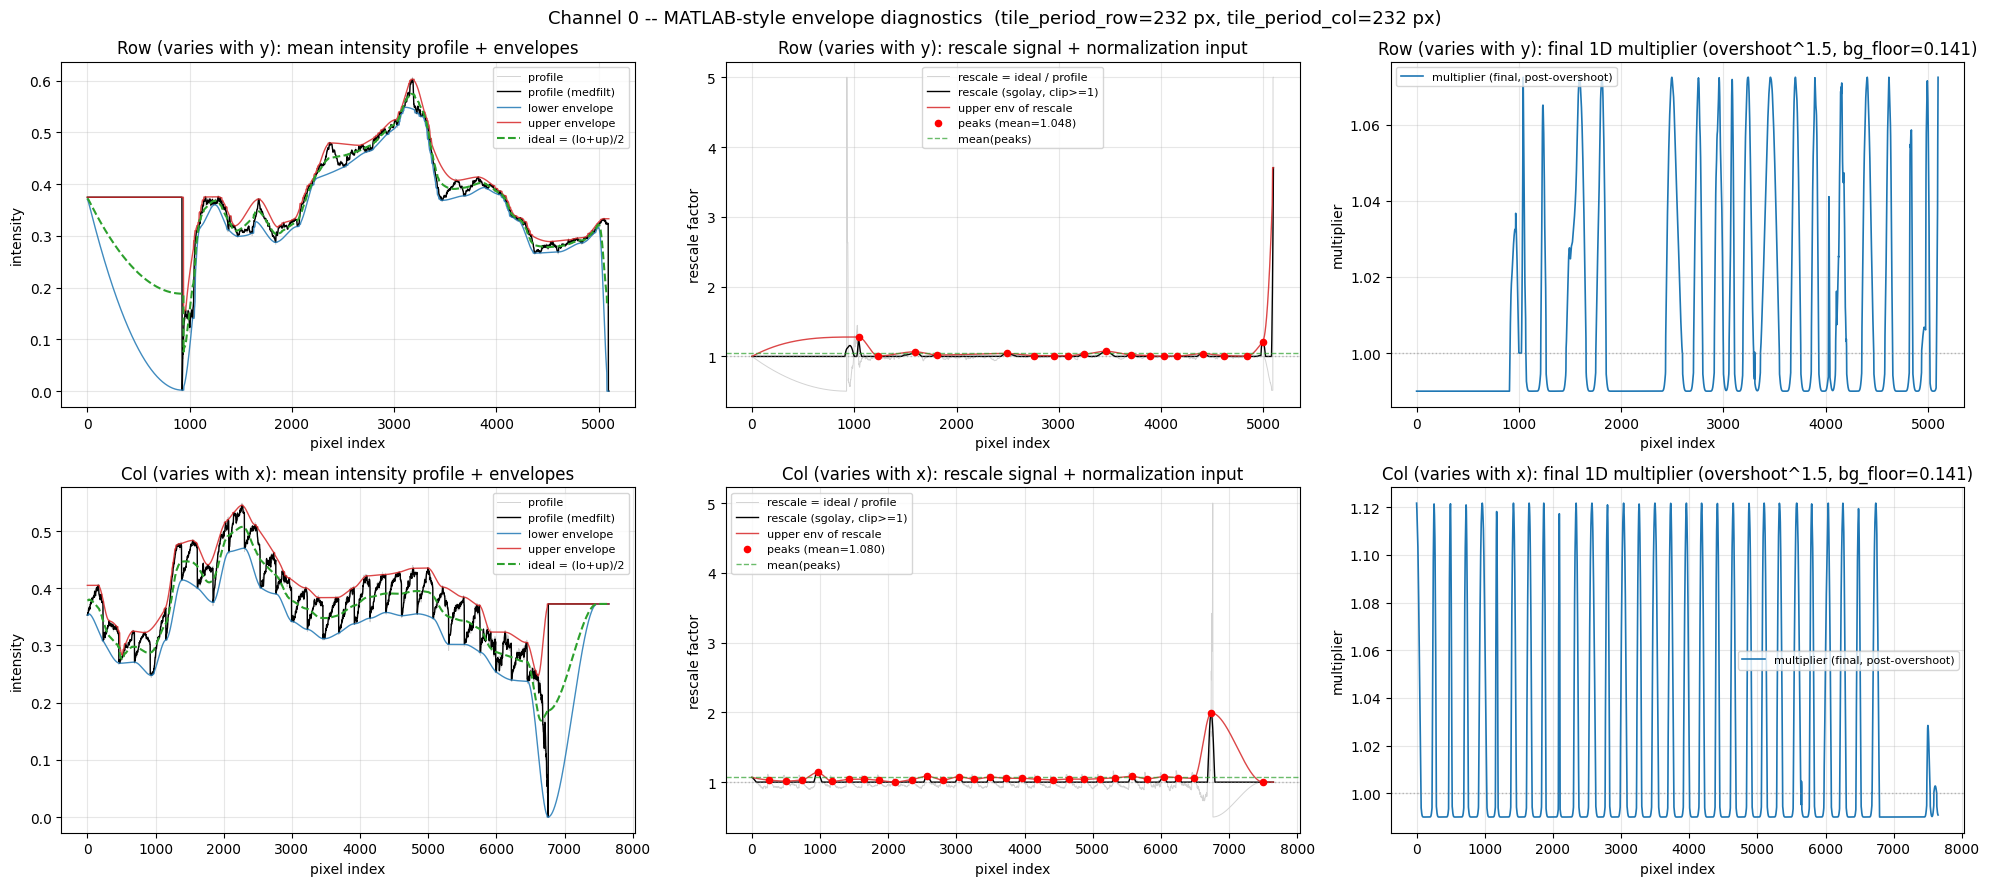

  periodic dip correction (pct=80.0, window=1.5x tile_period, H-strength=0.50, V-strength=1.00): row_mult in [1.000, 2.000], col_mult in [1.000, 3.000]
  bridge_tile_boundaries: dom_col_freq_full=0.002157, dom_row_freq_full=0.002157, band_hw=9, ref_hw=18, smooth_win=151, clip=[0.6, 2.5]
  bridge_tile_boundaries: 32 vertical + 21 horizontal bands bridged
  tonyRemoveLines (peak-preserving, sampled every 10 px for morphology): dom_col_freq=0.002157, dom_row_freq=0.002157, disk=5, line=30
  pre-CLAHE baseline subtraction: sigma_px=500, strength=0.75, ref_mean=3.12, max_excess=3.58
  CLAHE: kernel_size=1391 (tile_period_full=116 px, factor=12), tissue_std=0.170, slope=0.5 -> effective 0.42, clip_limit=0.0008
  Channel 0 done -> dtype: uint16, shape: (10200, 15300)


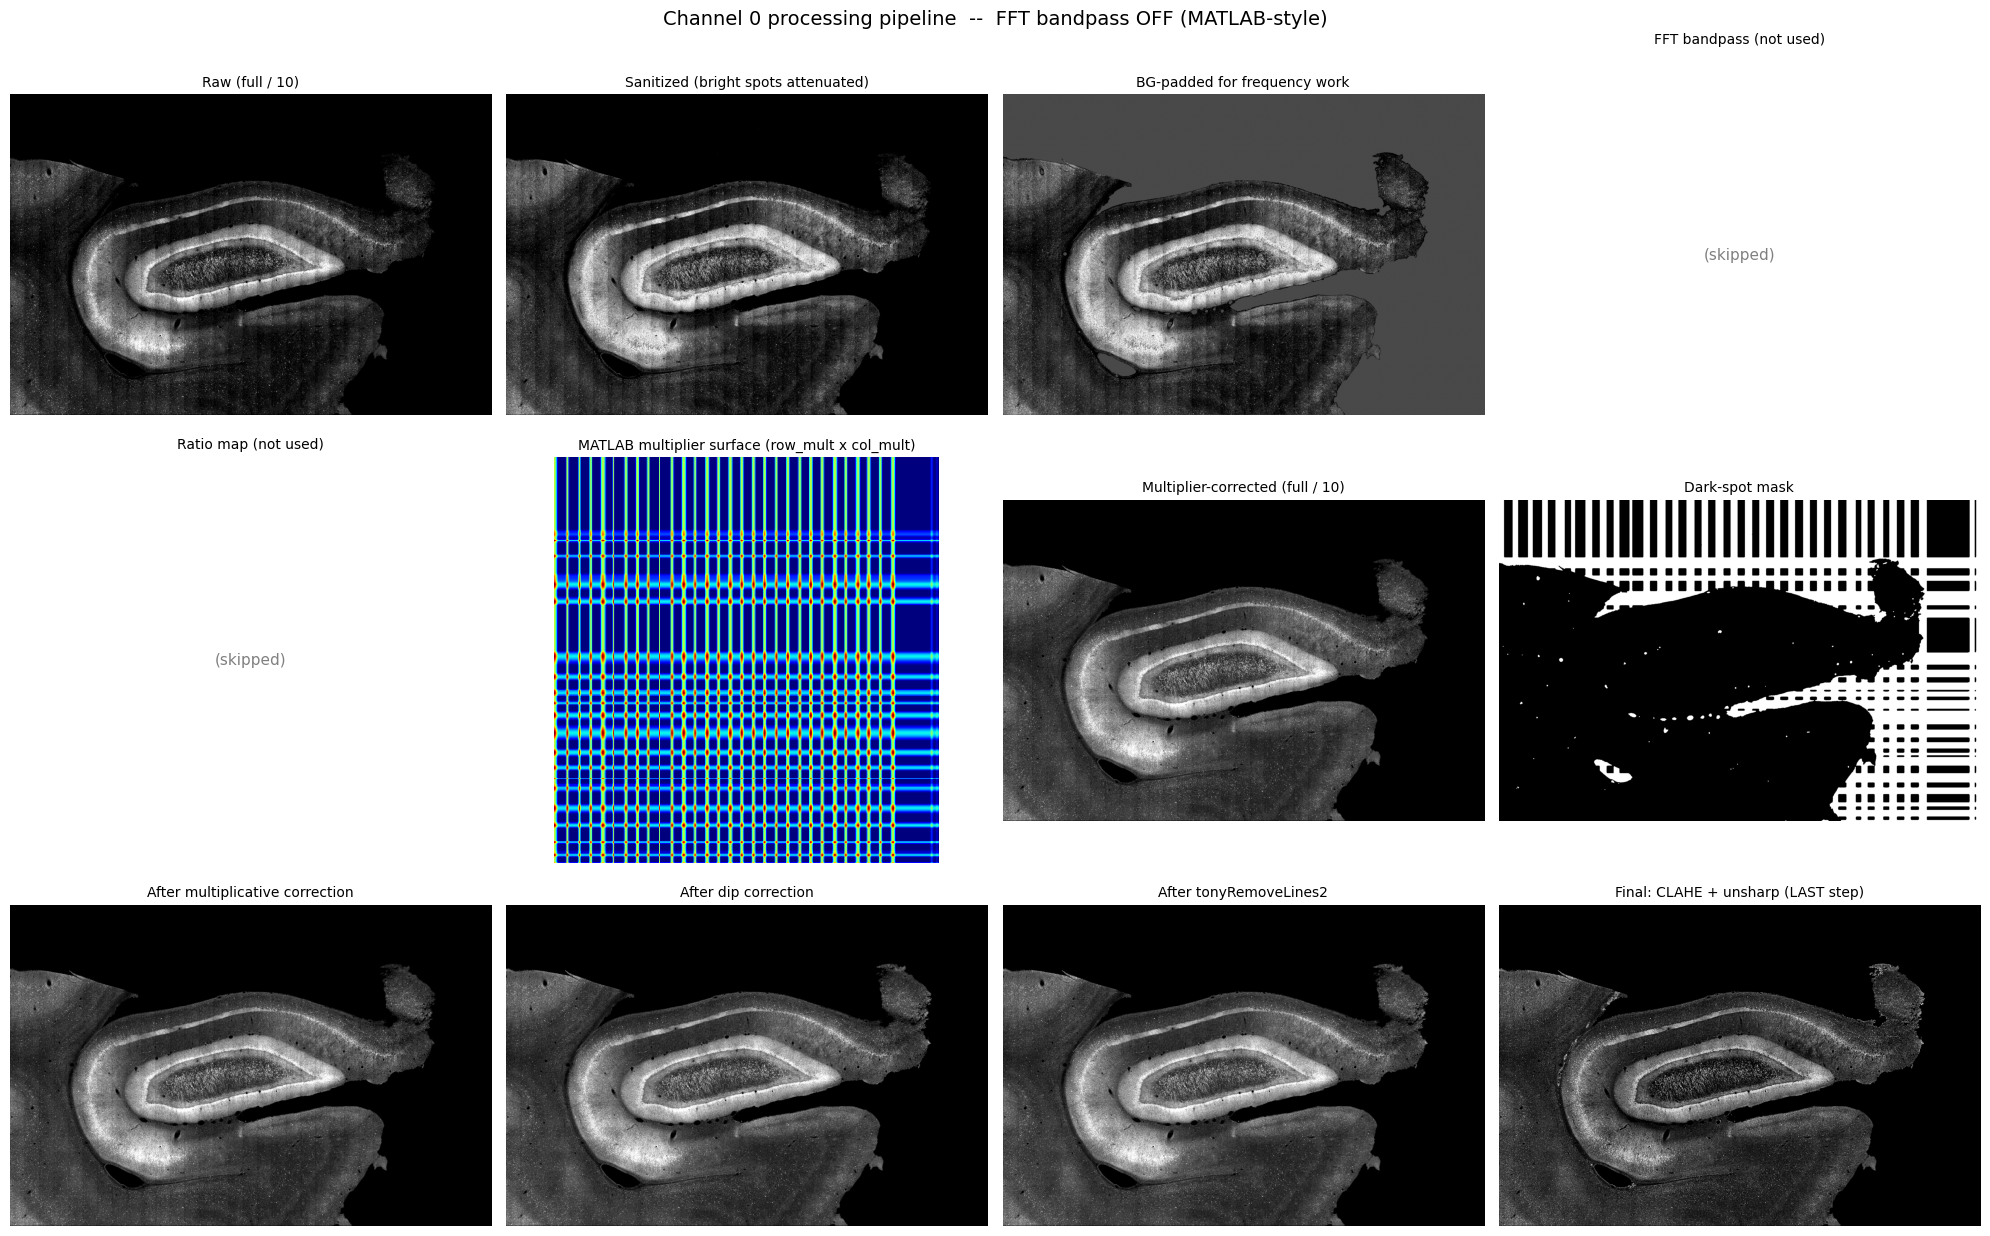


Processing channel 1  (shape=(10200, 15300), dtype=uint8)
  Using dominant freqs (row, col): (0.004314, 0.004314)
  PATH: FFT bandpass OFF  (MATLAB-style multiplicative mask, overshoot=1.5, bg_subtract=0.5)
  Background padded with tissue mean = 152.72
  [envelope diag] row tile_period=231.8 px, win_env1=348, win_env2=232, sg_win=233, mean_peaks=1.198, n_peaks=18
  [envelope diag] col tile_period=231.8 px, win_env1=348, win_env2=232, sg_win=233, mean_peaks=1.120, n_peaks=31


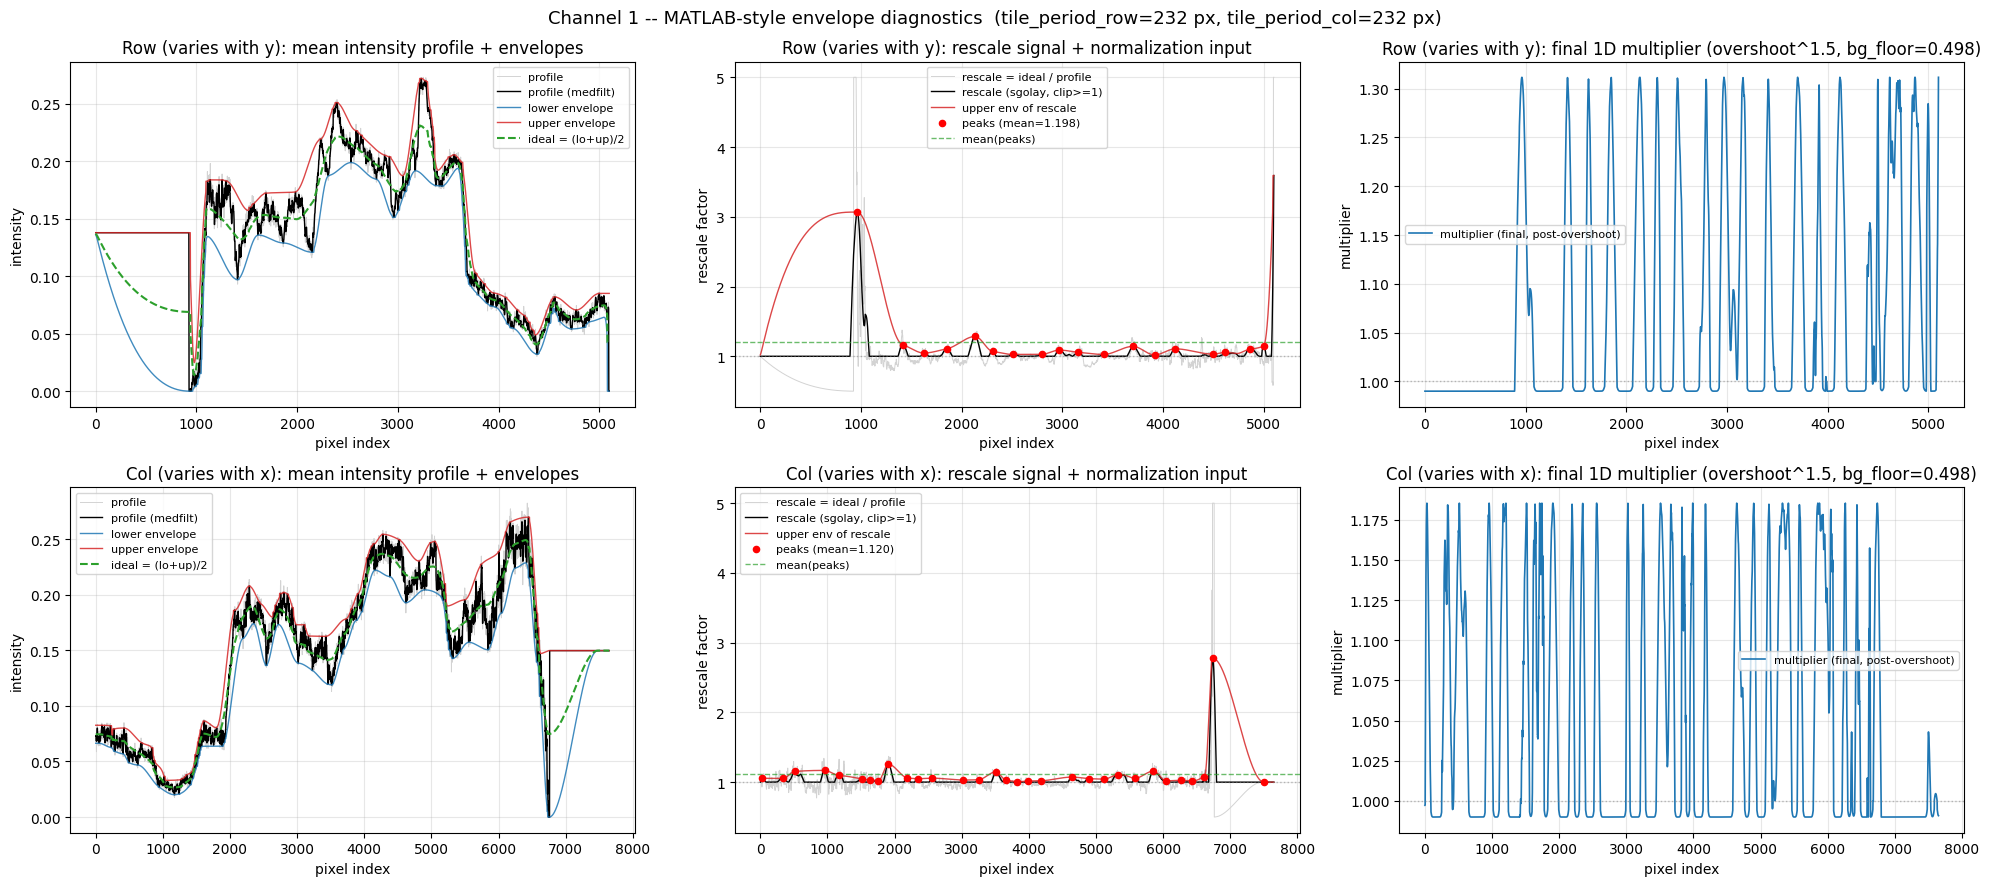

  periodic dip correction (pct=80.0, window=1.5x tile_period, H-strength=0.50, V-strength=1.00): row_mult in [1.000, 2.000], col_mult in [1.000, 3.000]
  bridge_tile_boundaries: dom_col_freq_full=0.002157, dom_row_freq_full=0.002157, band_hw=9, ref_hw=18, smooth_win=151, clip=[0.6, 2.5]
  bridge_tile_boundaries: 32 vertical + 21 horizontal bands bridged
  tonyRemoveLines (peak-preserving, sampled every 10 px for morphology): dom_col_freq=0.002157, dom_row_freq=0.002157, disk=5, line=30
  pre-CLAHE baseline subtraction: sigma_px=500, strength=0.75, ref_mean=0.45, max_excess=0.90
  CLAHE: kernel_size=1391 (tile_period_full=116 px, factor=12), tissue_std=0.158, slope=0.5 -> effective 0.40, clip_limit=0.0008


In [ ]:
# @title Phase 7. Process All Channels Iteratively
# @markdown ### FFT bandpass option
# @markdown Check `do_fft_bandpass` to run the restored legacy-v6 FFT
# @markdown processing path: sequential FFT bandpass, guarded ratio-map
# @markdown correction, morphology/FFT hybrid fusion, dark-spot preservation,
# @markdown second bright-spot attenuation/restoration, and the original
# @markdown "Ultimate" average of contrast methods. Leave unchecked to use
# @markdown the MATLAB-style multiplicative-mask path exactly as before.
# @markdown
# @markdown ### Parameter conventions
# @markdown Each knob below has an inline comment with a one-line
# @markdown description and a `range:` hint. The defaults have been
# @markdown tuned for this dataset. The Phase 7 cell also writes a
# @markdown `VISTAmap_{base_name}_params.txt` log file to `base_path`
# @markdown at the end, listing every value used so the run can be
# @markdown reproduced later by copying back into the sliders.

# ============================================================
# === Pipeline path
# ============================================================
do_fft_bandpass = False  # @param {type:"boolean"}
# Use FFT bandpass path (vs. MATLAB-style multiplicative mask). FFT is
# faster when applicable; the MATLAB mask is more robust. range: True/False.

# ============================================================
# === FFT bandpass tuning (only used when do_fft_bandpass = True)
# ============================================================
filter_large_pixels = 1000  # @param {type:"integer"}
# Legacy v6 FFT low-frequency cutoff in working-image pixels. Lower
# values remove broader background more aggressively; 1000 matches the
# old notebook's FFT branch default. range: 500 - 5000.

filter_small_pixels = 1  # @param {type:"integer"}
# High-frequency noise smoothing radius for the FFT bandpass.
# range: 1 - 3 (1 is fine for most data).

axial_width_factor = 0.30  # @param {type:"number"}
# Width of the cross-shaped FFT axial bands as a fraction of the tile
# fundamental. Smaller = more selective (ignores diagonal tissue
# structure better) but more sensitive to tile-grid misalignment.
# range: 0.20 - 0.50.

fft_tolerance = 0  # @param {type:"slider", min:0, max:100}
# Tolerance margin (in %) around the inferred axial bands. Increase if
# the tile grid is slightly skewed relative to the image axes.
# range: 0 - 100 (typical 0 - 20).

fft_scale = 0.5  # @param {type:"number"}
# Downsampling factor for the Branch-B FFT cleanup in the legacy v6 path.
# 0.5 = compute FFT on a half-resolution image. range: 0.25 - 1.0.

legacy_fft_use_v6_polish_defaults = False  # @param {type:"boolean"}
# When FFT is ON, use the old notebook's polish defaults internally
# (CLAHE tile_size=999, slope=5, first unsharp radius=50, final unsharp
# radius=2/amount=0.8). This does not affect the non-FFT path.
# range: True/False.

legacy_fft_use_native_raw = False  # @param {type:"boolean"}
# When FFT is ON, reload the source TIFF/OME-TIFF at native bit depth for
# the legacy Branch A/Branch B reconstruction when possible. If reload
# fails or the source is not TIFF, the notebook falls back to the Phase-1
# channel without stopping. This does not affect the non-FFT path.
# range: True/False.

export_legacy_fft_diagnostics = False  # @param {type:"boolean"}
# When FFT is ON, export a low-resolution PDF subplot document showing
# the restored old-pipeline stages for each channel. Saved under
# base_path/VISTAmap_{base_name}_legacy_fft_diagnostics. range: True/False.

legacy_fft_diagnostic_stride = 10  # @param {type:"integer"}
# Downsample stride for legacy FFT diagnostic panels. Higher = smaller
# PDF and faster export; lower = more detail. range: 5 - 25.

legacy_fft_branch_a_ratio_strength = 1  # @param {type:"number"}
# Branch-A ratio-map correction strength. Lower this if Branch A makes
# tile-boundary/vignette dips brighter than the surrounding pixels. Set
# to 1.0 for the old v6 full-strength ratio correction. range: 0.50 - 1.10.

legacy_fft_branch_a_ratio_clip_lo = 0.25  # @param {type:"number"}
# Lower clamp for the Branch-A upscaled ratio map after dark-spot
# attenuation. Set to 0.10 for the old v6 loose clamp. range: 0.10 - 1.00.

legacy_fft_branch_a_ratio_clip_hi = 3.0  # @param {type:"number"}
# Upper clamp for the Branch-A upscaled ratio map. Lower this if the
# ratio map overshoots at tile boundaries. Set to 10.0 for the old v6
# loose clamp. range: 1.10 - 10.00.

legacy_fft_branch_a_baseline_percentile = 1.0  # @param {type:"number"}
# Percentile used for the Branch-A background/baseline subtraction before
# multiplying by the ratio map. Old v6 used 1.0. range: 0.0 - 5.0.

legacy_fft_branch_a_baseline_strength = 1.0  # @param {type:"number"}
# Strength of the Branch-A baseline subtraction. Old v6 used 1.0. Increase
# slightly if boundary correction leaves a raised pedestal; decrease if
# dim tissue is clipped. range: 0.0 - 1.5.

# ============================================================
# === MATLAB multiplicative mask tuning (only when do_fft_bandpass = False)
# ============================================================
overshoot_exponent = 1.5  # @param {type:"number"}
# The per-row/col multiplier is raised to this power. A small overshoot
# (1.5) compensates for the bg-subtract step that follows. range: 1.0 - 2.5
# (1.0 = no overshoot, 2.5 = strong overshoot).

bg_subtract_factor = 0.5  # @param {type:"number"}
# Fraction of (multiplied_baseline - baseline) subtracted from the
# corrected image so the background isn't amplified along with signal.
# range: 0.0 - 1.0 (0.0 = no subtract; 1.0 = full subtract matches MATLAB).

matlab_envelope_factor = 1.5  # @param {type:"number"}
# Envelope window for the find-peaks pass on the per-axis mean profile,
# in tile periods. Larger = envelopes track slow signal trend instead
# of hugging every tile dip. range: 0.8 - 2.5.

matlab_rescale_factor = 1.0  # @param {type:"number"}
# Envelope window for the rescale-signal pass, in tile periods.
# range: 0.6 - 2.0.

# ============================================================
# === Dip correction (M block) -- targets periodic tile dim bands
# ============================================================
do_dip_correction = True  # @param {type:"boolean"}
# Enable the M block. Disable to skip dip correction entirely.
# range: True/False.

dip_baseline_window_factor = 1.5  # @param {type:"number"}
# Width of the percentile-filter baseline window, in tile periods.
# Must be > 1.0 so each window covers at least one full tile cycle.
# range: 1.0 - 3.0.

dip_baseline_percentile = 80.0  # @param {type:"number"}
# Percentile (0-100) used for the baseline. Periodic dips are dim
# outliers occupying < 10% of pixels, so the 80th percentile is
# dominated by bright inter-dip pixels and tracks natural fluorescence
# topography without being pulled down by tile dips. range: 70 - 95.

dip_baseline_smooth_factor = 0.3  # @param {type:"number"}
# Light Gaussian smoothing of the percentile envelope (sigma in tile
# periods) so the baseline is continuous. range: 0.1 - 0.5.

dip_mult_max = 3.0  # @param {type:"number"}
# Hard upper bound on the per-row/col multiplier. range: 1.5 - 5.0.

dip_correction_strength_horizontal = 0.5  # @param {type:"number"}
# Strength of the HORIZONTAL-line attenuation (i.e. the per-row
# multiplier that brightens dim rows, fixing horizontal tile dim
# bands). 1.0 = full, 0.0 = disabled. range: 0.0 - 1.0.

dip_correction_strength_vertical = 1.0  # @param {type:"number"}
# Strength of the VERTICAL-line attenuation (i.e. the per-col
# multiplier that brightens dim cols, fixing vertical tile dim bands).
# For this dataset vertical lines dominate, so the default is full
# strength. range: 0.0 - 1.0.

# ============================================================
# === Tile-boundary bridging (M.5 block)
# ============================================================
do_bridge_boundaries = True  # @param {type:"boolean"}
# Enable per-boundary multiplier that bridges the dim band at each
# detected tile boundary. range: True/False.

bridge_band_half_width = 9  # @param {type:"integer"}
# Half-width of the tile-boundary band in full-resolution pixels.
# Bands span (2 * bridge_band_half_width + 1) px. Set to match the
# typical width of your visible dark stripes. range: 3 - 15.

bridge_ref_half_width = 18  # @param {type:"integer"}
# Width of each side reference window (left and right of the band).
# Must be > band_half_width. range: 8 - 30.

bridge_gap = 3  # @param {type:"integer"}
# Safety gap (in px) between band edge and reference window edge.
# range: 1 - 10.

bridge_smooth_win = 151  # @param {type:"integer"}
# Moving-average window for smoothing the per-row multiplier (along
# the free axis). range: 31 - 301.

bridge_mult_clip_lo = 0.6  # @param {type:"number"}
# Lower clip on the bridge multiplier (safety: don't darken bright
# rows even if the math suggests it). range: 0.3 - 0.9.

bridge_mult_clip_hi = 2.5  # @param {type:"number"}
# Upper clip on the bridge multiplier (cap on brightening).
# range: 1.5 - 4.0.

bridge_using_tophat = True  # @param {type:"boolean"}
# Use a morphological top-hat-style reference for stabilization where
# the side reference windows are themselves contaminated. range: True/False.

bridge_bh_width = 151  # @param {type:"integer"}
# Width of the line SE used for the morphological reference estimate.
# range: 51 - 301.

# ============================================================
# === Final residual line cleanup (N.5 block, port of MATLAB tonyRemoveLines2)
# ============================================================
do_remove_lines = True  # @param {type:"boolean"}
# Enable the tonyRemoveLines2 final cleanup pass. range: True/False.

remove_lines_disk = 5  # @param {type:"integer"}
# Disk SE radius (full-res pixels) for the bright-spot tophat inside
# tony_remove_lines. range: 1 - 50.

remove_lines_line = 30  # @param {type:"integer"}
# Horizontal line SE length (full-res pixels) for the illumination
# estimate. range: 10 - 100.

tony_detrend_periods = 3.0  # @param {type:"number"}
# Sigma of the slow-trend low-pass for the envelope-detection step
# inside tony_remove_lines, in tile periods. range: 0.0 - 5.0
# (0 disables the detrend; 3.0 separates tile periodic from slow trend).

tony_peak_widen_factor = 0.35  # @param {type:"number"}
# Fraction of tile_period to widen each multiplier peak. Real tile
# boundaries are several px wide -- a 1-px-wide peak leaves the band
# edges uncorrected. range: 0.0 - 0.5 (0 disables widening).

# ============================================================
# === CLAHE + unsharp (K + L blocks) -- LAST step in the pipeline
# ============================================================
slope = 0.5  # @param {type:"number"}
# CLAHE nominal slope. Directly controls clip_limit (= slope / hist_bins).
# Lower = more conservative CLAHE (less local-contrast enhancement,
# less splotchy appearance). range: 0.5 - 3.0. (Raise to 2-3 for
# under-contrasted channels; lower to 0.5-0.8 for splotchy / over-
# equalized output.)

clahe_kernel_tile_factor = 12  # @param {type:"number"}
# CLAHE kernel size = max(clahe_min_kernel, factor * tile_period_full).
# Each CLAHE window MUST span multiple tiles, otherwise CLAHE just
# enhances the tile-boundary contrast within each window. range: 6 - 16
# (raise to 12-16 if you still see CLAHE-kernel-boundary splotches).

clahe_min_kernel = 555  # @param {type:"integer"}
# Floor on the auto-computed CLAHE kernel size, in pixels. range: 99 - 1500.

clahe_adaptive_slope = True  # @param {type:"boolean"}
# Scale the CLAHE slope by the tissue-only intensity std (prevents
# over-equalization in dim or low-dynamic-range channels). range: True/False.

clahe_std_ref = 0.2  # @param {type:"number"}
# Reference tissue-intensity std (in [0,1]) above which the full slope
# is used. Channels with std < this get a proportionally smaller
# effective slope. range: 0.05 - 0.30 (raise to auto-attenuate more
# channels; lower for less adaptive scaling).

clahe_min_slope = 0.2  # @param {type:"number"}
# Floor on the adaptive slope so even very dim channels still get
# minimum local-contrast enhancement. range: 0.1 - 1.0.

pre_clahe_baseline_strength = 0.75  # @param {type:"number"}
# Strength of the baseline-subtraction step that runs right before
# CLAHE. Compensates for residual over-correction where formerly-dim
# regions ended up brighter than their surroundings. 0.0 disables
# entirely; 1.0 fully flattens any slow brightness excess back to the
# tissue mean. range: 0.0 - 1.0.
pre_clahe_baseline_sigma_px = 500.0  # @param {type:"number"}
# Gaussian sigma (in full-resolution pixels) for the slow-background
# estimate. Should be a few times larger than the tile period so the
# Gaussian smooths over individual tiles but still picks up larger
# slow-varying over-correction patches. range: 100 - 2000 (typical
# 2-4x your full-resolution tile period; for the 232 px tile data
# 500 is a sensible starting point).

# ============================================================
# === Diagnostics
# ============================================================
show_diagnostics = True  # @param {type:"boolean"}
# Show the per-channel diagnostic figure (12 panels: raw, sanitized,
# main correction, dip correction, after bridge, after tony, final
# CLAHE output). range: True/False.

monitor_negatives = True  # @param {type:"boolean"}
# Print a one-line warning whenever a pipeline step produces values
# outside its expected range (e.g. negatives after unsharp). Stats
# are always recorded in diag['step_stats']. range: True/False.

# ============================================================

n_channels = original_images.shape[0]
H, W = original_images.shape[1], original_images.shape[2]
print(f"Processing {n_channels} channel(s) at full resolution {H} x {W}...")

legacy_fft_diagnostics_dir = os.path.join(base_path, f"VISTAmap_{base_name}_legacy_fft_diagnostics")
if do_fft_bandpass and export_legacy_fft_diagnostics:
    os.makedirs(legacy_fft_diagnostics_dir, exist_ok=True)
    print(f"Legacy FFT diagnostic documents will be saved to: {legacy_fft_diagnostics_dir}")
print(f"Global tile freqs (row, col): ({dom_row_freq:.6f}, {dom_col_freq:.6f})")
if do_fft_bandpass:
    print(f"FFT path ON: legacy v6 ratio-map/hybrid fusion, filter_large_pixels = {filter_large_pixels}, "
          f"filter_small_pixels = {filter_small_pixels}, tolerance = {fft_tolerance}, fft_scale = {fft_scale}")
    print(f"Branch A ratio guard: strength = {legacy_fft_branch_a_ratio_strength}, "
          f"clip = [{legacy_fft_branch_a_ratio_clip_lo}, {legacy_fft_branch_a_ratio_clip_hi}], "
          f"baseline p = {legacy_fft_branch_a_baseline_percentile}, "
          f"baseline strength = {legacy_fft_branch_a_baseline_strength}")
    print(f"Legacy v6 polish defaults: {legacy_fft_use_v6_polish_defaults}; "
          f"native raw reload: {legacy_fft_use_native_raw}; "
          f"export diagnostics: {export_legacy_fft_diagnostics}")
else:
    print(f"FFT path OFF: MATLAB-style multiplicative mask "
          f"(overshoot_exponent = {overshoot_exponent}, bg_subtract_factor = {bg_subtract_factor})")
if do_remove_lines:
    print(f"Final residual line cleanup ON: disk={remove_lines_disk}, line={remove_lines_line}")
else:
    print("Final residual line cleanup OFF.")

corrected_stack = np.empty((n_channels, H, W), dtype=np.uint16)

for c in range(n_channels):
    corrected_stack[c] = process_channel(
        original_images[c],
        channel_idx=c,
        tissue_mask=tissue_mask,
        is_isolated=is_isolated,
        dom_row_freq=dom_row_freq,
        dom_col_freq=dom_col_freq,
        shrinkage_factor=shrinkage_factor,
        do_fft_bandpass=do_fft_bandpass,
        filter_large_pixels=filter_large_pixels,
        filter_small_pixels=filter_small_pixels,
        axial_width_factor=axial_width_factor,
        tolerance=fft_tolerance,
        fft_scale=fft_scale,
        overshoot_exponent=overshoot_exponent,
        bg_subtract_factor=bg_subtract_factor,
        matlab_envelope_factor=matlab_envelope_factor,
        matlab_rescale_factor=matlab_rescale_factor,
        do_dip_correction=do_dip_correction,
        dip_baseline_window_factor=dip_baseline_window_factor,
        dip_baseline_percentile=dip_baseline_percentile,
        dip_baseline_smooth_factor=dip_baseline_smooth_factor,
        dip_mult_max=dip_mult_max,
        dip_correction_strength_horizontal=dip_correction_strength_horizontal,
        dip_correction_strength_vertical=dip_correction_strength_vertical,
        do_remove_lines=do_remove_lines,
        remove_lines_disk=remove_lines_disk,
        remove_lines_line=remove_lines_line,
        tony_detrend_periods=tony_detrend_periods,
        tony_peak_widen_factor=tony_peak_widen_factor,
        do_bridge_boundaries=do_bridge_boundaries,
        bridge_band_half_width=bridge_band_half_width,
        bridge_ref_half_width=bridge_ref_half_width,
        bridge_gap=bridge_gap,
        bridge_smooth_win=bridge_smooth_win,
        bridge_mult_clip_lo=bridge_mult_clip_lo,
        bridge_mult_clip_hi=bridge_mult_clip_hi,
        bridge_using_tophat=bridge_using_tophat,
        bridge_bh_width=bridge_bh_width,
        slope=slope,
        clahe_kernel_tile_factor=clahe_kernel_tile_factor,
        clahe_min_kernel=clahe_min_kernel,
        clahe_adaptive_slope=clahe_adaptive_slope,
        clahe_std_ref=clahe_std_ref,
        clahe_min_slope=clahe_min_slope,
        monitor_negatives=monitor_negatives,
        pre_clahe_baseline_strength=pre_clahe_baseline_strength,
        pre_clahe_baseline_sigma_px=pre_clahe_baseline_sigma_px,
        show_diagnostics=show_diagnostics,
        legacy_fft_use_v6_polish_defaults=legacy_fft_use_v6_polish_defaults,
        legacy_fft_use_native_raw=legacy_fft_use_native_raw,
        export_legacy_fft_diagnostics=export_legacy_fft_diagnostics,
        legacy_fft_diagnostics_dir=legacy_fft_diagnostics_dir,
        legacy_fft_diagnostic_stride=legacy_fft_diagnostic_stride,
        legacy_fft_branch_a_ratio_strength=legacy_fft_branch_a_ratio_strength,
        legacy_fft_branch_a_ratio_clip_lo=legacy_fft_branch_a_ratio_clip_lo,
        legacy_fft_branch_a_ratio_clip_hi=legacy_fft_branch_a_ratio_clip_hi,
        legacy_fft_branch_a_baseline_percentile=legacy_fft_branch_a_baseline_percentile,
        legacy_fft_branch_a_baseline_strength=legacy_fft_branch_a_baseline_strength,
    )
    gc.collect()

print("\nAll channels processed.")
print(f"corrected_stack shape: {corrected_stack.shape}, dtype: {corrected_stack.dtype}")

# ============================================================
# === Save parameter log so this run can be reproduced later
# ============================================================
import datetime as _dt

def _maybe(name):
    """Return the value of a global if it exists, else None."""
    return globals().get(name, None)

_param_sections = [
    ("Input", [
        ("filename",                              filename),
        ("base_path",                             base_path),
        ("full_path",                             full_path),
        ("original_images.shape",                 tuple(original_images.shape)),
        ("corrected_stack.shape",                 tuple(corrected_stack.shape)),
    ]),
    ("Phase 4 - Detection", [
        ("shrinkage_factor",                      _maybe("shrinkage_factor")),
        ("dom_row_freq",                          float(dom_row_freq)),
        ("dom_col_freq",                          float(dom_col_freq)),
        ("tile_period_full_px",                   _maybe("tile_period_full_px")),
        ("manual_tile_period_full_px",            _maybe("manual_tile_period_full_px")),
        ("suggested_filter_large",                _maybe("suggested_filter_large")),
        ("minimum_tiles_in_axis",                 _maybe("minimum_tiles_in_axis")),
        ("strong_peak_fraction",                  _maybe("strong_peak_fraction")),
    ]),
    ("Phase 5 - Tissue mask", [
        ("is_isolated",                           _maybe("is_isolated")),
        ("tissue_mask.shape",                     tuple(tissue_mask.shape) if _maybe("tissue_mask") is not None else None),
        ("tissue_pixel_fraction",                 float(tissue_mask.mean()) if _maybe("tissue_mask") is not None else None),
    ]),
    ("Phase 7 - Pipeline path", [
        ("do_fft_bandpass",                       do_fft_bandpass),
    ]),
    ("Phase 7 - FFT bandpass tuning", [
        ("filter_large_pixels",                   filter_large_pixels),
        ("filter_small_pixels",                   filter_small_pixels),
        ("axial_width_factor",                    axial_width_factor),
        ("fft_tolerance",                         fft_tolerance),
        ("fft_scale",                             fft_scale),
        ("legacy_fft_use_v6_polish_defaults",     legacy_fft_use_v6_polish_defaults),
        ("legacy_fft_use_native_raw",             legacy_fft_use_native_raw),
        ("legacy_fft_branch_a_ratio_strength",    legacy_fft_branch_a_ratio_strength),
        ("legacy_fft_branch_a_ratio_clip_lo",     legacy_fft_branch_a_ratio_clip_lo),
        ("legacy_fft_branch_a_ratio_clip_hi",     legacy_fft_branch_a_ratio_clip_hi),
        ("legacy_fft_branch_a_baseline_percentile", legacy_fft_branch_a_baseline_percentile),
        ("legacy_fft_branch_a_baseline_strength", legacy_fft_branch_a_baseline_strength),
    ]),
    ("Phase 7 - MATLAB multiplicative mask", [
        ("overshoot_exponent",                    overshoot_exponent),
        ("bg_subtract_factor",                    bg_subtract_factor),
        ("matlab_envelope_factor",                matlab_envelope_factor),
        ("matlab_rescale_factor",                 matlab_rescale_factor),
    ]),
    ("Phase 7 - Dip correction", [
        ("do_dip_correction",                     do_dip_correction),
        ("dip_baseline_window_factor",            dip_baseline_window_factor),
        ("dip_baseline_percentile",               dip_baseline_percentile),
        ("dip_baseline_smooth_factor",            dip_baseline_smooth_factor),
        ("dip_mult_max",                          dip_mult_max),
        ("dip_correction_strength_horizontal",    dip_correction_strength_horizontal),
        ("dip_correction_strength_vertical",      dip_correction_strength_vertical),
    ]),
    ("Phase 7 - Bridge tile boundaries", [
        ("do_bridge_boundaries",                  do_bridge_boundaries),
        ("bridge_band_half_width",                bridge_band_half_width),
        ("bridge_ref_half_width",                 bridge_ref_half_width),
        ("bridge_gap",                            bridge_gap),
        ("bridge_smooth_win",                     bridge_smooth_win),
        ("bridge_mult_clip_lo",                   bridge_mult_clip_lo),
        ("bridge_mult_clip_hi",                   bridge_mult_clip_hi),
        ("bridge_using_tophat",                   bridge_using_tophat),
        ("bridge_bh_width",                       bridge_bh_width),
    ]),
    ("Phase 7 - Tony remove lines (N.5)", [
        ("do_remove_lines",                       do_remove_lines),
        ("remove_lines_disk",                     remove_lines_disk),
        ("remove_lines_line",                     remove_lines_line),
        ("tony_detrend_periods",                  tony_detrend_periods),
        ("tony_peak_widen_factor",                tony_peak_widen_factor),
    ]),
    ("Phase 7 - CLAHE + unsharp", [
        ("slope",                                 slope),
        ("clahe_kernel_tile_factor",              clahe_kernel_tile_factor),
        ("clahe_min_kernel",                      clahe_min_kernel),
        ("clahe_adaptive_slope",                  clahe_adaptive_slope),
        ("clahe_std_ref",                         clahe_std_ref),
        ("clahe_min_slope",                       clahe_min_slope),
        ("pre_clahe_baseline_strength",           pre_clahe_baseline_strength),
        ("pre_clahe_baseline_sigma_px",           pre_clahe_baseline_sigma_px),
    ]),
    ("Phase 7 - Diagnostics", [
        ("show_diagnostics",                      show_diagnostics),
        ("monitor_negatives",                     monitor_negatives),
        ("export_legacy_fft_diagnostics",         export_legacy_fft_diagnostics),
        ("legacy_fft_diagnostic_stride",          legacy_fft_diagnostic_stride),
        ("legacy_fft_diagnostics_dir",             legacy_fft_diagnostics_dir),
    ]),
]

params_log_path = os.path.join(base_path, f"VISTAmap_{base_name}_params.txt")
try:
    with open(params_log_path, "w") as _f:
        _f.write(f"# VISTAmap parameter log\n")
        _f.write(f"# Saved:        {_dt.datetime.now().isoformat(timespec='seconds')}\n")
        _f.write(f"# Source file:  {full_path}\n")
        _f.write(f"#\n")
        _f.write(f"# Copy the values below back into the corresponding Phase 1 / 4 / 5 / 7\n")
        _f.write(f"# sliders to reproduce this run. Values marked `None` were not set in\n")
        _f.write(f"# this run (the relevant cell uses its own default).\n")
        for section, items in _param_sections:
            _f.write(f"\n[{section}]\n")
            for name, value in items:
                _f.write(f"{name} = {value!r}\n")
    print(f"\nSaved parameter log to: {params_log_path}")
except Exception as _exc:
    print(f"\nWarning: failed to save parameter log ({_exc}).")

# ============================================================
# === Side-by-side raw vs corrected preview
# ============================================================
ncols = min(n_channels, 4)
nrows = int(np.ceil(n_channels / ncols))
fig, axes = plt.subplots(nrows * 2, ncols, figsize=(4 * ncols, 4 * 2 * nrows), squeeze=False)
for c in range(n_channels):
    r0 = (c // ncols) * 2
    c0 = c % ncols
    raw_view = original_images[c, ::10, ::10]
    cor_view = corrected_stack[c, ::10, ::10]
    p1, p99 = np.percentile(raw_view, (1, 99))
    axes[r0, c0].imshow(exposure.rescale_intensity(raw_view, in_range=(p1, p99)), cmap='gray')
    axes[r0, c0].set_title(f"Channel {c} - Raw")
    axes[r0, c0].axis('off')
    p1, p99 = np.percentile(cor_view, (1, 99))
    axes[r0 + 1, c0].imshow(exposure.rescale_intensity(cor_view, in_range=(p1, p99)), cmap='gray')
    axes[r0 + 1, c0].set_title(f"Channel {c} - Corrected")
    axes[r0 + 1, c0].axis('off')
for c in range(n_channels, nrows * ncols):
    r0 = (c // ncols) * 2
    c0 = c % ncols
    axes[r0, c0].axis('off')
    axes[r0 + 1, c0].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# @title Phase 8. Save All Channels as a Single OME-TIFF
import tifffile

ome_filename = f"VISTAmap_{base_name}.ome.tif"
ome_output_path = os.path.join(base_path, ome_filename)

print(f"Saving OME-TIFF to: {ome_output_path}")
tifffile.imwrite(
    ome_output_path,
    corrected_stack,
    photometric='minisblack',
    ome=True,
    metadata={
        'axes': 'CYX',
        'Channel': {'Name': [f'Channel_{i}' for i in range(corrected_stack.shape[0])]},
    },
)
print("OME-TIFF saved.")


In [ ]:
# @title Phase 9. RGBCMYK Overlay (PNG, original aspect ratio)
from PIL import Image as PILImage

RGBCMYK_COLORS = [
    (1.0, 0.0, 0.0),   # R
    (0.0, 1.0, 0.0),   # G
    (0.0, 0.0, 1.0),   # B
    (0.0, 1.0, 1.0),   # C
    (1.0, 0.0, 1.0),   # M
    (1.0, 1.0, 0.0),   # Y
    (1.0, 1.0, 1.0),   # K (additive white)
]
overlay_alpha = 0.25

print("Building full-resolution tissue mask for overlay processing...")
full_tissue_mask = transform.resize(
    tissue_mask.astype(np.uint8),
    (corrected_stack.shape[1], corrected_stack.shape[2]),
    order=0, preserve_range=True,
).astype(bool)

H, W = corrected_stack.shape[1], corrected_stack.shape[2]
overlay_rgb = np.zeros((H, W, 3), dtype=np.float32)

for c in range(corrected_stack.shape[0]):
    chan = corrected_stack[c].astype(np.float32)
    inside = chan[full_tissue_mask & (chan > 0)]
    if inside.size > 0:
        bottom10 = np.percentile(inside, 10)
        chan[chan < bottom10] = 0
    else:
        bottom10 = 0
    nonzero = chan[chan > 0]
    if nonzero.size > 0:
        lo, hi = np.percentile(nonzero, (1, 99))
        if hi > lo:
            chan_norm = np.clip((chan - lo) / (hi - lo), 0, 1)
        else:
            chan_norm = np.clip(chan / max(hi, 1e-6), 0, 1)
    else:
        chan_norm = np.zeros_like(chan, dtype=np.float32)
    color = RGBCMYK_COLORS[c % len(RGBCMYK_COLORS)]
    overlay_rgb[..., 0] += chan_norm * color[0] * overlay_alpha
    overlay_rgb[..., 1] += chan_norm * color[1] * overlay_alpha
    overlay_rgb[..., 2] += chan_norm * color[2] * overlay_alpha
    print(f"  Channel {c}: bottom-10 cutoff = {bottom10:.2f}, color = {color}")
    del chan, chan_norm
    gc.collect()

overlay_rgb = np.clip(overlay_rgb, 0, 1)

# auto brightness/contrast adjustment + saturation boost.
# 1) Percentile-stretch the global RGB to fill [0,1] using the
#    non-background luminance distribution. This gives a vibrant
#    image without crushing highlights.
# 2) Boost saturation by 10%% via HSV.
auto_brightness_percentile_lo = 1.0
auto_brightness_percentile_hi = 99.5
saturation_boost = 1.10

from skimage import color as _skcolor
luma = (0.299 * overlay_rgb[..., 0]
        + 0.587 * overlay_rgb[..., 1]
        + 0.114 * overlay_rgb[..., 2])
_nz = luma[luma > 1e-4]
if _nz.size > 100:
    _lo = float(np.percentile(_nz, auto_brightness_percentile_lo))
    _hi = float(np.percentile(_nz, auto_brightness_percentile_hi))
    if _hi > _lo:
        print(f"Auto brightness/contrast: stretch luma [{_lo:.4f}, {_hi:.4f}] -> [0, 1]")
        overlay_rgb = np.clip((overlay_rgb - _lo) / (_hi - _lo), 0.0, 1.0)
    else:
        print("Auto brightness/contrast: skipped (degenerate luma range)")
else:
    print("Auto brightness/contrast: skipped (too few non-zero pixels)")
del luma, _nz

if saturation_boost != 1.0:
    _hsv = _skcolor.rgb2hsv(overlay_rgb.astype(np.float32))
    _hsv[..., 1] = np.clip(_hsv[..., 1] * saturation_boost, 0.0, 1.0)
    overlay_rgb = _skcolor.hsv2rgb(_hsv).astype(np.float32)
    np.clip(overlay_rgb, 0.0, 1.0, out=overlay_rgb)
    del _hsv
    print(f"Saturation boost x{saturation_boost:.2f} applied")

overlay_uint8 = (overlay_rgb * 255).astype(np.uint8)
del overlay_rgb
gc.collect()

overlay_png_filename = f"VISTAmap_{base_name}.png"
overlay_png_path = os.path.join(base_path, overlay_png_filename)
PILImage.fromarray(overlay_uint8).save(overlay_png_path)
print(f"Saved overlay PNG to: {overlay_png_path}")

aspect = H / W
display_w = 12.0
display_h = display_w * aspect
fig = plt.figure(figsize=(display_w, display_h))
ax = fig.add_axes([0, 0, 1, 1])
ax.imshow(overlay_uint8[::4, ::4])
ax.set_axis_off()
plt.show()


In [ ]:
# @title Phase 10. Save Raw + Processed Channels as Individual TIFs (Full Resolution)
import tifffile

print("Saving full-resolution raw + corrected channel TIFs...")
for c in range(corrected_stack.shape[0]):
    raw_name = f"VISTAmap_{base_name}_raw_C{c}.tif"
    raw_path = os.path.join(base_path, raw_name)
    tifffile.imwrite(raw_path, original_images[c], photometric='minisblack')
    print(f"  raw      -> {raw_path}  (shape {original_images[c].shape}, dtype {original_images[c].dtype})")

    cor_name = f"VISTAmap_{base_name}_corrected_C{c}.tif"
    cor_path = os.path.join(base_path, cor_name)
    tifffile.imwrite(cor_path, corrected_stack[c], photometric='minisblack')
    print(f"  corrected -> {cor_path}  (shape {corrected_stack[c].shape}, dtype {corrected_stack[c].dtype})")

print("All individual channel TIFs saved.")


In [ ]:
# @title Phase 11. K-means Pixel Clustering (k=7, discernible palette, tissue-only)
from sklearn.cluster import MiniBatchKMeans
from PIL import Image as PILImage

n_clusters = 7  # @param {type:"integer"}
ds_factor_km = 10

# cluster ONLY tissue pixels (mask out background), then paint the
# background black in the output. Without this, k-means spends clusters
# on background pixels too, and the "background" cluster ends up tinted
# rather than truly black.
print("Building downsampled tissue mask for clustering...")
ds_tissue_mask = transform.resize(
    tissue_mask.astype(np.uint8),
    (corrected_stack.shape[1] // ds_factor_km, corrected_stack.shape[2] // ds_factor_km),
    order=0, preserve_range=True,
).astype(bool)

ds_stack = corrected_stack[:, ::ds_factor_km, ::ds_factor_km].astype(np.float32)
print(f"Downsampled stack shape: {ds_stack.shape}, tissue pixels: {int(ds_tissue_mask.sum()):,} / {ds_tissue_mask.size:,}")
C, H_ds, W_ds = ds_stack.shape

# Normalize each channel using tissue-only percentiles
ds_normed = np.empty_like(ds_stack)
for c in range(C):
    chan = ds_stack[c]
    tissue_vals = chan[ds_tissue_mask & (chan > 0)]
    if tissue_vals.size > 0:
        lo, hi = np.percentile(tissue_vals, (1, 99))
    else:
        lo, hi = 0.0, 1.0
    if hi > lo:
        ds_normed[c] = np.clip((chan - lo) / (hi - lo), 0, 1)
    else:
        ds_normed[c] = np.zeros_like(chan)

# Build features. Keep a tissue mask aligned with the pixel order.
features_all = ds_normed.transpose(1, 2, 0).reshape(-1, C)
mask_flat = ds_tissue_mask.reshape(-1)
features_tissue = features_all[mask_flat]
print(f"Clustering {features_tissue.shape[0]:,} tissue pixels x {features_tissue.shape[1]} channels "
      f"(background excluded)...")
del ds_stack, ds_normed
gc.collect()

kmeans = MiniBatchKMeans(
    n_clusters=n_clusters, random_state=42, n_init=10,
    batch_size=10000, max_iter=300,
)
labels_tissue = kmeans.fit_predict(features_tissue)

# Sort clusters by mean brightness so cluster 0 is dimmest, cluster k-1 is brightest
cluster_means = np.array([
    features_tissue[labels_tissue == k].mean() if (labels_tissue == k).any() else 0
    for k in range(n_clusters)
])
order = np.argsort(cluster_means)
remap = np.empty(n_clusters, dtype=int)
for new_idx, old_idx in enumerate(order):
    remap[old_idx] = new_idx
labels_tissue = remap[labels_tissue]

# Build full-image cluster label array. Background pixels get index n_clusters
# (mapped to black in the palette).
labels_full = np.full(features_all.shape[0], n_clusters, dtype=np.int32)
labels_full[mask_flat] = labels_tissue
cluster_image = labels_full.reshape(H_ds, W_ds)
del features_all, features_tissue, labels_tissue, labels_full
gc.collect()

# DISCERNIBLE palette: ColorBrewer Set1 / Tableau 10. Picked for high
# perceptual separability so adjacent clusters in the image don't blur
# into one another visually. Extra slots wrap with extra distinct hues.
discernible_palette = np.array([
    [228,  26,  28],   # 0: red
    [ 55, 126, 184],   # 1: blue
    [ 77, 175,  74],   # 2: green
    [152,  78, 163],   # 3: purple
    [255, 127,   0],   # 4: orange
    [255, 217,  47],   # 5: yellow (slightly less saturated than #ff0)
    [166,  86,  40],   # 6: brown
    [247, 129, 191],   # 7: pink
    [102, 194, 165],   # 8: teal
    [188, 128, 189],   # 9: lavender
], dtype=np.uint8)

if n_clusters <= len(discernible_palette):
    palette = discernible_palette[:n_clusters]
else:
    # Pad with random distinct colors if more clusters were requested
    rng = np.random.default_rng(0)
    extra = rng.integers(60, 220, size=(n_clusters - len(discernible_palette), 3)).astype(np.uint8)
    palette = np.vstack([discernible_palette, extra])

# Append BLACK as the (n_clusters)th entry for background.
palette_with_bg = np.vstack([palette, np.array([[0, 0, 0]], dtype=np.uint8)])
cluster_rgb = palette_with_bg[cluster_image]
print(f"Cluster image shape: {cluster_rgb.shape} (background painted black)")

cluster_png_filename = f"VISTAmap_{base_name}_clusters.png"
cluster_png_path = os.path.join(base_path, cluster_png_filename)
PILImage.fromarray(cluster_rgb).save(cluster_png_path)
print(f"Saved cluster map to: {cluster_png_path}")

aspect = H_ds / W_ds
display_w = 10.0
display_h = display_w * aspect
fig = plt.figure(figsize=(display_w, display_h))
ax = fig.add_axes([0, 0, 1, 1])
ax.imshow(cluster_rgb, interpolation='nearest')
ax.set_axis_off()
plt.show()

# Color key, with a separate swatch for the background
fig, ax = plt.subplots(figsize=(max(8, n_clusters + 1), 1.4))
for i in range(n_clusters):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=palette[i] / 255.0))
    ax.text(i + 0.5, -0.3, f"{i}", ha='center', va='top', fontsize=11)
ax.add_patch(plt.Rectangle((n_clusters, 0), 1, 1, color='black'))
ax.text(n_clusters + 0.5, -0.3, "bg", ha='center', va='top', fontsize=11)
ax.set_xlim(0, n_clusters + 1); ax.set_ylim(-0.5, 1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f"Cluster color key (k={n_clusters}, tissue-only; bg = black)", fontsize=11)
plt.show()
